In [1]:
import os
from pprint import pprint

import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

## 공정 과정
1. 레진 도포 & 반경화
2. 합착
3. 탈포
4. 완전 경화

## 데이터 분류
Dam : 레진 도포 및 반경화 작업 시 외측 둘레에 레진을 도포하는 작업
AutoClave : 고압멸균
Fill1 :
Fill2 : 

불량 유형은 기포 발생,Misalignment, crack 발생

해당 데이터에서 다루는 1순위 불량 데이터는 기포 발생으로 예상

레진 작업 시 기포는 액체가 고체로 변화하는 과정에서 공기가 발생하는 것이 원인이다.

레진의 점도가 높을수록 경화시간이 빨라 기포가 빠지기 전에 굳어버려 기포가 남는 경우가 많다



In [2]:
ROOT_DIR = "data"
RANDOM_STATE = 110

# Load data
train_data = pd.read_csv(os.path.join(ROOT_DIR, "train.csv"))
train_data

,Wip Line_Dam,Process Desc._Dam,Equipment_Dam,Model.Suffix_Dam,Workorder_Dam,Insp. Seq No._Dam,Insp Judge Code_Dam,CURE END POSITION X Collect Result_Dam,CURE END POSITION X Unit Time_Dam,CURE END POSITION X Judge Value_Dam,...,Production Qty Collect Result_Fill2,Production Qty Unit Time_Fill2,Production Qty Judge Value_Fill2,Receip No Collect Result_Fill2,Receip No Unit Time_Fill2,Receip No Judge Value_Fill2,WorkMode Collect Result_Fill2,WorkMode Unit Time_Fill2,WorkMode Judge Value_Fill2,target
0,IVI-OB6,Dam Dispenser,Dam dispenser #1,AJX75334505,4F1XA938-1,1,OK,240.0,NaN,NaN,...,7,NaN,NaN,127,NaN,NaN,1,NaN,NaN,Normal
1,IVI-OB6,Dam Dispenser,Dam dispenser #1,AJX75334505,3KPM0016-2,1,OK,240.0,NaN,NaN,...,185,NaN,NaN,1,NaN,NaN,0,NaN,NaN,Normal
2,IVI-OB6,Dam Dispenser,Dam dispenser #2,AJX75334501,4E1X9167-1,1,OK,1000.0,NaN,NaN,...,10,NaN,NaN,73,NaN,NaN,1,NaN,NaN,Normal
3,IVI-OB6,Dam Dispenser,Dam dispenser #2,AJX75334501,3K1X0057-1,1,OK,1000.0,NaN,NaN,...,268,NaN,NaN,1,NaN,NaN,0,NaN,NaN,Normal
4,IVI-OB6,Dam Dispenser,Dam dispenser #1,AJX75334501,3HPM0007-1,1,OK,240.0,NaN,NaN,...,121,NaN,NaN,1,NaN,NaN,0,NaN,NaN,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40501,IVI-OB6,Dam Dispenser,Dam dispenser #1,AJX75334501,3J1XF434-2,1,OK,240.0,NaN,NaN,...,318,NaN,NaN,1,NaN,NaN,0,NaN,NaN,Normal
40502,IVI-OB6,Dam Dispenser,Dam dispenser #2,AJX75334501,4E1XC796-1,1,OK,1000.0,NaN,NaN,...,14,NaN,NaN,197,NaN,NaN,1,NaN,NaN,Normal
40503,IVI-OB6,Dam Dispenser,Dam dispenser #1,AJX75334501,4C1XD438-1,1,OK,240.0,NaN,NaN,...,1,NaN,NaN,27,NaN,NaN,1,NaN,NaN,Normal
40504,IVI-OB6,Dam Dispenser,Dam dispenser #2,AJX75334501,3I1XA258-1,1,OK,1000.0,NaN,NaN,...,117,NaN,NaN,1,NaN,NaN,0,NaN,NaN,Normal


## 칼럼 종류 추출

In [3]:
list(train_data.columns) 

['Wip Line_Dam',
 'Process Desc._Dam',
 'Equipment_Dam',
 'Model.Suffix_Dam',
 'Workorder_Dam',
 'Insp. Seq No._Dam',
 'Insp Judge Code_Dam',
 'CURE END POSITION X Collect Result_Dam',
 'CURE END POSITION X Unit Time_Dam',
 'CURE END POSITION X Judge Value_Dam',
 'CURE END POSITION Z Collect Result_Dam',
 'CURE END POSITION Z Unit Time_Dam',
 'CURE END POSITION Z Judge Value_Dam',
 'CURE END POSITION Θ Collect Result_Dam',
 'CURE END POSITION Θ Unit Time_Dam',
 'CURE END POSITION Θ Judge Value_Dam',
 'CURE SPEED Collect Result_Dam',
 'CURE SPEED Unit Time_Dam',
 'CURE SPEED Judge Value_Dam',
 'CURE STANDBY POSITION X Collect Result_Dam',
 'CURE STANDBY POSITION X Unit Time_Dam',
 'CURE STANDBY POSITION X Judge Value_Dam',
 'CURE STANDBY POSITION Z Collect Result_Dam',
 'CURE STANDBY POSITION Z Unit Time_Dam',
 'CURE STANDBY POSITION Z Judge Value_Dam',
 'CURE STANDBY POSITION Θ Collect Result_Dam',
 'CURE STANDBY POSITION Θ Unit Time_Dam',
 'CURE STANDBY POSITION Θ Judge Value_Dam',
 '

1. 레진 도포 및 반경화 공정

글라스와 디스플레이 합착을 위해 디스플레이에 레진이 도포되는 과정과 레진이 반경화 되는 과정
외측 도포(Dam), 내측 도포(Fill)
데이터 : 레진 토출 좌표, 속도, 시간, 토출, 대기 좌표, 해당 노즐이 클린되는 좌표, 공정 시간

2. 합착 공정

글라스와 디스플레이 합착
데이터 : Glass 이동 좌표, 속도, 디스플레이의 위치 좌표, 글라스와 디스플레이 합착 간극, 갭, 제품의 평탄도, 온도, 습도

3. 탈포 공정

남아있는 기포 제거
적정 온도와 습도에 맞추어 고압을 가하여 수행한다.
데이터 : 첫번째, 두번째 과정의 탈포 압력, 시간, 진공 챔버에서의 온도, 습도, 공정 소요 시간, 평탄도

## 칼럼별 값 종류 출력

In [4]:
for column in train_data.columns:
    unique_values = train_data[column].unique()
    print(f'Column: {column}')
    print(f'Unique values: {unique_values}')
    print()

Column: Wip Line_Dam
Unique values: ['IVI-OB6']

Column: Process Desc._Dam
Unique values: ['Dam Dispenser']

Column: Equipment_Dam
Unique values: ['Dam dispenser #1' 'Dam dispenser #2']

Column: Model.Suffix_Dam
Unique values: ['AJX75334505' 'AJX75334501' 'AJX75334502' 'AJX75334507' 'AJX75334506'
 'AJX75334508' 'AJX75334503']

Column: Workorder_Dam
Unique values: ['4F1XA938-1' '3KPM0016-2' '4E1X9167-1' '3K1X0057-1' '3HPM0007-1'
 '3G1X8297-2' '3M1XH425-1' '4A1XB542-4' '3H1X9883-1' '3G1XD171-2'
 '4E1X9168-1' '4A1XC343-1' '3L1XA128-1' '3L1X8574-2' '3GPM0070-1'
 '3G1X4502-2' '3F1X9648-1' '4B1XA868-1' '3L1XB019-1' '4C1X0049-1'
 '4B1XD472-2' '4B1XD691-1' '3G1XB994-1' '4B1XA871-1' '3MPXX030-0001'
 '3H1XD883-1' '3M1XC472-1' '3H1X9881-1' '3I1XB425-1' '4B1X9674-1'
 '3G1XC498-1' '4A1XB975-2' '3M1XF736-1' '4B1XC717-1' '4C1XG294-1'
 '3G1XC759-1' '3J1XF461-1' '3L1XA998-1' '3K1X0791-1' '3F1XB560-1'
 '3J1XC148-1' '4E1X9997-2' '3I1XB274-1' '3K1XA736-1' '4C1XH941-1'
 '4C1XH315-1' '4A1XC346-1' '3L1X9934-

## Wokkorder 칼럼 출력

In [5]:
workorder= train_data[['Workorder_Dam', 'Workorder_AutoClave', 'Workorder_Fill2', 'Workorder_Fill1']]
workorder

,Workorder_Dam,Workorder_AutoClave,Workorder_Fill2,Workorder_Fill1
0,4F1XA938-1,4F1XA938-1,4F1XA938-1,4F1XA938-1
1,3KPM0016-2,3KPM0016-2,3KPM0016-2,3KPM0016-2
2,4E1X9167-1,4E1X9167-1,4E1X9167-1,4E1X9167-1
3,3K1X0057-1,3K1X0057-1,3K1X0057-1,3K1X0057-1
4,3HPM0007-1,3HPM0007-1,3HPM0007-1,3HPM0007-1
...,...,...,...,...
40501,3J1XF434-2,3J1XF434-2,3J1XF434-2,3J1XF434-2
40502,4E1XC796-1,4E1XC796-1,4E1XC796-1,4E1XC796-1
40503,4C1XD438-1,4C1XD438-1,4C1XD438-1,4C1XD438-1
40504,3I1XA258-1,3I1XA258-1,3I1XA258-1,3I1XA258-1


In [6]:
# Workorder_Dam 칼럼의 값의 종류 개수 출력
unique_values_count = len(train_data['Workorder_Dam'].unique())
print(f'Workorder_Dam 칼럼의 값의 종류 개수: {unique_values_count}')

Workorder_Dam 칼럼의 값의 종류 개수: 663


## 특이사항
1.Unit_time 과 Judge_Value 데이터는 모두 Nan 데이터이다.
2.Workorder_Dam,AutoClave, Workorder_Fill1, Workorder_Fill2 데이터는 모두 동일하다. 



## nan 데이터 추출

In [7]:
nan_columns = train_data.columns[train_data.isna().all()].tolist()
# 한 줄씩 출력
print('NaN 값만 있는 열:')
for col in nan_columns:
    print(col)

NaN 값만 있는 열:
CURE END POSITION X Unit Time_Dam
CURE END POSITION X Judge Value_Dam
CURE END POSITION Z Unit Time_Dam
CURE END POSITION Z Judge Value_Dam
CURE END POSITION Θ Unit Time_Dam
CURE END POSITION Θ Judge Value_Dam
CURE SPEED Unit Time_Dam
CURE SPEED Judge Value_Dam
CURE STANDBY POSITION X Unit Time_Dam
CURE STANDBY POSITION X Judge Value_Dam
CURE STANDBY POSITION Z Unit Time_Dam
CURE STANDBY POSITION Z Judge Value_Dam
CURE STANDBY POSITION Θ Unit Time_Dam
CURE STANDBY POSITION Θ Judge Value_Dam
CURE START POSITION X Unit Time_Dam
CURE START POSITION X Judge Value_Dam
CURE START POSITION Z Unit Time_Dam
CURE START POSITION Z Judge Value_Dam
CURE START POSITION Θ Unit Time_Dam
CURE START POSITION Θ Judge Value_Dam
DISCHARGED SPEED OF RESIN Unit Time_Dam
DISCHARGED SPEED OF RESIN Judge Value_Dam
DISCHARGED TIME OF RESIN(Stage1) Unit Time_Dam
DISCHARGED TIME OF RESIN(Stage1) Judge Value_Dam
DISCHARGED TIME OF RESIN(Stage2) Unit Time_Dam
DISCHARGED TIME OF RESIN(Stage2) Judge Value

## nan 데이터 제거

In [8]:
# 모든 값이 NaN인 열을 제거
train_data_cleaned = train_data.dropna(axis=1, how='all')

train_data_cleaned

,Wip Line_Dam,Process Desc._Dam,Equipment_Dam,Model.Suffix_Dam,Workorder_Dam,Insp. Seq No._Dam,Insp Judge Code_Dam,CURE END POSITION X Collect Result_Dam,CURE END POSITION Z Collect Result_Dam,CURE END POSITION Θ Collect Result_Dam,...,Head Clean Position Z Collect Result_Fill2,Head Purge Position X Collect Result_Fill2,Head Purge Position Y Collect Result_Fill2,Head Purge Position Z Collect Result_Fill2,Machine Tact time Collect Result_Fill2,PalletID Collect Result_Fill2,Production Qty Collect Result_Fill2,Receip No Collect Result_Fill2,WorkMode Collect Result_Fill2,target
0,IVI-OB6,Dam Dispenser,Dam dispenser #1,AJX75334505,4F1XA938-1,1,OK,240.0,2.5,-90,...,50.0,91.8,270,50,114.612,19.9,7,127,1,Normal
1,IVI-OB6,Dam Dispenser,Dam dispenser #1,AJX75334505,3KPM0016-2,1,OK,240.0,2.5,-90,...,91.8,270.0,50,85,19.600,7.0,185,1,0,Normal
2,IVI-OB6,Dam Dispenser,Dam dispenser #2,AJX75334501,4E1X9167-1,1,OK,1000.0,12.5,90,...,50.0,91.8,270,50,114.612,19.8,10,73,1,Normal
3,IVI-OB6,Dam Dispenser,Dam dispenser #2,AJX75334501,3K1X0057-1,1,OK,1000.0,12.5,90,...,91.8,270.0,50,85,19.900,12.0,268,1,0,Normal
4,IVI-OB6,Dam Dispenser,Dam dispenser #1,AJX75334501,3HPM0007-1,1,OK,240.0,2.5,-90,...,91.8,270.0,50,85,19.700,8.0,121,1,0,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40501,IVI-OB6,Dam Dispenser,Dam dispenser #1,AJX75334501,3J1XF434-2,1,OK,240.0,2.5,-90,...,91.8,270.0,50,85,19.200,1.0,318,1,0,Normal
40502,IVI-OB6,Dam Dispenser,Dam dispenser #2,AJX75334501,4E1XC796-1,1,OK,1000.0,12.5,90,...,50.0,91.8,270,50,114.612,20.5,14,197,1,Normal
40503,IVI-OB6,Dam Dispenser,Dam dispenser #1,AJX75334501,4C1XD438-1,1,OK,240.0,2.5,-90,...,50.0,91.8,270,50,85.000,19.7,1,27,1,Normal
40504,IVI-OB6,Dam Dispenser,Dam dispenser #2,AJX75334501,3I1XA258-1,1,OK,1000.0,12.5,90,...,91.8,270.0,50,85,20.100,13.0,117,1,0,Normal


## Workorder 관련 칼럼 Workorder_Dam을 제외하고 제거한다. 

In [9]:
train_data_cleaned = train_data_cleaned.drop(['Workorder_AutoClave', 'Workorder_Fill2', 'Workorder_Fill1'], axis = 1)
train_data_cleaned

,Wip Line_Dam,Process Desc._Dam,Equipment_Dam,Model.Suffix_Dam,Workorder_Dam,Insp. Seq No._Dam,Insp Judge Code_Dam,CURE END POSITION X Collect Result_Dam,CURE END POSITION Z Collect Result_Dam,CURE END POSITION Θ Collect Result_Dam,...,Head Clean Position Z Collect Result_Fill2,Head Purge Position X Collect Result_Fill2,Head Purge Position Y Collect Result_Fill2,Head Purge Position Z Collect Result_Fill2,Machine Tact time Collect Result_Fill2,PalletID Collect Result_Fill2,Production Qty Collect Result_Fill2,Receip No Collect Result_Fill2,WorkMode Collect Result_Fill2,target
0,IVI-OB6,Dam Dispenser,Dam dispenser #1,AJX75334505,4F1XA938-1,1,OK,240.0,2.5,-90,...,50.0,91.8,270,50,114.612,19.9,7,127,1,Normal
1,IVI-OB6,Dam Dispenser,Dam dispenser #1,AJX75334505,3KPM0016-2,1,OK,240.0,2.5,-90,...,91.8,270.0,50,85,19.600,7.0,185,1,0,Normal
2,IVI-OB6,Dam Dispenser,Dam dispenser #2,AJX75334501,4E1X9167-1,1,OK,1000.0,12.5,90,...,50.0,91.8,270,50,114.612,19.8,10,73,1,Normal
3,IVI-OB6,Dam Dispenser,Dam dispenser #2,AJX75334501,3K1X0057-1,1,OK,1000.0,12.5,90,...,91.8,270.0,50,85,19.900,12.0,268,1,0,Normal
4,IVI-OB6,Dam Dispenser,Dam dispenser #1,AJX75334501,3HPM0007-1,1,OK,240.0,2.5,-90,...,91.8,270.0,50,85,19.700,8.0,121,1,0,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40501,IVI-OB6,Dam Dispenser,Dam dispenser #1,AJX75334501,3J1XF434-2,1,OK,240.0,2.5,-90,...,91.8,270.0,50,85,19.200,1.0,318,1,0,Normal
40502,IVI-OB6,Dam Dispenser,Dam dispenser #2,AJX75334501,4E1XC796-1,1,OK,1000.0,12.5,90,...,50.0,91.8,270,50,114.612,20.5,14,197,1,Normal
40503,IVI-OB6,Dam Dispenser,Dam dispenser #1,AJX75334501,4C1XD438-1,1,OK,240.0,2.5,-90,...,50.0,91.8,270,50,85.000,19.7,1,27,1,Normal
40504,IVI-OB6,Dam Dispenser,Dam dispenser #2,AJX75334501,3I1XA258-1,1,OK,1000.0,12.5,90,...,91.8,270.0,50,85,20.100,13.0,117,1,0,Normal


## 칼럼 종류 및 값 종류 추출

In [10]:
list(train_data_cleaned.columns) 

['Wip Line_Dam',
 'Process Desc._Dam',
 'Equipment_Dam',
 'Model.Suffix_Dam',
 'Workorder_Dam',
 'Insp. Seq No._Dam',
 'Insp Judge Code_Dam',
 'CURE END POSITION X Collect Result_Dam',
 'CURE END POSITION Z Collect Result_Dam',
 'CURE END POSITION Θ Collect Result_Dam',
 'CURE SPEED Collect Result_Dam',
 'CURE STANDBY POSITION X Collect Result_Dam',
 'CURE STANDBY POSITION Z Collect Result_Dam',
 'CURE STANDBY POSITION Θ Collect Result_Dam',
 'CURE START POSITION X Collect Result_Dam',
 'CURE START POSITION Z Collect Result_Dam',
 'CURE START POSITION Θ Collect Result_Dam',
 'DISCHARGED SPEED OF RESIN Collect Result_Dam',
 'DISCHARGED TIME OF RESIN(Stage1) Collect Result_Dam',
 'DISCHARGED TIME OF RESIN(Stage2) Collect Result_Dam',
 'DISCHARGED TIME OF RESIN(Stage3) Collect Result_Dam',
 'Dispense Volume(Stage1) Collect Result_Dam',
 'Dispense Volume(Stage2) Collect Result_Dam',
 'Dispense Volume(Stage3) Collect Result_Dam',
 'HEAD NORMAL COORDINATE X AXIS(Stage1) Collect Result_Dam',


In [11]:
for column in train_data_cleaned.columns:
    unique_values = train_data_cleaned[column].unique()
    print(f'Column: {column}')
    print(f'Unique values: {unique_values}')
    print()

Column: Wip Line_Dam
Unique values: ['IVI-OB6']

Column: Process Desc._Dam
Unique values: ['Dam Dispenser']

Column: Equipment_Dam
Unique values: ['Dam dispenser #1' 'Dam dispenser #2']

Column: Model.Suffix_Dam
Unique values: ['AJX75334505' 'AJX75334501' 'AJX75334502' 'AJX75334507' 'AJX75334506'
 'AJX75334508' 'AJX75334503']

Column: Workorder_Dam
Unique values: ['4F1XA938-1' '3KPM0016-2' '4E1X9167-1' '3K1X0057-1' '3HPM0007-1'
 '3G1X8297-2' '3M1XH425-1' '4A1XB542-4' '3H1X9883-1' '3G1XD171-2'
 '4E1X9168-1' '4A1XC343-1' '3L1XA128-1' '3L1X8574-2' '3GPM0070-1'
 '3G1X4502-2' '3F1X9648-1' '4B1XA868-1' '3L1XB019-1' '4C1X0049-1'
 '4B1XD472-2' '4B1XD691-1' '3G1XB994-1' '4B1XA871-1' '3MPXX030-0001'
 '3H1XD883-1' '3M1XC472-1' '3H1X9881-1' '3I1XB425-1' '4B1X9674-1'
 '3G1XC498-1' '4A1XB975-2' '3M1XF736-1' '4B1XC717-1' '4C1XG294-1'
 '3G1XC759-1' '3J1XF461-1' '3L1XA998-1' '3K1X0791-1' '3F1XB560-1'
 '3J1XC148-1' '4E1X9997-2' '3I1XB274-1' '3K1XA736-1' '4C1XH941-1'
 '4C1XH315-1' '4A1XC346-1' '3L1X9934-

## Dam : 레진 도포 및 반경화 작업 시 외측 둘레에 레진을 도포하는 작업
## AutoClave : 고압멸균?
## Fill1
## Fill2

## target

In [12]:
# 특정 단어를 포함하는 열을 각각 추출하여 데이터프레임 생성
columns_dam = [col for col in train_data_cleaned.columns if 'Dam' in col]
columns_autoclave = [col for col in train_data_cleaned.columns if 'AutoClave' in col]
columns_fill1 = [col for col in train_data_cleaned.columns if 'Fill1' in col]
columns_fill2 = [col for col in train_data_cleaned.columns if 'Fill2' in col]

# 각 데이터프레임에 target 열 추가
df_dam = train_data_cleaned[columns_dam + ['target']]
df_autoclave = train_data_cleaned[columns_autoclave + ['target']]
df_fill1 = train_data_cleaned[columns_fill1 + ['target']]
df_fill2 = train_data_cleaned[columns_fill2 + ['target']]

In [13]:
df_dam

,Wip Line_Dam,Process Desc._Dam,Equipment_Dam,Model.Suffix_Dam,Workorder_Dam,Insp. Seq No._Dam,Insp Judge Code_Dam,CURE END POSITION X Collect Result_Dam,CURE END POSITION Z Collect Result_Dam,CURE END POSITION Θ Collect Result_Dam,...,Stage3 Circle4 Distance Speed Collect Result_Dam,Stage3 Line1 Distance Speed Collect Result_Dam,Stage3 Line2 Distance Speed Collect Result_Dam,Stage3 Line3 Distance Speed Collect Result_Dam,Stage3 Line4 Distance Speed Collect Result_Dam,THICKNESS 1 Collect Result_Dam,THICKNESS 2 Collect Result_Dam,THICKNESS 3 Collect Result_Dam,WorkMode Collect Result_Dam,target
0,IVI-OB6,Dam Dispenser,Dam dispenser #1,AJX75334505,4F1XA938-1,1,OK,240.0,2.5,-90,...,5800,5800,5800,5800,5800,5800,0.000,0.000,0.000,Normal
1,IVI-OB6,Dam Dispenser,Dam dispenser #1,AJX75334505,3KPM0016-2,1,OK,240.0,2.5,-90,...,4000,4000,4000,4000,4000,0,0.000,0.000,7.000,Normal
2,IVI-OB6,Dam Dispenser,Dam dispenser #2,AJX75334501,4E1X9167-1,1,OK,1000.0,12.5,90,...,5800,5800,5800,5800,5800,5800,0.012,-0.022,0.003,Normal
3,IVI-OB6,Dam Dispenser,Dam dispenser #2,AJX75334501,3K1X0057-1,1,OK,1000.0,12.5,90,...,4000,4000,4000,4000,4000,0,0.000,0.000,7.000,Normal
4,IVI-OB6,Dam Dispenser,Dam dispenser #1,AJX75334501,3HPM0007-1,1,OK,240.0,2.5,-90,...,9000,9000,9000,9000,9000,0,0.000,0.000,7.000,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40501,IVI-OB6,Dam Dispenser,Dam dispenser #1,AJX75334501,3J1XF434-2,1,OK,240.0,2.5,-90,...,5000,5000,5000,5000,5000,0,0.000,0.000,7.000,Normal
40502,IVI-OB6,Dam Dispenser,Dam dispenser #2,AJX75334501,4E1XC796-1,1,OK,1000.0,12.5,90,...,5800,5800,5800,5800,5800,5800,-0.019,-0.021,-0.118,Normal
40503,IVI-OB6,Dam Dispenser,Dam dispenser #1,AJX75334501,4C1XD438-1,1,OK,240.0,2.5,-90,...,6000,6000,6000,6000,6000,6000,0.000,0.000,0.000,Normal
40504,IVI-OB6,Dam Dispenser,Dam dispenser #2,AJX75334501,3I1XA258-1,1,OK,1000.0,12.5,90,...,9000,9000,9000,9000,9000,0,0.000,0.000,7.000,Normal


In [14]:
df_autoclave

,Wip Line_AutoClave,Process Desc._AutoClave,Equipment_AutoClave,Model.Suffix_AutoClave,Insp. Seq No._AutoClave,Insp Judge Code_AutoClave,1st Pressure Collect Result_AutoClave,1st Pressure 1st Pressure Unit Time_AutoClave,1st Pressure Judge Value_AutoClave,2nd Pressure Collect Result_AutoClave,...,2nd Pressure Judge Value_AutoClave,3rd Pressure Collect Result_AutoClave,3rd Pressure Unit Time_AutoClave,3rd Pressure Judge Value_AutoClave,Chamber Temp. Collect Result_AutoClave,Chamber Temp. Unit Time_AutoClave,Chamber Temp. Judge Value_AutoClave,GMES_ORIGIN_INSP_JUDGE_CODE Collect Result_AutoClave,GMES_ORIGIN_INSP_JUDGE_CODE Judge Value_AutoClave,target
0,IVI-OB6,Auto Clave Out,Auto Clave Out,AJX75334505,1,OK,0.312,240,OK,0.493,...,OK,0.499,120,OK,54,361,OK,NaN,NaN,Normal
1,IVI-OB6,Auto Clave Out,Auto Clave Out,AJX75334505,1,OK,0.311,241,OK,0.311,...,OK,0.498,121,OK,54,483,OK,NaN,NaN,Normal
2,IVI-OB6,Auto Clave Out,Auto Clave Out,AJX75334501,1,OK,0.315,241,OK,0.490,...,OK,0.498,121,OK,56,363,OK,OK,OK,Normal
3,IVI-OB6,Auto Clave Out,Auto Clave Out,AJX75334501,1,OK,0.299,241,OK,0.300,...,OK,0.500,121,OK,54,483,OK,NaN,NaN,Normal
4,IVI-OB6,Auto Clave Out,Auto Clave Out,AJX75334501,1,OK,0.302,240,OK,0.302,...,OK,0.498,120,OK,47,480,NG,NaN,NaN,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40501,IVI-OB6,Auto Clave Out,Auto Clave Out,AJX75334501,1,OK,0.300,241,OK,0.300,...,OK,0.500,121,OK,54,483,OK,NaN,NaN,Normal
40502,IVI-OB6,Auto Clave Out,Auto Clave Out,AJX75334501,1,OK,0.305,240,OK,0.493,...,OK,0.498,120,OK,49,361,NG,NaN,NaN,Normal
40503,IVI-OB6,Auto Clave Out,Auto Clave Out,AJX75334501,1,OK,0.309,241,OK,0.490,...,OK,0.498,121,OK,48,363,NG,OK,OK,Normal
40504,IVI-OB6,Auto Clave Out,Auto Clave Out,AJX75334501,1,OK,0.302,241,OK,0.303,...,OK,0.499,121,OK,54,483,OK,NaN,NaN,Normal


In [15]:
df_fill1

,Wip Line_Fill1,Process Desc._Fill1,Equipment_Fill1,Model.Suffix_Fill1,Insp. Seq No._Fill1,Insp Judge Code_Fill1,DISCHARGED SPEED OF RESIN Collect Result_Fill1,DISCHARGED TIME OF RESIN(Stage1) Collect Result_Fill1,DISCHARGED TIME OF RESIN(Stage2) Collect Result_Fill1,DISCHARGED TIME OF RESIN(Stage3) Collect Result_Fill1,...,Head Clean Position Z Collect Result_Fill1,Head Purge Position X Collect Result_Fill1,Head Purge Position Y Collect Result_Fill1,Head Purge Position Z Collect Result_Fill1,Machine Tact time Collect Result_Fill1,PalletID Collect Result_Fill1,Production Qty Collect Result_Fill1,Receip No Collect Result_Fill1,WorkMode Collect Result_Fill1,target
0,IVI-OB6,Fill1 Dispenser,Fill1 dispenser #1,AJX75334505,1,OK,10.6,12.7,3.6,12.6,...,50.0,92.2,289,50,128.0,55.7,7,127,1,Normal
1,IVI-OB6,Fill1 Dispenser,Fill1 dispenser #1,AJX75334505,1,OK,10.6,13.5,3.6,13.5,...,92.2,289.0,50,145,56.5,7.0,185,1,7,Normal
2,IVI-OB6,Fill1 Dispenser,Fill1 dispenser #2,AJX75334501,1,OK,10.6,13.5,3.5,13.4,...,50.0,92.2,289,50,128.0,58.7,10,73,1,Normal
3,IVI-OB6,Fill1 Dispenser,Fill1 dispenser #2,AJX75334501,1,OK,10.6,13.5,3.6,13.5,...,92.2,289.0,50,145,57.7,12.0,268,1,7,Normal
4,IVI-OB6,Fill1 Dispenser,Fill1 dispenser #1,AJX75334501,1,OK,10.6,13.5,3.6,13.5,...,92.2,289.0,50,85,89.9,8.0,121,1,7,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40501,IVI-OB6,Fill1 Dispenser,Fill1 dispenser #1,AJX75334501,1,OK,10.6,13.5,3.6,13.5,...,92.2,289.0,50,145,51.8,1.0,318,1,7,Normal
40502,IVI-OB6,Fill1 Dispenser,Fill1 dispenser #2,AJX75334501,1,OK,10.6,13.5,3.6,13.5,...,50.0,92.2,289,50,128.0,58.7,14,197,1,Normal
40503,IVI-OB6,Fill1 Dispenser,Fill1 dispenser #1,AJX75334501,1,OK,10.6,12.9,3.6,12.9,...,50.0,92.2,289,50,128.0,56.2,1,27,1,Normal
40504,IVI-OB6,Fill1 Dispenser,Fill1 dispenser #2,AJX75334501,1,OK,10.6,13.5,3.6,13.4,...,92.2,289.0,50,145,57.4,13.0,117,1,7,Normal


In [16]:
df_fill2

,Wip Line_Fill2,Process Desc._Fill2,Equipment_Fill2,Model.Suffix_Fill2,Insp. Seq No._Fill2,Insp Judge Code_Fill2,CURE END POSITION X Collect Result_Fill2,CURE END POSITION Z Collect Result_Fill2,CURE END POSITION Θ Collect Result_Fill2,CURE SPEED Collect Result_Fill2,...,Head Clean Position Z Collect Result_Fill2,Head Purge Position X Collect Result_Fill2,Head Purge Position Y Collect Result_Fill2,Head Purge Position Z Collect Result_Fill2,Machine Tact time Collect Result_Fill2,PalletID Collect Result_Fill2,Production Qty Collect Result_Fill2,Receip No Collect Result_Fill2,WorkMode Collect Result_Fill2,target
0,IVI-OB6,Fill2 Dispenser,Fill2 dispenser #1,AJX75334505,1,OK,240,33,-90,48,...,50.0,91.8,270,50,114.612,19.9,7,127,1,Normal
1,IVI-OB6,Fill2 Dispenser,Fill2 dispenser #1,AJX75334505,1,OK,240,33,-90,50,...,91.8,270.0,50,85,19.600,7.0,185,1,0,Normal
2,IVI-OB6,Fill2 Dispenser,Fill2 dispenser #2,AJX75334501,1,OK,240,33,-90,50,...,50.0,91.8,270,50,114.612,19.8,10,73,1,Normal
3,IVI-OB6,Fill2 Dispenser,Fill2 dispenser #2,AJX75334501,1,OK,240,33,-90,50,...,91.8,270.0,50,85,19.900,12.0,268,1,0,Normal
4,IVI-OB6,Fill2 Dispenser,Fill2 dispenser #1,AJX75334501,1,OK,240,32,-90,50,...,91.8,270.0,50,85,19.700,8.0,121,1,0,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40501,IVI-OB6,Fill2 Dispenser,Fill2 dispenser #1,AJX75334501,1,OK,240,33,-90,50,...,91.8,270.0,50,85,19.200,1.0,318,1,0,Normal
40502,IVI-OB6,Fill2 Dispenser,Fill2 dispenser #2,AJX75334501,1,OK,240,33,-90,48,...,50.0,91.8,270,50,114.612,20.5,14,197,1,Normal
40503,IVI-OB6,Fill2 Dispenser,Fill2 dispenser #1,AJX75334501,1,OK,240,33,-90,50,...,50.0,91.8,270,50,85.000,19.7,1,27,1,Normal
40504,IVI-OB6,Fill2 Dispenser,Fill2 dispenser #2,AJX75334501,1,OK,240,33,-90,50,...,91.8,270.0,50,85,20.100,13.0,117,1,0,Normal


# 1. Dam 데이터 분석

In [17]:
df_dam

,Wip Line_Dam,Process Desc._Dam,Equipment_Dam,Model.Suffix_Dam,Workorder_Dam,Insp. Seq No._Dam,Insp Judge Code_Dam,CURE END POSITION X Collect Result_Dam,CURE END POSITION Z Collect Result_Dam,CURE END POSITION Θ Collect Result_Dam,...,Stage3 Circle4 Distance Speed Collect Result_Dam,Stage3 Line1 Distance Speed Collect Result_Dam,Stage3 Line2 Distance Speed Collect Result_Dam,Stage3 Line3 Distance Speed Collect Result_Dam,Stage3 Line4 Distance Speed Collect Result_Dam,THICKNESS 1 Collect Result_Dam,THICKNESS 2 Collect Result_Dam,THICKNESS 3 Collect Result_Dam,WorkMode Collect Result_Dam,target
0,IVI-OB6,Dam Dispenser,Dam dispenser #1,AJX75334505,4F1XA938-1,1,OK,240.0,2.5,-90,...,5800,5800,5800,5800,5800,5800,0.000,0.000,0.000,Normal
1,IVI-OB6,Dam Dispenser,Dam dispenser #1,AJX75334505,3KPM0016-2,1,OK,240.0,2.5,-90,...,4000,4000,4000,4000,4000,0,0.000,0.000,7.000,Normal
2,IVI-OB6,Dam Dispenser,Dam dispenser #2,AJX75334501,4E1X9167-1,1,OK,1000.0,12.5,90,...,5800,5800,5800,5800,5800,5800,0.012,-0.022,0.003,Normal
3,IVI-OB6,Dam Dispenser,Dam dispenser #2,AJX75334501,3K1X0057-1,1,OK,1000.0,12.5,90,...,4000,4000,4000,4000,4000,0,0.000,0.000,7.000,Normal
4,IVI-OB6,Dam Dispenser,Dam dispenser #1,AJX75334501,3HPM0007-1,1,OK,240.0,2.5,-90,...,9000,9000,9000,9000,9000,0,0.000,0.000,7.000,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40501,IVI-OB6,Dam Dispenser,Dam dispenser #1,AJX75334501,3J1XF434-2,1,OK,240.0,2.5,-90,...,5000,5000,5000,5000,5000,0,0.000,0.000,7.000,Normal
40502,IVI-OB6,Dam Dispenser,Dam dispenser #2,AJX75334501,4E1XC796-1,1,OK,1000.0,12.5,90,...,5800,5800,5800,5800,5800,5800,-0.019,-0.021,-0.118,Normal
40503,IVI-OB6,Dam Dispenser,Dam dispenser #1,AJX75334501,4C1XD438-1,1,OK,240.0,2.5,-90,...,6000,6000,6000,6000,6000,6000,0.000,0.000,0.000,Normal
40504,IVI-OB6,Dam Dispenser,Dam dispenser #2,AJX75334501,3I1XA258-1,1,OK,1000.0,12.5,90,...,9000,9000,9000,9000,9000,0,0.000,0.000,7.000,Normal


In [18]:
list(df_dam.columns) 

['Wip Line_Dam',
 'Process Desc._Dam',
 'Equipment_Dam',
 'Model.Suffix_Dam',
 'Workorder_Dam',
 'Insp. Seq No._Dam',
 'Insp Judge Code_Dam',
 'CURE END POSITION X Collect Result_Dam',
 'CURE END POSITION Z Collect Result_Dam',
 'CURE END POSITION Θ Collect Result_Dam',
 'CURE SPEED Collect Result_Dam',
 'CURE STANDBY POSITION X Collect Result_Dam',
 'CURE STANDBY POSITION Z Collect Result_Dam',
 'CURE STANDBY POSITION Θ Collect Result_Dam',
 'CURE START POSITION X Collect Result_Dam',
 'CURE START POSITION Z Collect Result_Dam',
 'CURE START POSITION Θ Collect Result_Dam',
 'DISCHARGED SPEED OF RESIN Collect Result_Dam',
 'DISCHARGED TIME OF RESIN(Stage1) Collect Result_Dam',
 'DISCHARGED TIME OF RESIN(Stage2) Collect Result_Dam',
 'DISCHARGED TIME OF RESIN(Stage3) Collect Result_Dam',
 'Dispense Volume(Stage1) Collect Result_Dam',
 'Dispense Volume(Stage2) Collect Result_Dam',
 'Dispense Volume(Stage3) Collect Result_Dam',
 'HEAD NORMAL COORDINATE X AXIS(Stage1) Collect Result_Dam',


In [19]:
# 데이터 값 한가지인 칼럼

In [20]:
# unique 값이 1개인 열을 찾기
columns_with_unique_values_1 = [col for col in df_dam.columns if df_dam[col].nunique() == 1]
print('Unique 값이 1개')
for col in columns_with_unique_values_1:
    print(col)

Unique 값이 1개
Wip Line_Dam
Process Desc._Dam
Insp. Seq No._Dam
Insp Judge Code_Dam
CURE STANDBY POSITION X Collect Result_Dam
CURE STANDBY POSITION Z Collect Result_Dam
CURE STANDBY POSITION Θ Collect Result_Dam
CURE START POSITION Z Collect Result_Dam
HEAD NORMAL COORDINATE X AXIS(Stage1) Judge Value_Dam


In [21]:
df_dam_cleaned = df_dam.drop(columns=columns_with_unique_values_1)

print("\n칼럼 제거 후 데이터프레임:")
df_dam_cleaned


칼럼 제거 후 데이터프레임:


,Equipment_Dam,Model.Suffix_Dam,Workorder_Dam,CURE END POSITION X Collect Result_Dam,CURE END POSITION Z Collect Result_Dam,CURE END POSITION Θ Collect Result_Dam,CURE SPEED Collect Result_Dam,CURE START POSITION X Collect Result_Dam,CURE START POSITION Θ Collect Result_Dam,DISCHARGED SPEED OF RESIN Collect Result_Dam,...,Stage3 Circle4 Distance Speed Collect Result_Dam,Stage3 Line1 Distance Speed Collect Result_Dam,Stage3 Line2 Distance Speed Collect Result_Dam,Stage3 Line3 Distance Speed Collect Result_Dam,Stage3 Line4 Distance Speed Collect Result_Dam,THICKNESS 1 Collect Result_Dam,THICKNESS 2 Collect Result_Dam,THICKNESS 3 Collect Result_Dam,WorkMode Collect Result_Dam,target
0,Dam dispenser #1,AJX75334505,4F1XA938-1,240.0,2.5,-90,100,1030,-90,16,...,5800,5800,5800,5800,5800,5800,0.000,0.000,0.000,Normal
1,Dam dispenser #1,AJX75334505,3KPM0016-2,240.0,2.5,-90,70,1030,-90,10,...,4000,4000,4000,4000,4000,0,0.000,0.000,7.000,Normal
2,Dam dispenser #2,AJX75334501,4E1X9167-1,1000.0,12.5,90,85,280,90,16,...,5800,5800,5800,5800,5800,5800,0.012,-0.022,0.003,Normal
3,Dam dispenser #2,AJX75334501,3K1X0057-1,1000.0,12.5,90,70,280,90,10,...,4000,4000,4000,4000,4000,0,0.000,0.000,7.000,Normal
4,Dam dispenser #1,AJX75334501,3HPM0007-1,240.0,2.5,-90,70,1030,-90,10,...,9000,9000,9000,9000,9000,0,0.000,0.000,7.000,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40501,Dam dispenser #1,AJX75334501,3J1XF434-2,240.0,2.5,-90,70,1030,-90,10,...,5000,5000,5000,5000,5000,0,0.000,0.000,7.000,Normal
40502,Dam dispenser #2,AJX75334501,4E1XC796-1,1000.0,12.5,90,100,280,90,16,...,5800,5800,5800,5800,5800,5800,-0.019,-0.021,-0.118,Normal
40503,Dam dispenser #1,AJX75334501,4C1XD438-1,240.0,2.5,-90,100,1030,-90,16,...,6000,6000,6000,6000,6000,6000,0.000,0.000,0.000,Normal
40504,Dam dispenser #2,AJX75334501,3I1XA258-1,1000.0,12.5,90,70,280,90,10,...,9000,9000,9000,9000,9000,0,0.000,0.000,7.000,Normal


In [22]:
list(df_dam_cleaned.columns) 

['Equipment_Dam',
 'Model.Suffix_Dam',
 'Workorder_Dam',
 'CURE END POSITION X Collect Result_Dam',
 'CURE END POSITION Z Collect Result_Dam',
 'CURE END POSITION Θ Collect Result_Dam',
 'CURE SPEED Collect Result_Dam',
 'CURE START POSITION X Collect Result_Dam',
 'CURE START POSITION Θ Collect Result_Dam',
 'DISCHARGED SPEED OF RESIN Collect Result_Dam',
 'DISCHARGED TIME OF RESIN(Stage1) Collect Result_Dam',
 'DISCHARGED TIME OF RESIN(Stage2) Collect Result_Dam',
 'DISCHARGED TIME OF RESIN(Stage3) Collect Result_Dam',
 'Dispense Volume(Stage1) Collect Result_Dam',
 'Dispense Volume(Stage2) Collect Result_Dam',
 'Dispense Volume(Stage3) Collect Result_Dam',
 'HEAD NORMAL COORDINATE X AXIS(Stage1) Collect Result_Dam',
 'HEAD NORMAL COORDINATE X AXIS(Stage2) Collect Result_Dam',
 'HEAD NORMAL COORDINATE X AXIS(Stage3) Collect Result_Dam',
 'HEAD NORMAL COORDINATE Y AXIS(Stage1) Collect Result_Dam',
 'HEAD NORMAL COORDINATE Y AXIS(Stage2) Collect Result_Dam',
 'HEAD NORMAL COORDINATE Y 

In [23]:
for column in df_dam_cleaned.columns:
    unique_values = df_dam_cleaned[column].unique()
    print(f'Column: {column}')
    print(f'Unique values: {unique_values}')
    print
    

Column: Equipment_Dam
Unique values: ['Dam dispenser #1' 'Dam dispenser #2']
Column: Model.Suffix_Dam
Unique values: ['AJX75334505' 'AJX75334501' 'AJX75334502' 'AJX75334507' 'AJX75334506'
 'AJX75334508' 'AJX75334503']
Column: Workorder_Dam
Unique values: ['4F1XA938-1' '3KPM0016-2' '4E1X9167-1' '3K1X0057-1' '3HPM0007-1'
 '3G1X8297-2' '3M1XH425-1' '4A1XB542-4' '3H1X9883-1' '3G1XD171-2'
 '4E1X9168-1' '4A1XC343-1' '3L1XA128-1' '3L1X8574-2' '3GPM0070-1'
 '3G1X4502-2' '3F1X9648-1' '4B1XA868-1' '3L1XB019-1' '4C1X0049-1'
 '4B1XD472-2' '4B1XD691-1' '3G1XB994-1' '4B1XA871-1' '3MPXX030-0001'
 '3H1XD883-1' '3M1XC472-1' '3H1X9881-1' '3I1XB425-1' '4B1X9674-1'
 '3G1XC498-1' '4A1XB975-2' '3M1XF736-1' '4B1XC717-1' '4C1XG294-1'
 '3G1XC759-1' '3J1XF461-1' '3L1XA998-1' '3K1X0791-1' '3F1XB560-1'
 '3J1XC148-1' '4E1X9997-2' '3I1XB274-1' '3K1XA736-1' '4C1XH941-1'
 '4C1XH315-1' '4A1XC346-1' '3L1X9934-1' '4F1X8043-1' '3H1XE851-1'
 '4F1XB043-1' '3I1XA510-1' '3K1X9801-1' '3L1XB735-2' '3M1XH386-1'
 '3G1XC632-1' '4

### Equipment_Dam, Model.Suffix_Dam, Workorder_Dam 분석

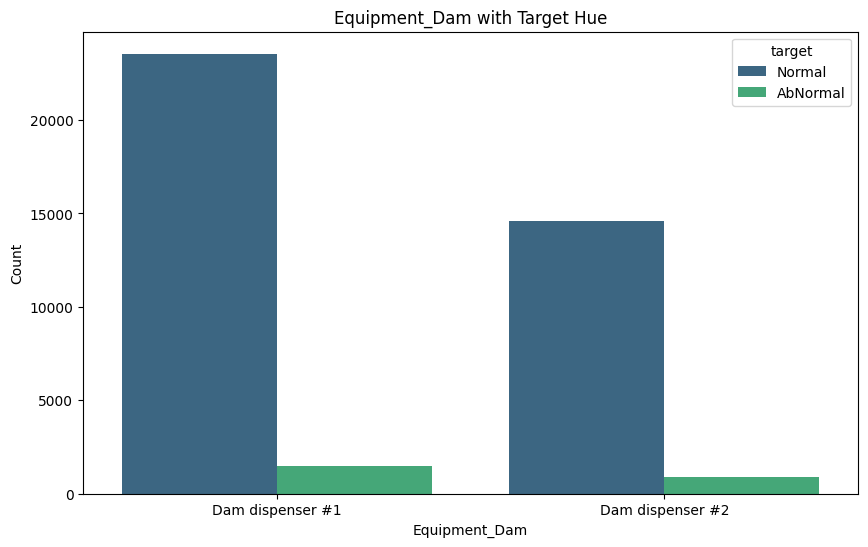

In [123]:
plt.figure(figsize=(10, 6))
sns.countplot(
    data=df_dam_cleaned,
    x='Equipment_Dam',
    hue='target',
    palette='viridis'
)
plt.title('Equipment_Dam with Target Hue')
plt.xlabel('Equipment_Dam')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

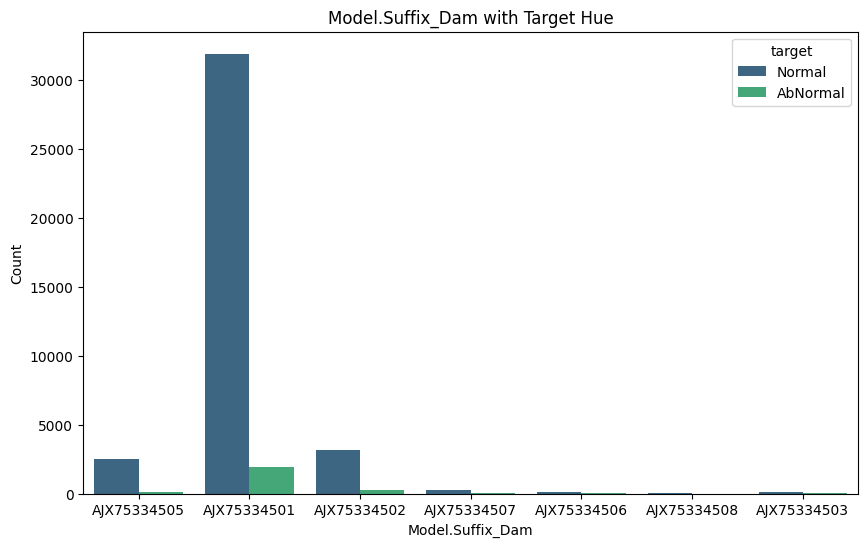

In [124]:
plt.figure(figsize=(10, 6))
sns.countplot(
    data=df_dam_cleaned,
    x='Model.Suffix_Dam',
    hue='target',
    palette='viridis'
)
plt.title('Model.Suffix_Dam with Target Hue')
plt.xlabel('Model.Suffix_Dam')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

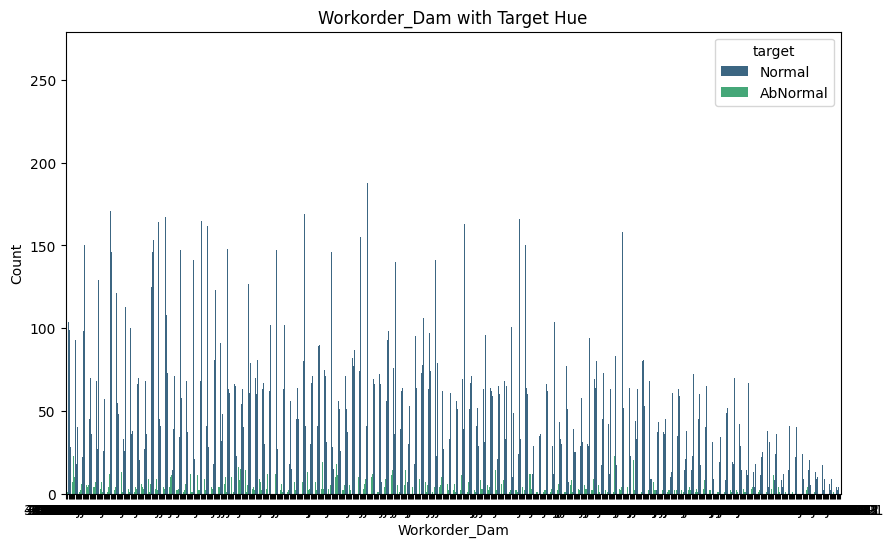

In [125]:
plt.figure(figsize=(10, 6))
sns.countplot(
    data=df_dam_cleaned,
    x='Workorder_Dam',
    hue='target',
    palette='viridis'
)
plt.title('Workorder_Dam with Target Hue')
plt.xlabel('Workorder_Dam')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

In [142]:
workorder_dam_target_distribution = df_dam_cleaned.groupby('Workorder_Dam')['target'].value_counts().unstack().fillna(0)

# 결과 출력
print("Workorder_Dam 값 종류별로 target 데이터의 분포:")

sorted_df = workorder_dam_target_distribution .sort_values(by='AbNormal', ascending=False)
sorted_df['Percentage'] = sorted_df['AbNormal'] / (sorted_df['AbNormal'] + sorted_df['Normal'])

# 'Percentage' 칼럼을 기준으로 내림차순 정렬
sorted_df = sorted_df.sort_values(by='Percentage', ascending=False)
sorted_df

Workorder_Dam 값 종류별로 target 데이터의 분포:


target,AbNormal,Normal,Percentage
Workorder_Dam,,,
3KPXX094-0001,11.0,0.0,1.000000
4CPXX084-0001,8.0,0.0,1.000000
3H1XE354-1,13.0,2.0,0.866667
4E1XA548-2,10.0,5.0,0.666667
4A1XC288-1,1.0,1.0,0.500000
...,...,...,...
3J1XE701-1,0.0,30.0,0.000000
3J1XF276-1,0.0,19.0,0.000000
4E1XB486-2,0.0,17.0,0.000000


## workorder에 따라 모두 Normal 인 데이터가 있으며, 모두 AbNormal 한 데이터 또한 존재하다는 것을 확인할 수 있다

### CURE END POSITION 데이터 분석

Column: CURE END POSITION X Collect Result_Dam <br/>
Unique values: [ 240. 1000.] <br/>
Column: CURE END POSITION Z Collect Result_Dam<br/>
Unique values: [ 2.5 12.5]<br/>
Column: CURE END POSITION Θ Collect Result_Dam<br/>
Unique values: [-90  90]

In [145]:
cure_end_position_df = df_dam_cleaned[['CURE END POSITION X Collect Result_Dam','CURE END POSITION Z Collect Result_Dam','CURE END POSITION Θ Collect Result_Dam','target']]
cure_end_position_df

,CURE END POSITION X Collect Result_Dam,CURE END POSITION Z Collect Result_Dam,CURE END POSITION Θ Collect Result_Dam,target
0,240.0,2.5,-90,Normal
1,240.0,2.5,-90,Normal
2,1000.0,12.5,90,Normal
3,1000.0,12.5,90,Normal
4,240.0,2.5,-90,Normal
...,...,...,...,...
40501,240.0,2.5,-90,Normal
40502,1000.0,12.5,90,Normal
40503,240.0,2.5,-90,Normal
40504,1000.0,12.5,90,Normal


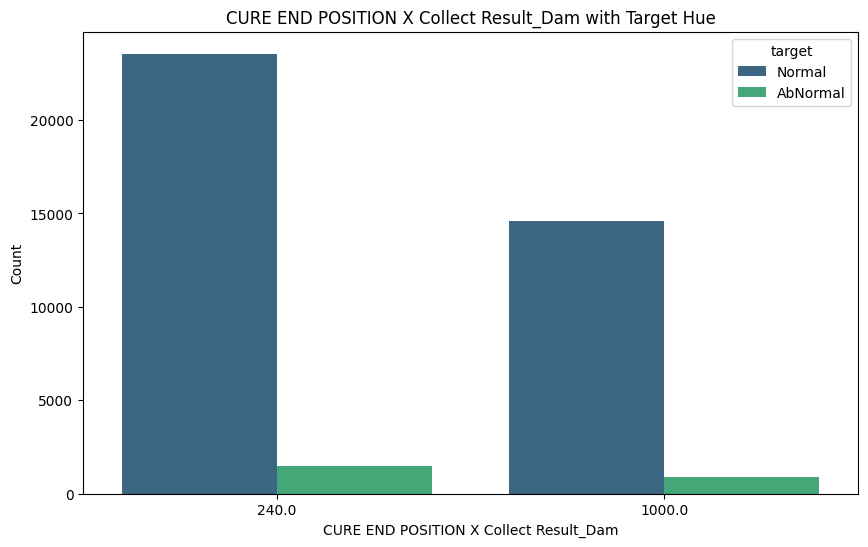

In [147]:
plt.figure(figsize=(10, 6))
sns.countplot(
    data=cure_end_position_df,
    x='CURE END POSITION X Collect Result_Dam',
    hue='target',
    palette='viridis'
)
plt.title('CURE END POSITION X Collect Result_Dam with Target Hue')
plt.xlabel('CURE END POSITION X Collect Result_Dam')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

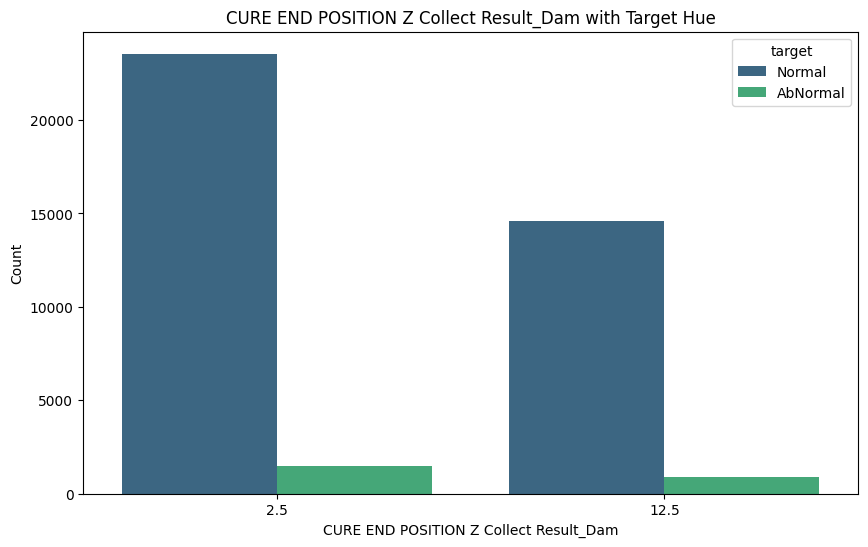

In [148]:
plt.figure(figsize=(10, 6))
sns.countplot(
    data=cure_end_position_df,
    x='CURE END POSITION Z Collect Result_Dam',
    hue='target',
    palette='viridis'
)
plt.title('CURE END POSITION Z Collect Result_Dam with Target Hue')
plt.xlabel('CURE END POSITION Z Collect Result_Dam')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

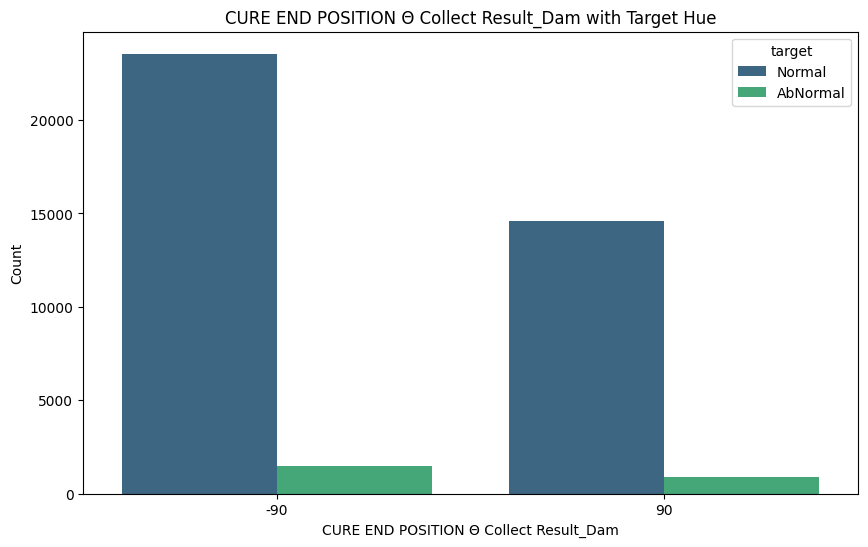

In [149]:
plt.figure(figsize=(10, 6))
sns.countplot(
    data=cure_end_position_df,
    x='CURE END POSITION Θ Collect Result_Dam',
    hue='target',
    palette='viridis'
)
plt.title('CURE END POSITION Θ Collect Result_Dam with Target Hue')
plt.xlabel('CURE END POSITION Θ Collect Result_Dam')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

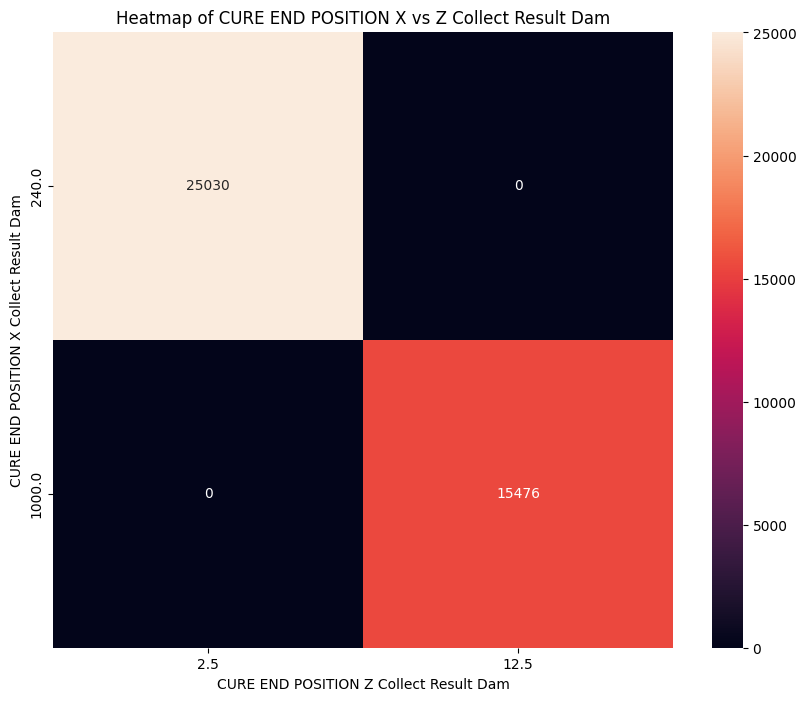

In [153]:
# 히트맵을 위한 피벗 테이블 생성
heatmap_data = cure_end_position_df.pivot_table(
    index='CURE END POSITION X Collect Result_Dam',
    columns='CURE END POSITION Z Collect Result_Dam',
    aggfunc='size',  # 빈도 계산
    fill_value=0
)

# 히트맵 생성
plt.figure(figsize=(10, 8))
sns.heatmap(heatmap_data, annot=True, fmt='d')

# 히트맵 제목 및 레이블 설정
plt.title('Heatmap of CURE END POSITION X vs Z Collect Result Dam')
plt.xlabel('CURE END POSITION Z Collect Result Dam')
plt.ylabel('CURE END POSITION X Collect Result Dam')

# 히트맵 출력
plt.show()

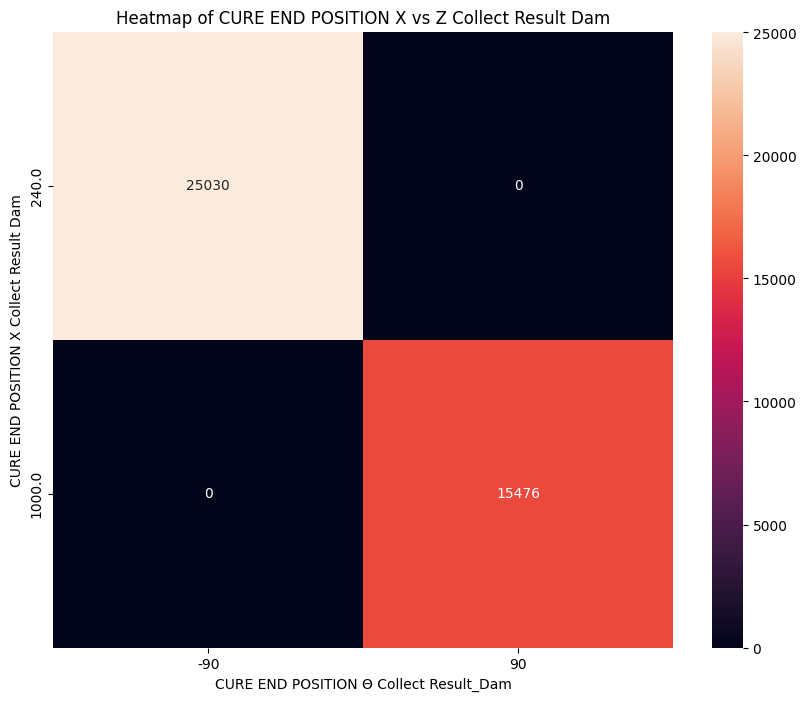

In [156]:
# 히트맵을 위한 피벗 테이블 생성
heatmap_data = cure_end_position_df.pivot_table(
    index='CURE END POSITION X Collect Result_Dam',
    columns='CURE END POSITION Θ Collect Result_Dam',
    aggfunc='size',  # 빈도 계산
    fill_value=0
)

# 히트맵 생성
plt.figure(figsize=(10, 8))
sns.heatmap(heatmap_data, annot=True, fmt='d')

# 히트맵 제목 및 레이블 설정
plt.title('Heatmap of CURE END POSITION X vs Z Collect Result Dam')
plt.xlabel('CURE END POSITION Θ Collect Result_Dam')
plt.ylabel('CURE END POSITION X Collect Result Dam')

# 히트맵 출력
plt.show()

### CURE END POSITION X : 240.0 , CURE END POSITION Z : 2.5 , CURE END POSITION Θ : -90 
### CURE END POSITION X : 1000.0 , CURE END POSITION Z : 12.5 , CURE END POSITION Θ : 90 

### CURE SPEED Collect Result_Dam 데이터 분석

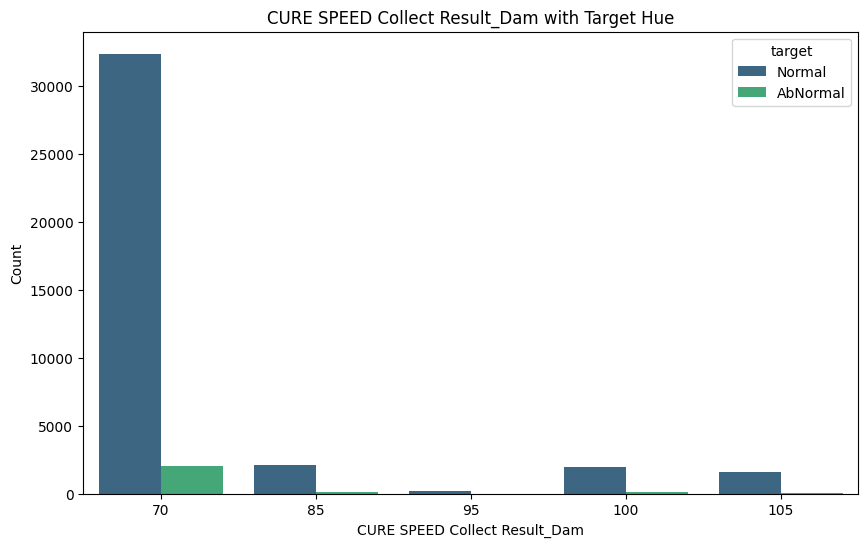

In [157]:
plt.figure(figsize=(10, 6))
sns.countplot(
    data=df_dam_cleaned,
    x='CURE SPEED Collect Result_Dam',
    hue='target',
    palette='viridis'
)
plt.title('CURE SPEED Collect Result_Dam with Target Hue')
plt.xlabel('CURE SPEED Collect Result_Dam')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

In [162]:
CURE_SPEED_Collect_Result_Dam_target_distribution = df_dam_cleaned.groupby('CURE SPEED Collect Result_Dam')['target'].value_counts().unstack().fillna(0)

# 결과 출력
print("CURE SPEED Collect Result_Dam 값 종류별로 target 데이터의 분포:")

sorted_df = CURE_SPEED_Collect_Result_Dam_target_distribution .sort_values(by='AbNormal', ascending=False)
sorted_df['Percentage'] = sorted_df['AbNormal'] / (sorted_df['AbNormal'] + sorted_df['Normal'])

# 'Percentage' 칼럼을 기준으로 내림차순 정렬
sorted_df = sorted_df.sort_values(by='Percentage', ascending=False)
sorted_df

CURE SPEED Collect Result_Dam 값 종류별로 target 데이터의 분포:


target,AbNormal,Normal,Percentage
CURE SPEED Collect Result_Dam,,,
70,2052,32377,0.059601
85,127,2086,0.057388
105,74,1566,0.045122
100,93,1972,0.045036
95,4,155,0.025157


### CURE START POSITION 데이터 분석
'CURE START POSITION X Collect Result_Dam'

'CURE START POSITION Θ Collect Result_Dam'

In [170]:
cure_start_position_df = df_dam_cleaned[['CURE START POSITION X Collect Result_Dam','CURE START POSITION Θ Collect Result_Dam','target']]
cure_start_position_df

,CURE START POSITION X Collect Result_Dam,CURE START POSITION Θ Collect Result_Dam,target
0,1030,-90,Normal
1,1030,-90,Normal
2,280,90,Normal
3,280,90,Normal
4,1030,-90,Normal
...,...,...,...
40501,1030,-90,Normal
40502,280,90,Normal
40503,1030,-90,Normal
40504,280,90,Normal


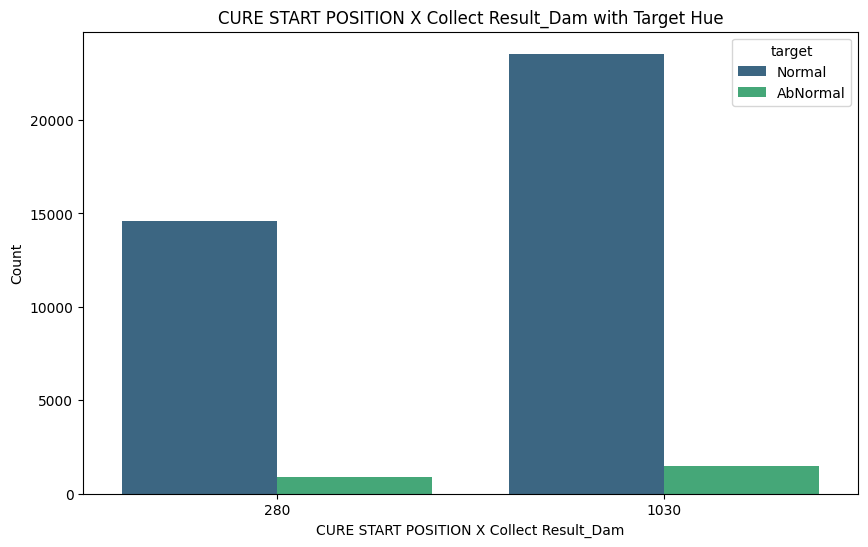

In [171]:
plt.figure(figsize=(10, 6))
sns.countplot(
    data=cure_start_position_df,
    x='CURE START POSITION X Collect Result_Dam',
    hue='target',
    palette='viridis'
)
plt.title('CURE START POSITION X Collect Result_Dam with Target Hue')
plt.xlabel('CURE START POSITION X Collect Result_Dam')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

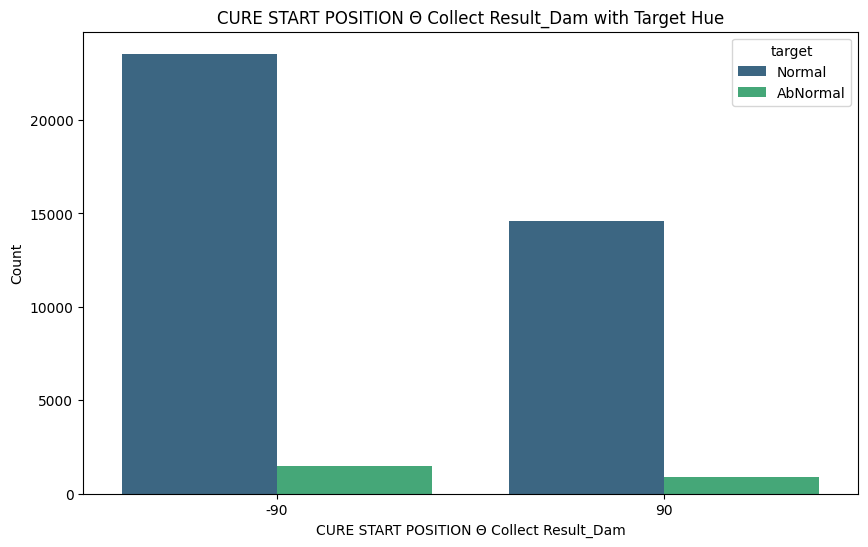

In [172]:
plt.figure(figsize=(10, 6))
sns.countplot(
    data=cure_start_position_df,
    x='CURE START POSITION Θ Collect Result_Dam',
    hue='target',
    palette='viridis'
)
plt.title('CURE START POSITION Θ Collect Result_Dam with Target Hue')
plt.xlabel('CURE START POSITION Θ Collect Result_Dam')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

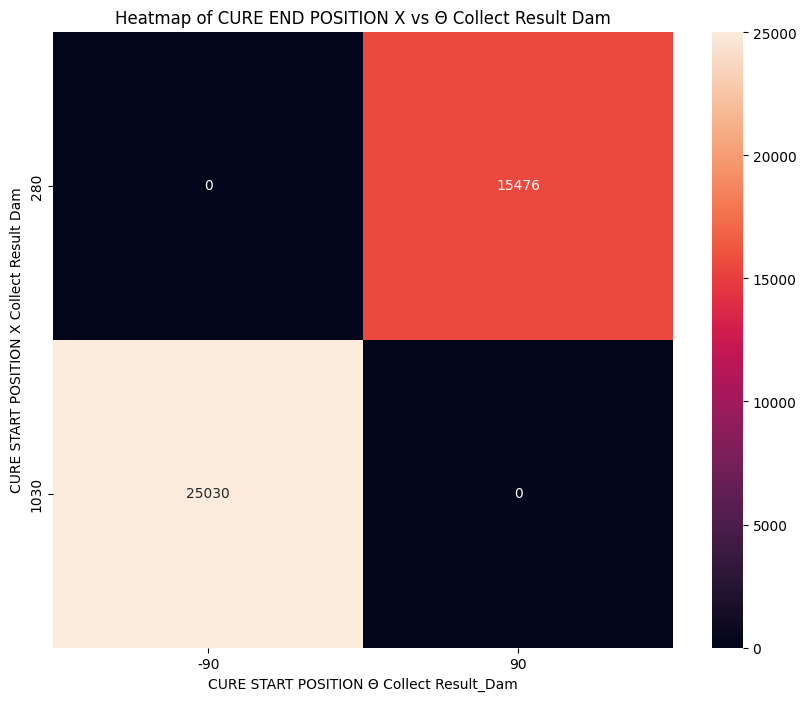

In [174]:
# 히트맵을 위한 피벗 테이블 생성
heatmap_data = cure_start_position_df.pivot_table(
    index='CURE START POSITION X Collect Result_Dam',
    columns='CURE START POSITION Θ Collect Result_Dam',
    aggfunc='size',  # 빈도 계산
    fill_value=0
)

# 히트맵 생성
plt.figure(figsize=(10, 8))
sns.heatmap(heatmap_data, annot=True, fmt='d')

# 히트맵 제목 및 레이블 설정
plt.title('Heatmap of CURE END POSITION X vs Θ Collect Result Dam')
plt.xlabel('CURE START POSITION Θ Collect Result_Dam')
plt.ylabel('CURE START POSITION X Collect Result Dam')

# 히트맵 출력
plt.show()

### DISCHARGED TIME OF RESIN Collect Result_Dam 데이터 분석
방전시간??

DISCHARGED TIME OF RESIN(Stage1) Collect Result_Dam

DISCHARGED TIME OF RESIN(Stage2) Collect Result_Dam

DISCHARGED TIME OF RESIN(Stage3) Collect Result_Dam

In [175]:
discharged_resin_time_df = df_dam_cleaned[['DISCHARGED TIME OF RESIN(Stage1) Collect Result_Dam','DISCHARGED TIME OF RESIN(Stage2) Collect Result_Dam','DISCHARGED TIME OF RESIN(Stage3) Collect Result_Dam','target']]
discharged_resin_time_df

,DISCHARGED TIME OF RESIN(Stage1) Collect Result_Dam,DISCHARGED TIME OF RESIN(Stage2) Collect Result_Dam,DISCHARGED TIME OF RESIN(Stage3) Collect Result_Dam,target
0,14.9,8.4,14.7,Normal
1,21.3,4.9,21.3,Normal
2,14.7,8.5,14.7,Normal
3,21.3,8.4,21.3,Normal
4,9.7,4.9,9.6,Normal
...,...,...,...,...
40501,17.0,5.0,17.0,Normal
40502,14.9,8.5,14.7,Normal
40503,14.2,8.2,14.3,Normal
40504,9.7,4.9,9.7,Normal


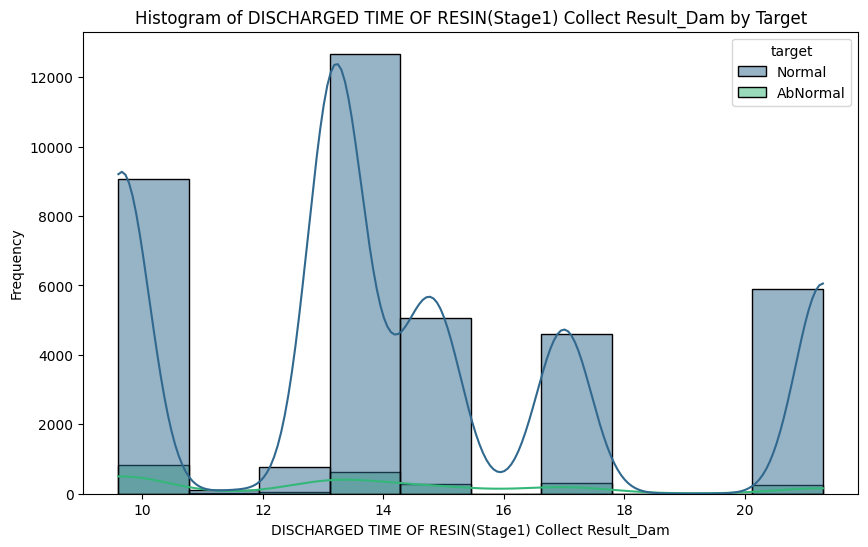

In [177]:
# 히스토그램 시각화
plt.figure(figsize=(10, 6))
sns.histplot(data=discharged_resin_time_df, x='DISCHARGED TIME OF RESIN(Stage1) Collect Result_Dam', hue='target', bins=10, kde=True, palette='viridis')
plt.title('Histogram of DISCHARGED TIME OF RESIN(Stage1) Collect Result_Dam by Target')
plt.xlabel('DISCHARGED TIME OF RESIN(Stage1) Collect Result_Dam')
plt.ylabel('Frequency')
plt.show()

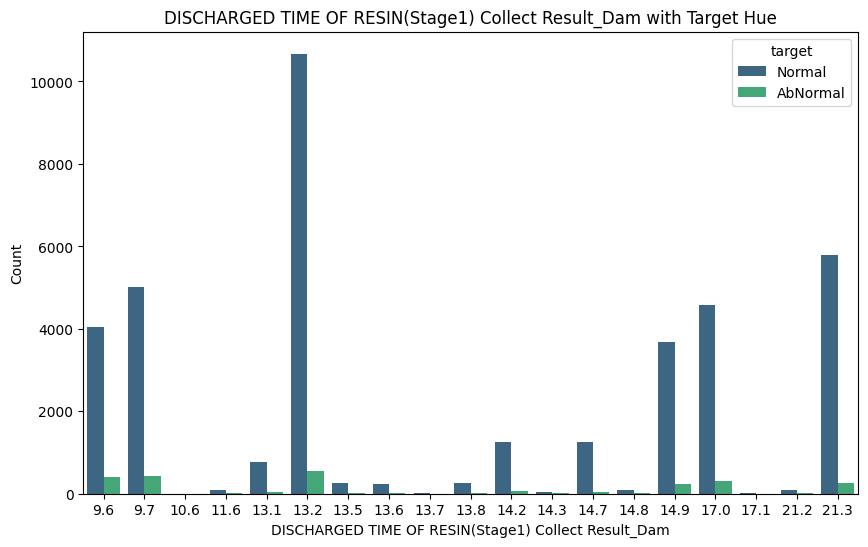

In [178]:
plt.figure(figsize=(10, 6))
sns.countplot(
    data=discharged_resin_time_df,
    x='DISCHARGED TIME OF RESIN(Stage1) Collect Result_Dam',
    hue='target',
    palette='viridis'
)
plt.title('DISCHARGED TIME OF RESIN(Stage1) Collect Result_Dam with Target Hue')
plt.xlabel('DISCHARGED TIME OF RESIN(Stage1) Collect Result_Dam')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

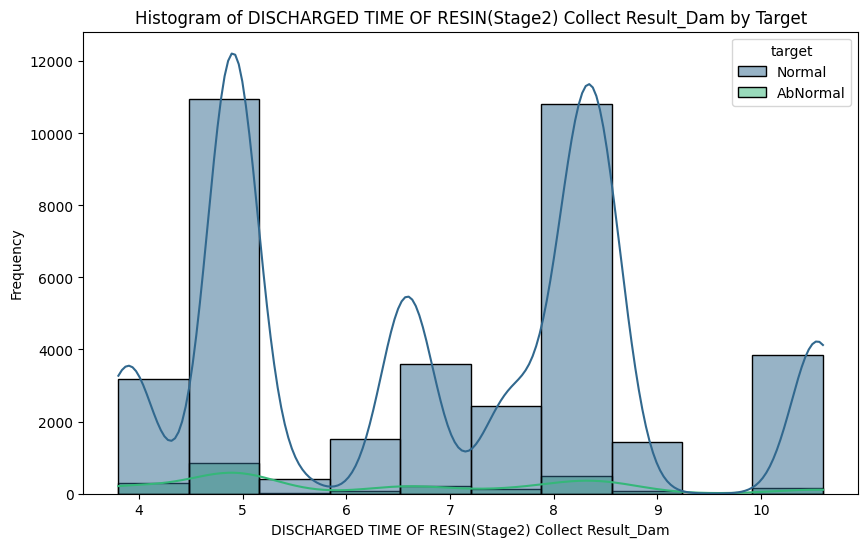

In [179]:
# 히스토그램 시각화
plt.figure(figsize=(10, 6))
sns.histplot(data=discharged_resin_time_df, x='DISCHARGED TIME OF RESIN(Stage2) Collect Result_Dam', hue='target', bins=10, kde=True, palette='viridis')
plt.title('Histogram of DISCHARGED TIME OF RESIN(Stage2) Collect Result_Dam by Target')
plt.xlabel('DISCHARGED TIME OF RESIN(Stage2) Collect Result_Dam')
plt.ylabel('Frequency')
plt.show()

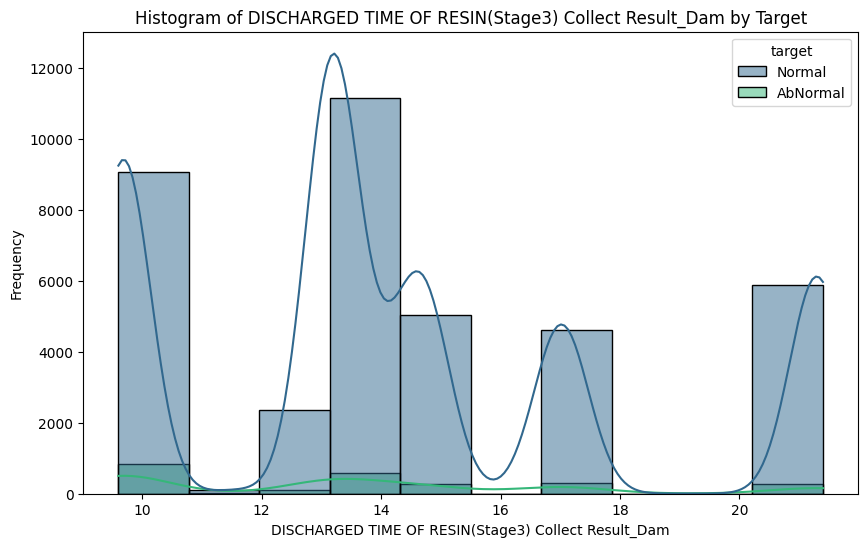

In [180]:
# 히스토그램 시각화
plt.figure(figsize=(10, 6))
sns.histplot(data=discharged_resin_time_df, x='DISCHARGED TIME OF RESIN(Stage3) Collect Result_Dam', hue='target', bins=10, kde=True, palette='viridis')
plt.title('Histogram of DISCHARGED TIME OF RESIN(Stage3) Collect Result_Dam by Target')
plt.xlabel('DISCHARGED TIME OF RESIN(Stage3) Collect Result_Dam')
plt.ylabel('Frequency')
plt.show()

### Dispense Volume collect Result_Dam 데이터 분석
분배량

Dispense Volume(Stage1) Collect Result_Dam

Dispense Volume(Stage2) Collect Result_Dam

Dispense Volume(Stage3) Collect Result_Dam

In [183]:
dispense_Volume_df= df_dam_cleaned[['Dispense Volume(Stage1) Collect Result_Dam','Dispense Volume(Stage2) Collect Result_Dam','Dispense Volume(Stage3) Collect Result_Dam','target']]
dispense_Volume_df

,Dispense Volume(Stage1) Collect Result_Dam,Dispense Volume(Stage2) Collect Result_Dam,Dispense Volume(Stage3) Collect Result_Dam,target
0,1.04,0.58,1.02,Normal
1,1.49,0.34,1.49,Normal
2,1.61,0.93,1.61,Normal
3,1.49,0.58,1.49,Normal
4,0.67,0.34,0.67,Normal
...,...,...,...,...
40501,1.19,0.35,1.19,Normal
40502,1.04,0.59,1.02,Normal
40503,0.99,0.57,1.00,Normal
40504,0.67,0.34,0.67,Normal


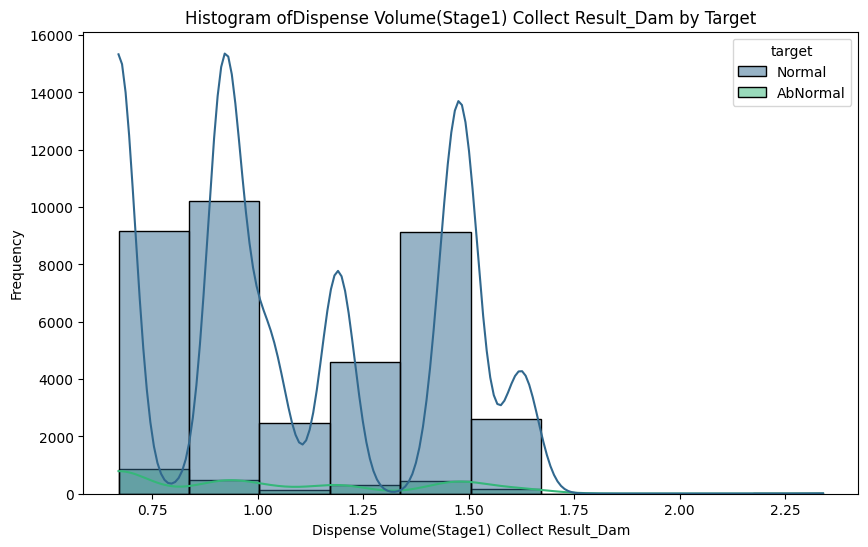

In [184]:
# 히스토그램 시각화
plt.figure(figsize=(10, 6))
sns.histplot(data=dispense_Volume_df, x='Dispense Volume(Stage1) Collect Result_Dam', hue='target', bins=10, kde=True, palette='viridis')
plt.title('Histogram ofDispense Volume(Stage1) Collect Result_Dam by Target')
plt.xlabel('Dispense Volume(Stage1) Collect Result_Dam')
plt.ylabel('Frequency')
plt.show()

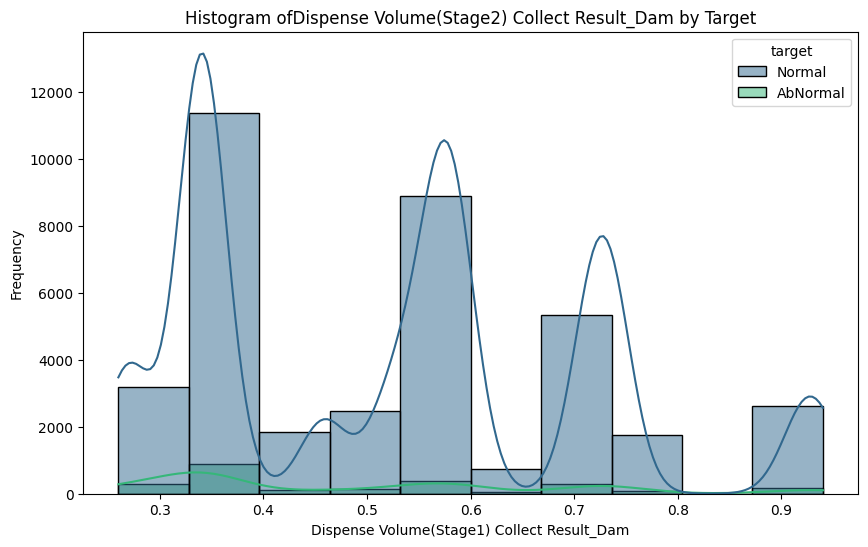

In [185]:
# 히스토그램 시각화
plt.figure(figsize=(10, 6))
sns.histplot(data=dispense_Volume_df, x='Dispense Volume(Stage2) Collect Result_Dam', hue='target', bins=10, kde=True, palette='viridis')
plt.title('Histogram ofDispense Volume(Stage2) Collect Result_Dam by Target')
plt.xlabel('Dispense Volume(Stage1) Collect Result_Dam')
plt.ylabel('Frequency')
plt.show()

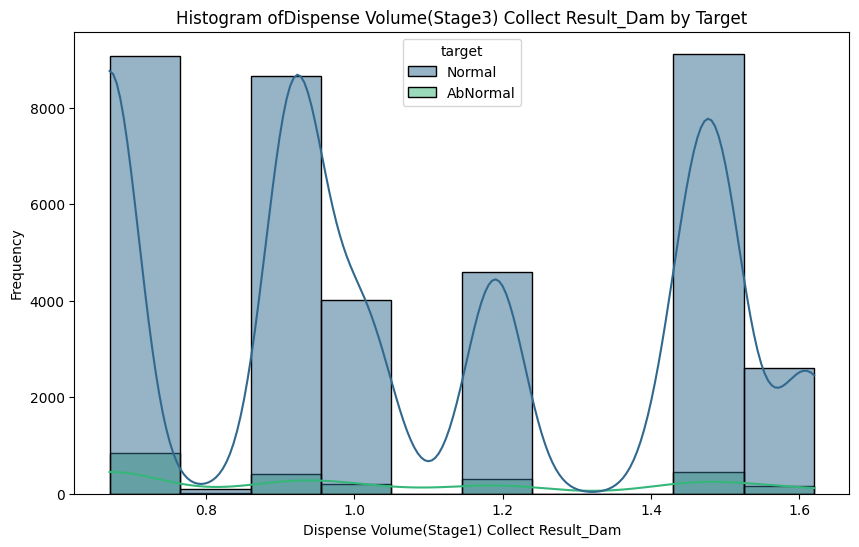

In [186]:
# 히스토그램 시각화
plt.figure(figsize=(10, 6))
sns.histplot(data=dispense_Volume_df, x='Dispense Volume(Stage3) Collect Result_Dam', hue='target', bins=10, kde=True, palette='viridis')
plt.title('Histogram ofDispense Volume(Stage3) Collect Result_Dam by Target')
plt.xlabel('Dispense Volume(Stage1) Collect Result_Dam')
plt.ylabel('Frequency')
plt.show()

### HEAD NORMAL COORDINATE  AXIS Collect Result_Dam 분석
헤드 법선 좌표

HEAD NORMAL COORDINATE X AXIS(Stage1) Collect Result_Dam

HEAD NORMAL COORDINATE X AXIS(Stage2) Collect Result_Dam

HEAD NORMAL COORDINATE X AXIS(Stage3) Collect Result_Dam

HEAD NORMAL COORDINATE Y AXIS(Stage1) Collect Result_Dam

HEAD NORMAL COORDINATE Y AXIS(Stage2) Collect Result_Dam

HEAD NORMAL COORDINATE Y AXIS(Stage3) Collect Result_Dam

HEAD NORMAL COORDINATE Z AXIS(Stage1) Collect Result_Dam

HEAD NORMAL COORDINATE Z AXIS(Stage2) Collect Result_Dam

HEAD NORMAL COORDINATE Z AXIS(Stage3) Collect Result_Dam

In [27]:
# 데이터프레임에서 지정된 칼럼 선택
head_coordinate_axis_df = df_dam_cleaned[
    [
        'HEAD NORMAL COORDINATE X AXIS(Stage1) Collect Result_Dam',
        'HEAD NORMAL COORDINATE X AXIS(Stage2) Collect Result_Dam',
        'HEAD NORMAL COORDINATE X AXIS(Stage3) Collect Result_Dam',
        'HEAD NORMAL COORDINATE Y AXIS(Stage1) Collect Result_Dam',
        'HEAD NORMAL COORDINATE Y AXIS(Stage2) Collect Result_Dam',
        'HEAD NORMAL COORDINATE Y AXIS(Stage3) Collect Result_Dam',
        'HEAD NORMAL COORDINATE Z AXIS(Stage1) Collect Result_Dam',
        'HEAD NORMAL COORDINATE Z AXIS(Stage2) Collect Result_Dam',
        'HEAD NORMAL COORDINATE Z AXIS(Stage3) Collect Result_Dam',
        'target'
    ]
]

# 선택된 데이터프레임 출력
head_coordinate_axis_df

,HEAD NORMAL COORDINATE X AXIS(Stage1) Collect Result_Dam,HEAD NORMAL COORDINATE X AXIS(Stage2) Collect Result_Dam,HEAD NORMAL COORDINATE X AXIS(Stage3) Collect Result_Dam,HEAD NORMAL COORDINATE Y AXIS(Stage1) Collect Result_Dam,HEAD NORMAL COORDINATE Y AXIS(Stage2) Collect Result_Dam,HEAD NORMAL COORDINATE Y AXIS(Stage3) Collect Result_Dam,HEAD NORMAL COORDINATE Z AXIS(Stage1) Collect Result_Dam,HEAD NORMAL COORDINATE Z AXIS(Stage2) Collect Result_Dam,HEAD NORMAL COORDINATE Z AXIS(Stage3) Collect Result_Dam,target
0,NaN,550.5,464.3,161.4,384.0,383.1,384.00,274.51,274.51,Normal
1,550.3,463.8,160.8,377.3,377.3,377.3,282.15,282.15,282.15,Normal
2,OK,162.4,465.4,551.7,1271.8,1383.9,1271.80,274.33,274.33,Normal
3,162.4,465.5,552.0,1271.8,1270.7,1271.8,282.15,282.15,282.15,Normal
4,549,462.5,159.5,377.5,377.0,377.5,284.80,284.80,284.80,Normal
...,...,...,...,...,...,...,...,...,...,...
40501,550.3,463.8,160.8,377.3,377.3,377.3,282.15,282.15,282.15,Normal
40502,NaN,163.5,466.2,553.1,1281.0,1393.5,1281.20,274.33,274.33,Normal
40503,OK,550.6,463.9,161.5,377.6,377.1,378.00,274.78,274.78,Normal
40504,162.4,465.1,551.3,1269.0,1268.4,1269.0,282.15,282.15,282.15,Normal


In [28]:
# 'HEAD NORMAL COORDINATE X AXIS(Stage1) Collect Result_Dam' 칼럼의 NaN 데이터 개수 계산
nan_count = head_coordinate_axis_df['HEAD NORMAL COORDINATE X AXIS(Stage1) Collect Result_Dam'].isna().sum()

# 결과 출력
print(f"'HEAD NORMAL COORDINATE X AXIS(Stage1) Collect Result_Dam' 칼럼의 NaN 데이터 개수: {nan_count}")

'HEAD NORMAL COORDINATE X AXIS(Stage1) Collect Result_Dam' 칼럼의 NaN 데이터 개수: 12766


In [29]:
head_coordinate_axis_stage1_x = head_coordinate_axis_df[[
    'HEAD NORMAL COORDINATE X AXIS(Stage1) Collect Result_Dam',
    'target']
]
head_coordinate_axis_stage1_x =  head_coordinate_axis_stage1_x.dropna(subset=['HEAD NORMAL COORDINATE X AXIS(Stage1) Collect Result_Dam'])
head_coordinate_axis_stage1_x

,HEAD NORMAL COORDINATE X AXIS(Stage1) Collect Result_Dam,target
1,550.3,Normal
2,OK,Normal
3,162.4,Normal
4,549,Normal
5,549,Normal
...,...,...
40499,OK,Normal
40501,550.3,Normal
40503,OK,Normal
40504,162.4,Normal


In [31]:
head_coordinate_axis_stage1_x = head_coordinate_axis_stage1_x[head_coordinate_axis_stage1_x['HEAD NORMAL COORDINATE X AXIS(Stage1) Collect Result_Dam'] != 'OK']
head_coordinate_axis_stage1_x

,HEAD NORMAL COORDINATE X AXIS(Stage1) Collect Result_Dam,target
1,550.3,Normal
3,162.4,Normal
4,549,Normal
5,549,Normal
8,549,Normal
...,...,...
40497,549,Normal
40498,549,Normal
40501,550.3,Normal
40504,162.4,Normal


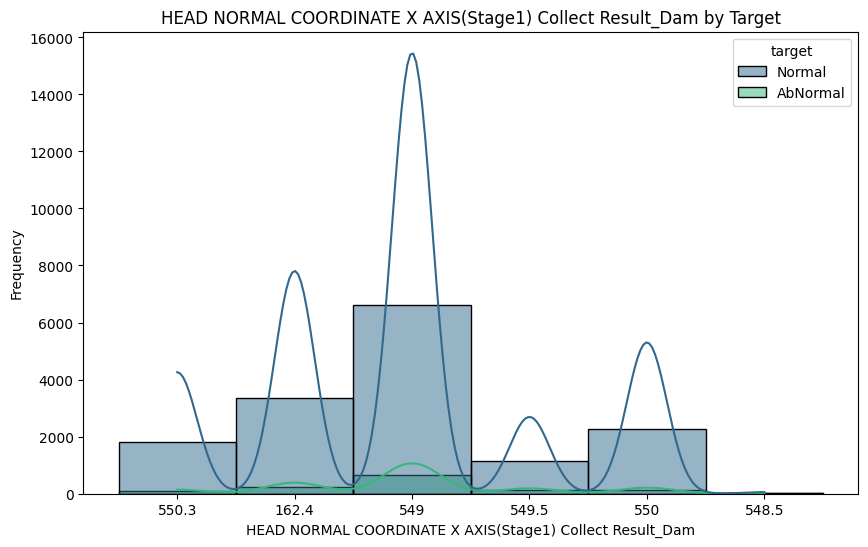

In [32]:
# 히스토그램 시각화
plt.figure(figsize=(10, 6))
sns.histplot(head_coordinate_axis_stage1_x, x='HEAD NORMAL COORDINATE X AXIS(Stage1) Collect Result_Dam', hue='target', bins=10, kde=True, palette='viridis')
plt.title('HEAD NORMAL COORDINATE X AXIS(Stage1) Collect Result_Dam by Target')
plt.xlabel('HEAD NORMAL COORDINATE X AXIS(Stage1) Collect Result_Dam')
plt.ylabel('Frequency')
plt.show()

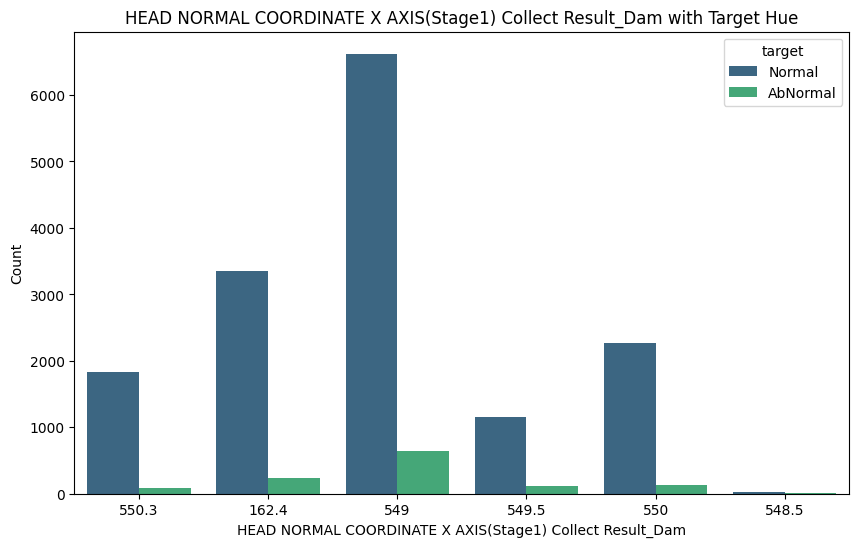

In [33]:
plt.figure(figsize=(10, 6))
sns.countplot(
    data=head_coordinate_axis_stage1_x,
    x='HEAD NORMAL COORDINATE X AXIS(Stage1) Collect Result_Dam',
    hue='target',
    palette='viridis'
)
plt.title('HEAD NORMAL COORDINATE X AXIS(Stage1) Collect Result_Dam with Target Hue')
plt.xlabel('HEAD NORMAL COORDINATE X AXIS(Stage1) Collect Result_Dam')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

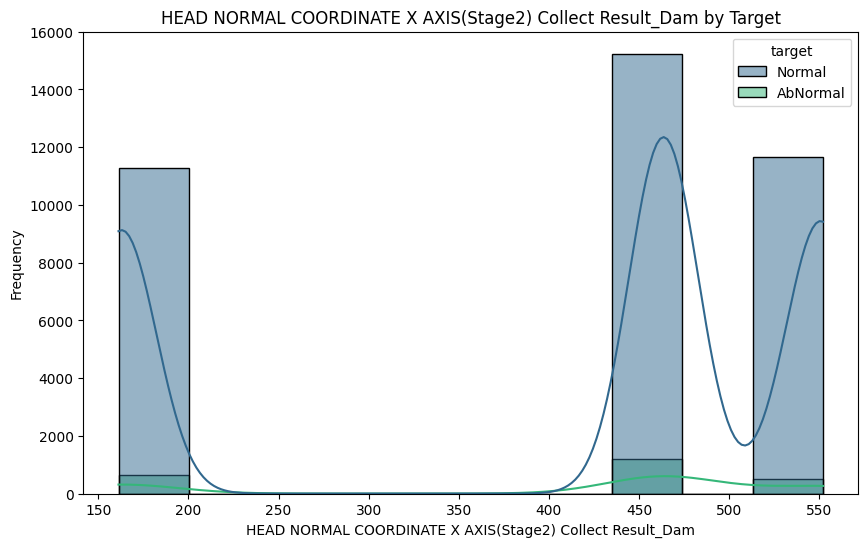

In [34]:
# 히스토그램 시각화
plt.figure(figsize=(10, 6))
sns.histplot(data=head_coordinate_axis_df, x='HEAD NORMAL COORDINATE X AXIS(Stage2) Collect Result_Dam', hue='target', bins=10, kde=True, palette='viridis')
plt.title('HEAD NORMAL COORDINATE X AXIS(Stage2) Collect Result_Dam by Target')
plt.xlabel('HEAD NORMAL COORDINATE X AXIS(Stage2) Collect Result_Dam')
plt.ylabel('Frequency')
plt.show()

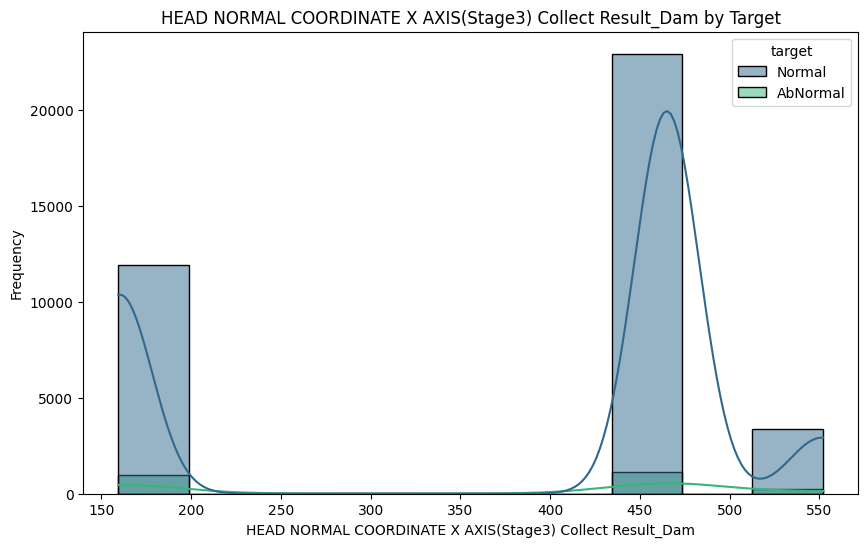

In [32]:
# 히스토그램 시각화
plt.figure(figsize=(10, 6))
sns.histplot(data=head_coordinate_axis_df, x='HEAD NORMAL COORDINATE X AXIS(Stage3) Collect Result_Dam', hue='target', bins=10, kde=True, palette='viridis')
plt.title('HEAD NORMAL COORDINATE X AXIS(Stage3) Collect Result_Dam by Target')
plt.xlabel('HEAD NORMAL COORDINATE X AXIS(Stage3) Collect Result_Dam')
plt.ylabel('Frequency')
plt.show()

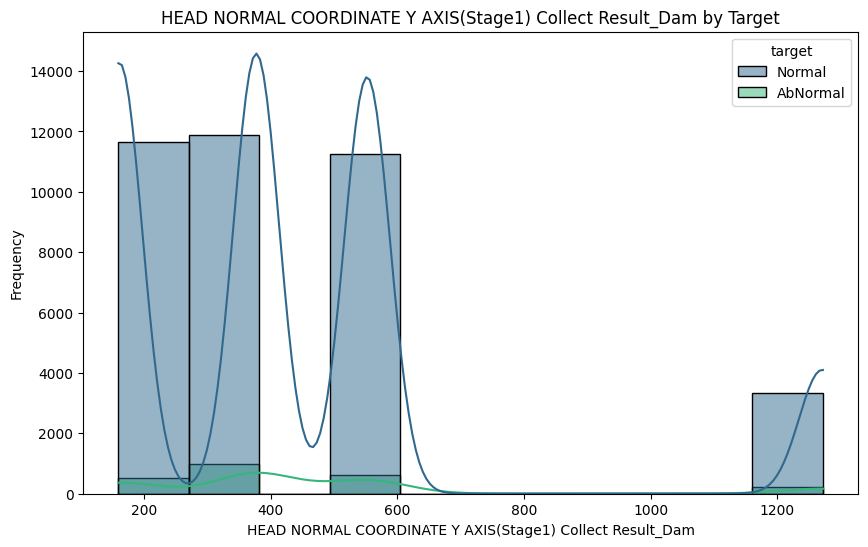

In [33]:
# 히스토그램 시각화
plt.figure(figsize=(10, 6))
sns.histplot(data=head_coordinate_axis_df, x='HEAD NORMAL COORDINATE Y AXIS(Stage1) Collect Result_Dam', hue='target', bins=10, kde=True, palette='viridis')
plt.title('HEAD NORMAL COORDINATE Y AXIS(Stage1) Collect Result_Dam by Target')
plt.xlabel('HEAD NORMAL COORDINATE Y AXIS(Stage1) Collect Result_Dam')
plt.ylabel('Frequency')
plt.show()

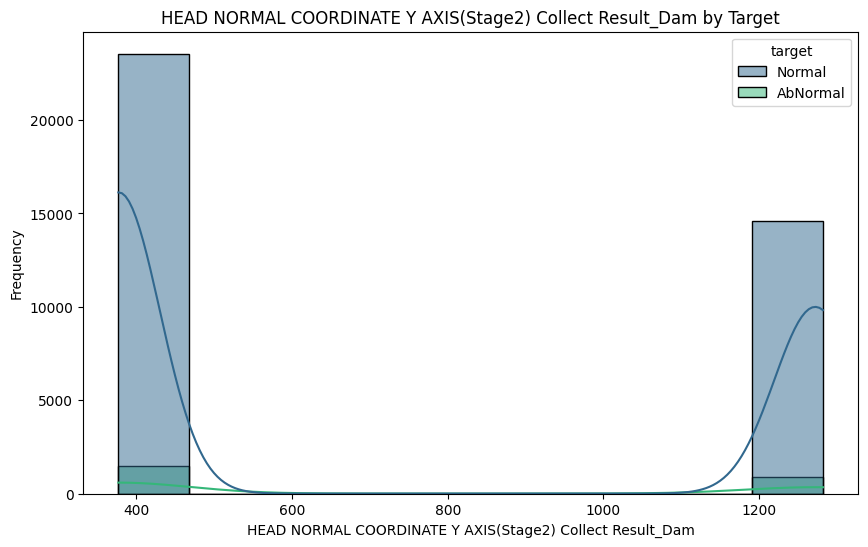

In [34]:
# 히스토그램 시각화
plt.figure(figsize=(10, 6))
sns.histplot(data=head_coordinate_axis_df, x='HEAD NORMAL COORDINATE Y AXIS(Stage2) Collect Result_Dam', hue='target', bins=10, kde=True, palette='viridis')
plt.title('HEAD NORMAL COORDINATE Y AXIS(Stage2) Collect Result_Dam by Target')
plt.xlabel('HEAD NORMAL COORDINATE Y AXIS(Stage2) Collect Result_Dam')
plt.ylabel('Frequency')
plt.show()

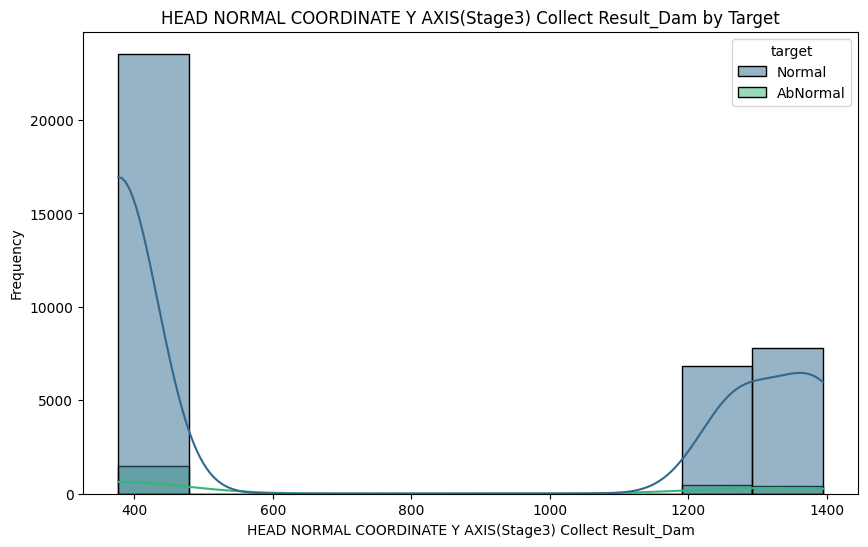

In [35]:
# 히스토그램 시각화
plt.figure(figsize=(10, 6))
sns.histplot(data=head_coordinate_axis_df, x='HEAD NORMAL COORDINATE Y AXIS(Stage3) Collect Result_Dam', hue='target', bins=10, kde=True, palette='viridis')
plt.title('HEAD NORMAL COORDINATE Y AXIS(Stage3) Collect Result_Dam by Target')
plt.xlabel('HEAD NORMAL COORDINATE Y AXIS(Stage3) Collect Result_Dam')
plt.ylabel('Frequency')
plt.show()

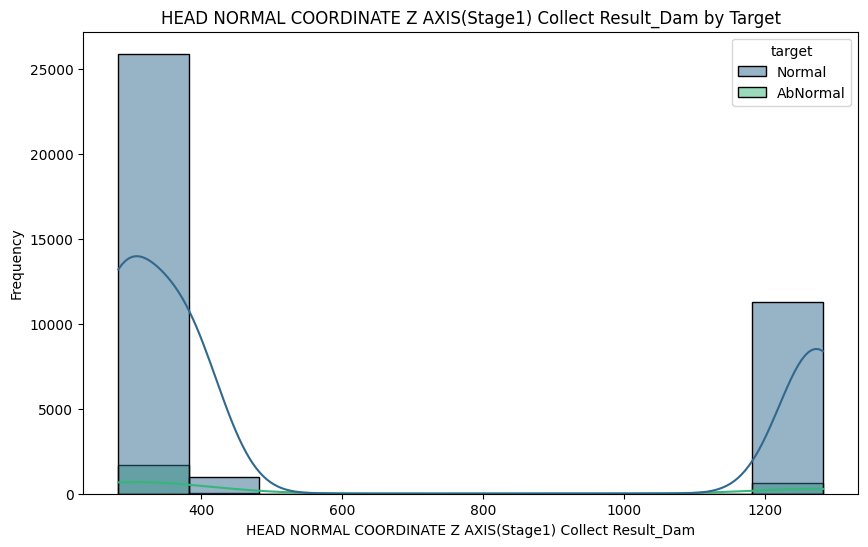

In [37]:
# 히스토그램 시각화
plt.figure(figsize=(10, 6))
sns.histplot(data=head_coordinate_axis_df, x='HEAD NORMAL COORDINATE Z AXIS(Stage1) Collect Result_Dam', hue='target', bins=10, kde=True, palette='viridis')
plt.title('HEAD NORMAL COORDINATE Z AXIS(Stage1) Collect Result_Dam by Target')
plt.xlabel('HEAD NORMAL COORDINATE Z AXIS(Stage1) Collect Result_Dam')
plt.ylabel('Frequency')
plt.show()

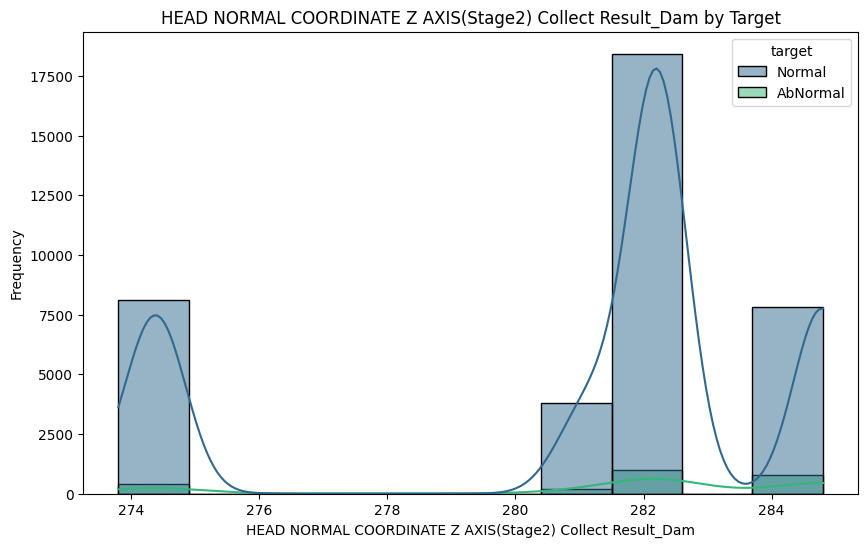

In [38]:
# 히스토그램 시각화
plt.figure(figsize=(10, 6))
sns.histplot(data=head_coordinate_axis_df, x='HEAD NORMAL COORDINATE Z AXIS(Stage2) Collect Result_Dam', hue='target', bins=10, kde=True, palette='viridis')
plt.title('HEAD NORMAL COORDINATE Z AXIS(Stage2) Collect Result_Dam by Target')
plt.xlabel('HEAD NORMAL COORDINATE Z AXIS(Stage2) Collect Result_Dam')
plt.ylabel('Frequency')
plt.show()

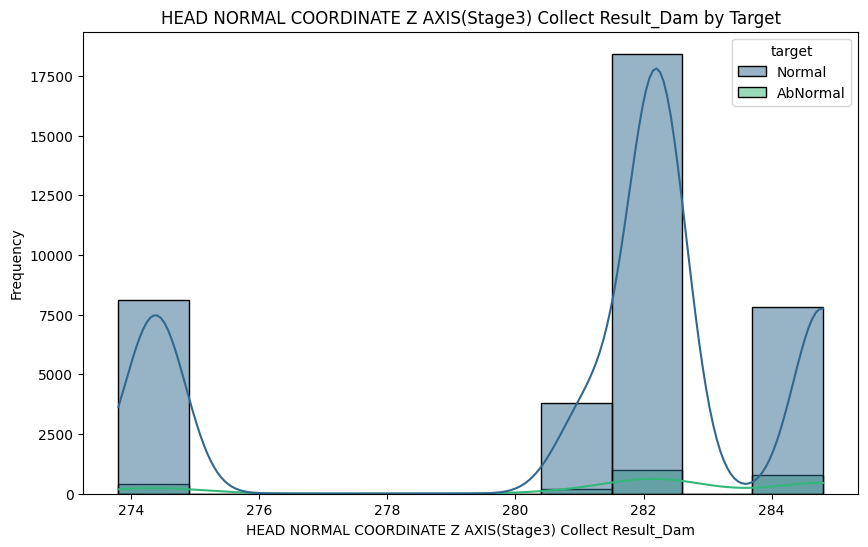

In [39]:
# 히스토그램 시각화
plt.figure(figsize=(10, 6))
sns.histplot(data=head_coordinate_axis_df, x='HEAD NORMAL COORDINATE Z AXIS(Stage3) Collect Result_Dam', hue='target', bins=10, kde=True, palette='viridis')
plt.title('HEAD NORMAL COORDINATE Z AXIS(Stage3) Collect Result_Dam by Target')
plt.xlabel('HEAD NORMAL COORDINATE Z AXIS(Stage3) Collect Result_Dam')
plt.ylabel('Frequency')
plt.show()

### HEAD Position Collect Result_DAM
HEAD Standby Position X Collect Result_Dam

HEAD Standby Position Y Collect Result_Dam

HEAD Standby Position Z Collect Result_Dam

Head Clean Position X Collect Result_Dam

Head Clean Position Y Collect Result_Dam

Head Clean Position Z Collect Result_Dam

Head Purge Position X Collect Result_Dam

Head Purge Position Y Collect Result_Dam

Head Purge Position Z Collect Result_Dam

Head Zero Position X Collect Result_Dam

Head Zero Position Y Collect Result_Dam

Head Zero Position Z Collect Result_Dam

In [24]:
# 데이터프레임에서 지정된 칼럼 선택
head_position_df = df_dam_cleaned[
    [
        'HEAD Standby Position X Collect Result_Dam',
        'HEAD Standby Position Y Collect Result_Dam',
        'HEAD Standby Position Z Collect Result_Dam',
        'Head Clean Position X Collect Result_Dam',
        'Head Clean Position Y Collect Result_Dam',
        'Head Clean Position Z Collect Result_Dam',
        'Head Purge Position X Collect Result_Dam',
        'Head Purge Position Y Collect Result_Dam',
        'Head Purge Position Z Collect Result_Dam',
        'Head Zero Position X Collect Result_Dam',
        'Head Zero Position Y Collect Result_Dam',
        'Head Zero Position Z Collect Result_Dam',
        'target'
    ]
]

# 선택된 데이터프레임 출력
head_position_df

,HEAD Standby Position X Collect Result_Dam,HEAD Standby Position Y Collect Result_Dam,HEAD Standby Position Z Collect Result_Dam,Head Clean Position X Collect Result_Dam,Head Clean Position Y Collect Result_Dam,Head Clean Position Z Collect Result_Dam,Head Purge Position X Collect Result_Dam,Head Purge Position Y Collect Result_Dam,Head Purge Position Z Collect Result_Dam,Head Zero Position X Collect Result_Dam,Head Zero Position Y Collect Result_Dam,Head Zero Position Z Collect Result_Dam,target
0,274.51,257,66,0.0,127.5,66.00,124.0,257,66.00,130.85,505.0,300.0,Normal
1,257.00,66,0,127.5,66.0,130.85,257.0,66,130.85,505.00,300.0,265.0,Normal
2,274.33,257,66,0.0,127.5,66.00,124.0,257,66.00,130.85,505.0,300.0,Normal
3,257.00,66,0,127.5,66.0,130.85,257.0,66,130.85,505.00,300.0,265.0,Normal
4,257.00,66,0,127.5,66.0,133.50,257.0,66,133.50,505.00,300.0,265.0,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...
40501,257.00,66,0,127.5,66.0,130.85,257.0,66,130.85,505.00,300.0,265.0,Normal
40502,274.33,257,66,0.0,127.5,66.00,124.0,257,66.00,130.85,505.0,300.0,Normal
40503,274.78,257,66,0.0,127.5,66.00,124.0,257,66.00,130.85,505.0,300.0,Normal
40504,257.00,66,0,127.5,66.0,130.85,257.0,66,130.85,505.00,300.0,265.0,Normal


#### HEAD Standy Posiion

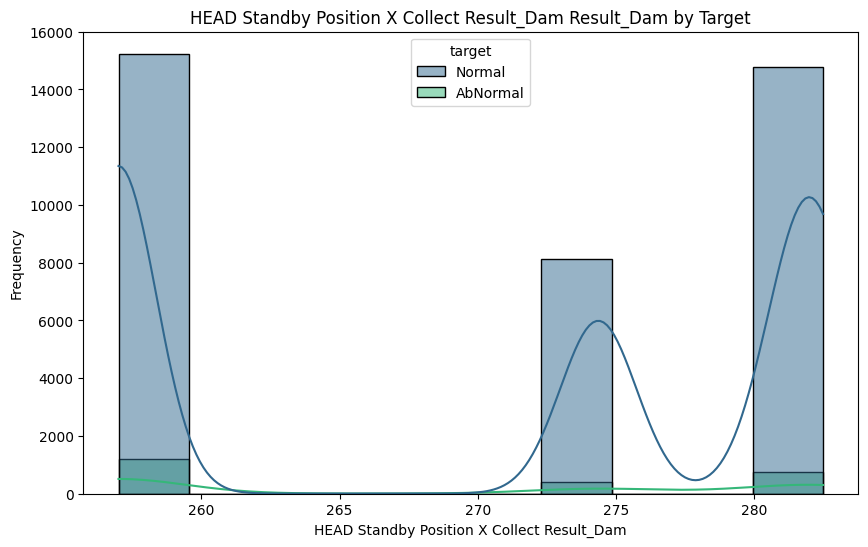

In [47]:
# 히스토그램 시각화
plt.figure(figsize=(10, 6))
sns.histplot(data=head_position_df, x='HEAD Standby Position X Collect Result_Dam', hue='target', bins=10, kde=True, palette='viridis')
plt.title('HEAD Standby Position X Collect Result_Dam Result_Dam by Target')
plt.xlabel('HEAD Standby Position X Collect Result_Dam')
plt.ylabel('Frequency')
plt.show()

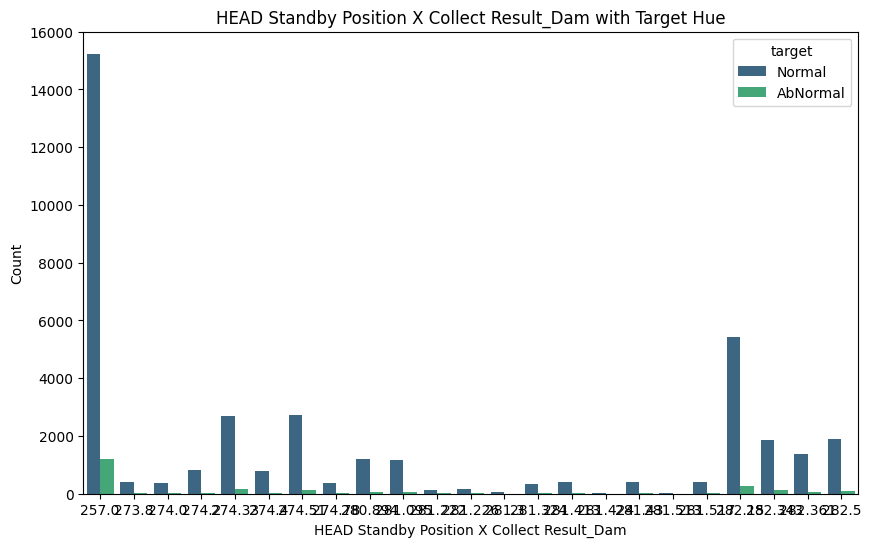

In [39]:
plt.figure(figsize=(10, 6))
sns.countplot(
    data=head_position_df,
    x='HEAD Standby Position X Collect Result_Dam',
    hue='target',
    palette='viridis'
)
plt.title('HEAD Standby Position X Collect Result_Dam with Target Hue')
plt.xlabel('HEAD Standby Position X Collect Result_Dam')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

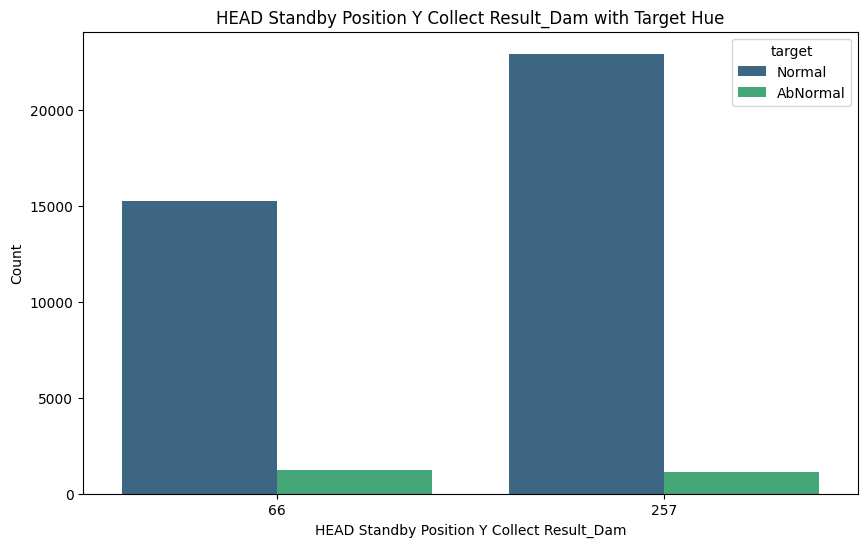

In [40]:
plt.figure(figsize=(10, 6))
sns.countplot(
    data=head_position_df,
    x='HEAD Standby Position Y Collect Result_Dam',
    hue='target',
    palette='viridis'
)
plt.title('HEAD Standby Position Y Collect Result_Dam with Target Hue')
plt.xlabel('HEAD Standby Position Y Collect Result_Dam')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

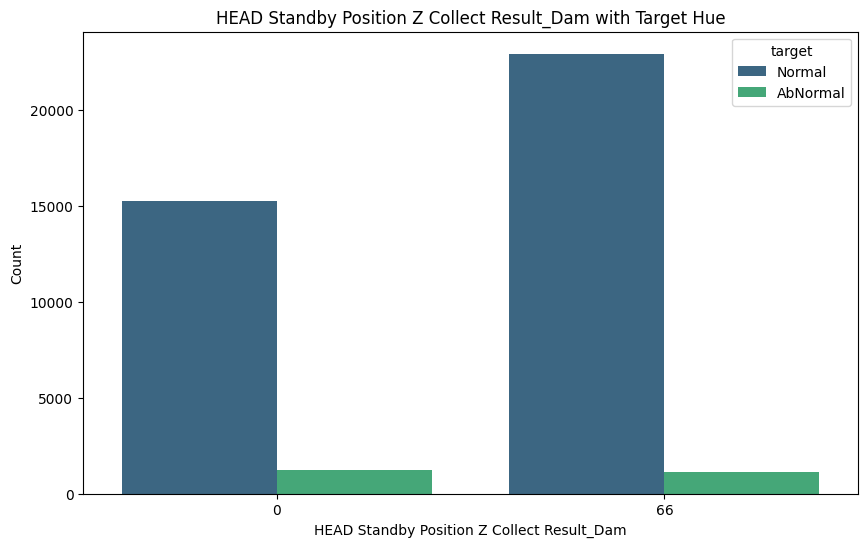

In [41]:
plt.figure(figsize=(10, 6))
sns.countplot(
    data=head_position_df,
    x='HEAD Standby Position Z Collect Result_Dam',
    hue='target',
    palette='viridis'
)
plt.title('HEAD Standby Position Z Collect Result_Dam with Target Hue')
plt.xlabel('HEAD Standby Position Z Collect Result_Dam')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

#### Head Clean Position

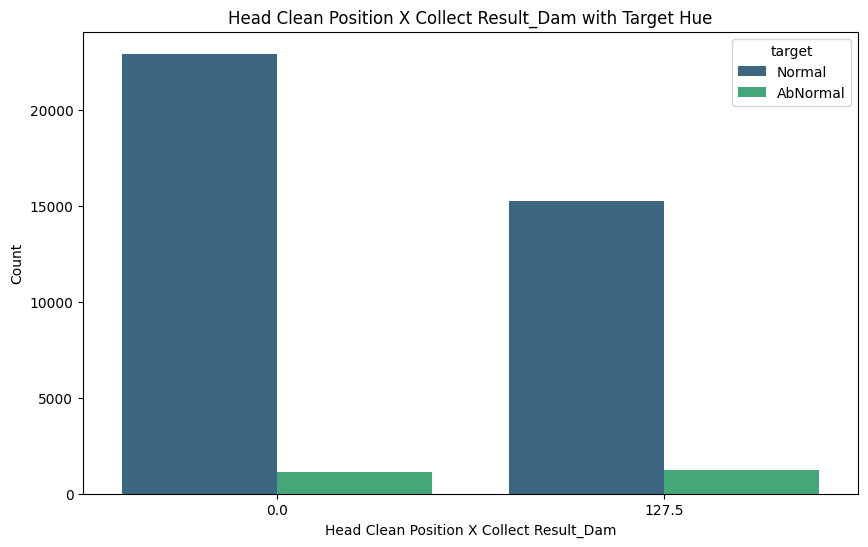

In [43]:

plt.figure(figsize=(10, 6))
sns.countplot(
    data=head_position_df,
    x='Head Clean Position X Collect Result_Dam',
    hue='target',
    palette='viridis'
)
plt.title('Head Clean Position X Collect Result_Dam with Target Hue')
plt.xlabel('Head Clean Position X Collect Result_Dam')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

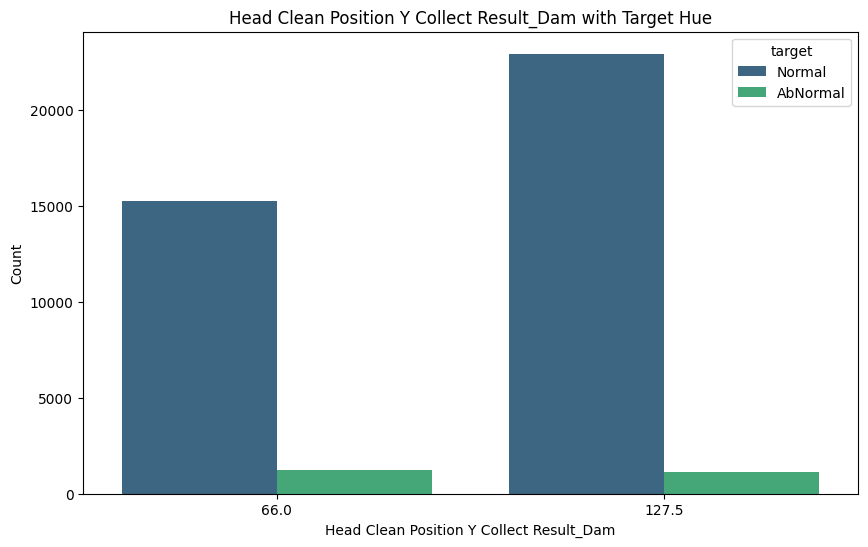

In [44]:

plt.figure(figsize=(10, 6))
sns.countplot(
    data=head_position_df,
    x='Head Clean Position Y Collect Result_Dam',
    hue='target',
    palette='viridis'
)
plt.title('Head Clean Position Y Collect Result_Dam with Target Hue')
plt.xlabel('Head Clean Position Y Collect Result_Dam')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

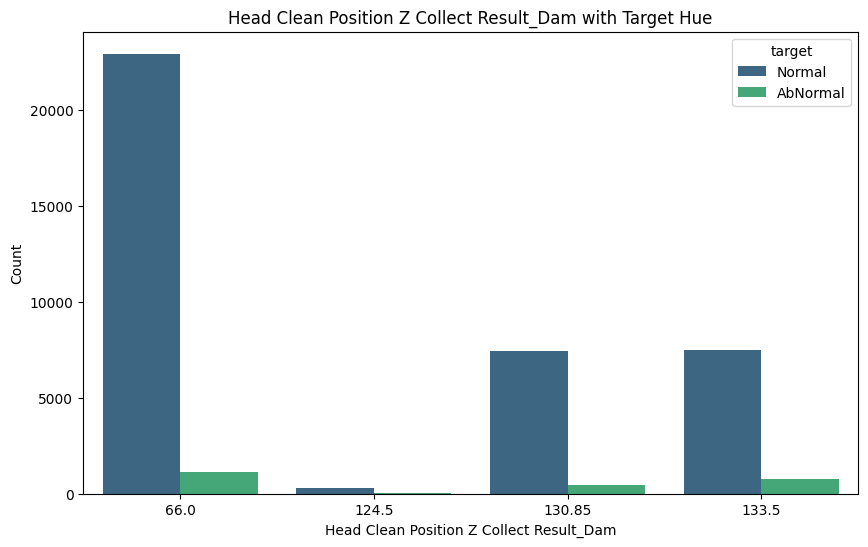

In [45]:

plt.figure(figsize=(10, 6))
sns.countplot(
    data=head_position_df,
    x='Head Clean Position Z Collect Result_Dam',
    hue='target',
    palette='viridis'
)
plt.title('Head Clean Position Z Collect Result_Dam with Target Hue')
plt.xlabel('Head Clean Position Z Collect Result_Dam')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

### Head Purge Position

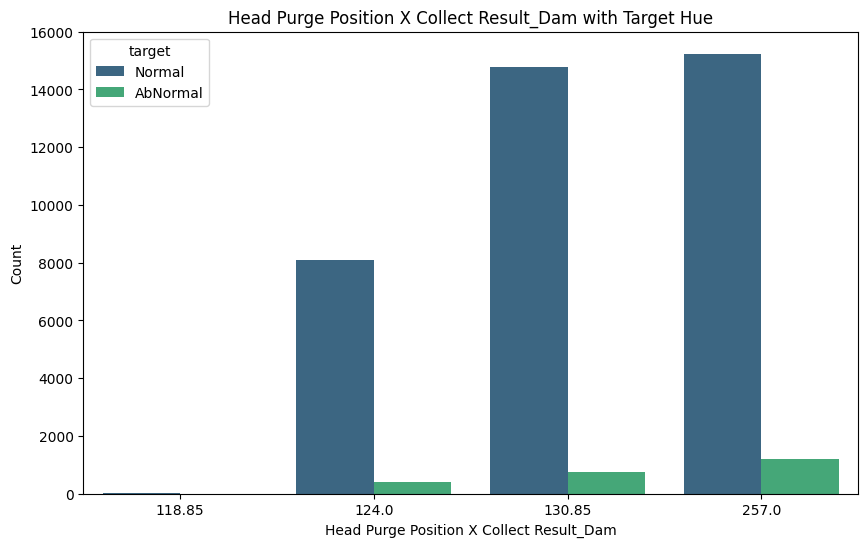

In [46]:
plt.figure(figsize=(10, 6))
sns.countplot(
    data=head_position_df,
    x='Head Purge Position X Collect Result_Dam',
    hue='target',
    palette='viridis'
)
plt.title('Head Purge Position X Collect Result_Dam with Target Hue')
plt.xlabel('Head Purge Position X Collect Result_Dam')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

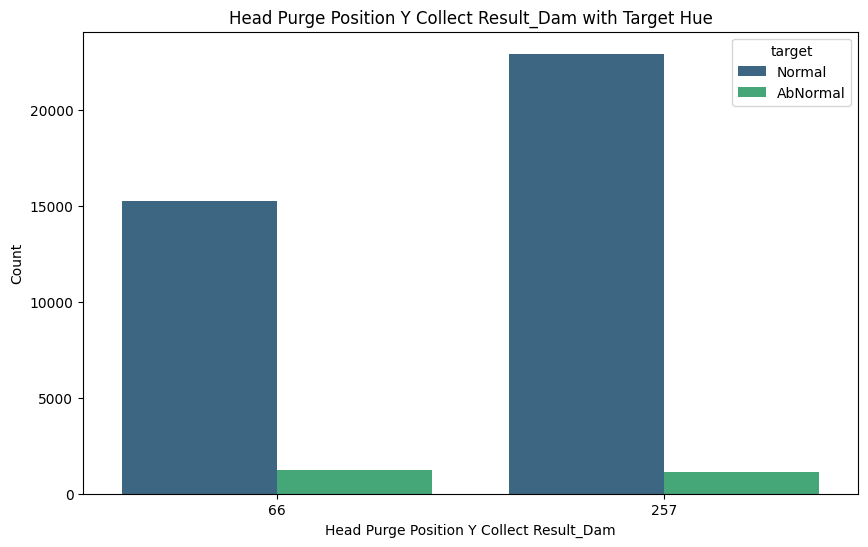

In [47]:
plt.figure(figsize=(10, 6))
sns.countplot(
    data=head_position_df,
    x='Head Purge Position Y Collect Result_Dam',
    hue='target',
    palette='viridis'
)
plt.title('Head Purge Position Y Collect Result_Dam with Target Hue')
plt.xlabel('Head Purge Position Y Collect Result_Dam')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

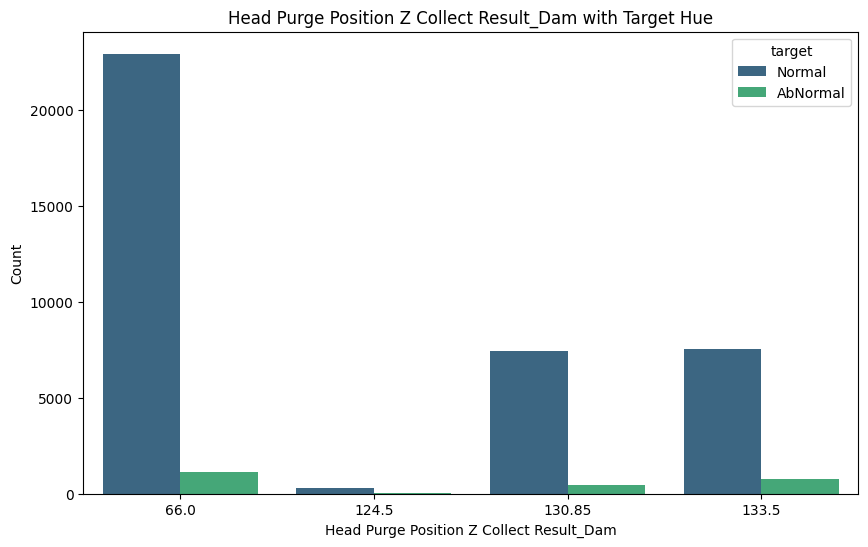

In [48]:
plt.figure(figsize=(10, 6))
sns.countplot(
    data=head_position_df,
    x='Head Purge Position Z Collect Result_Dam',
    hue='target',
    palette='viridis'
)
plt.title('Head Purge Position Z Collect Result_Dam with Target Hue')
plt.xlabel('Head Purge Position Z Collect Result_Dam')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

### Head Zero Position

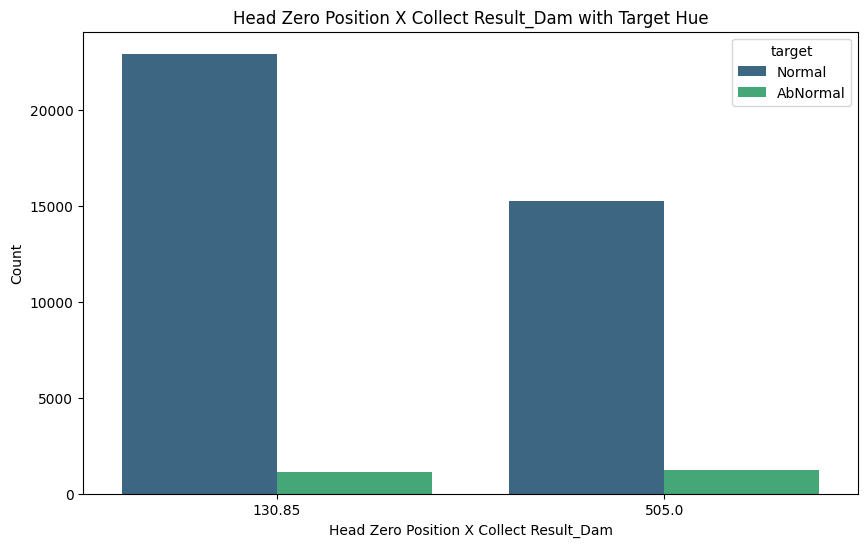

In [49]:
plt.figure(figsize=(10, 6))
sns.countplot(
    data=head_position_df,
    x='Head Zero Position X Collect Result_Dam',
    hue='target',
    palette='viridis'
)
plt.title('Head Zero Position X Collect Result_Dam with Target Hue')
plt.xlabel('Head Zero Position X Collect Result_Dam')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

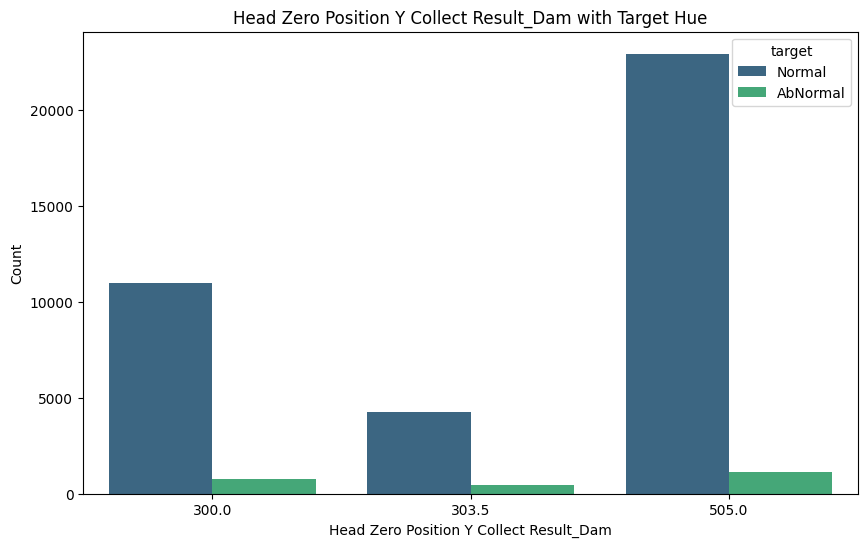

In [50]:
plt.figure(figsize=(10, 6))
sns.countplot(
    data=head_position_df,
    x='Head Zero Position Y Collect Result_Dam',
    hue='target',
    palette='viridis'
)
plt.title('Head Zero Position Y Collect Result_Dam with Target Hue')
plt.xlabel('Head Zero Position Y Collect Result_Dam')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

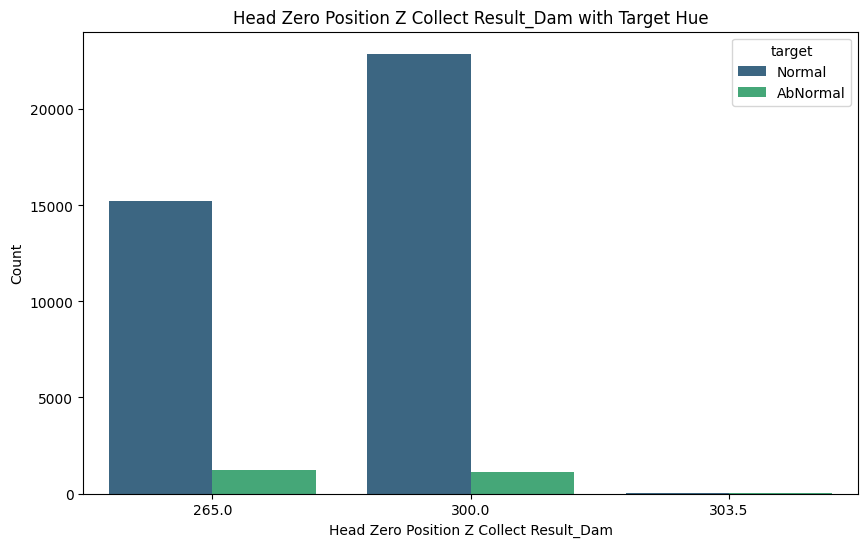

In [51]:
plt.figure(figsize=(10, 6))
sns.countplot(
    data=head_position_df,
    x='Head Zero Position Z Collect Result_Dam',
    hue='target',
    palette='viridis'
)
plt.title('Head Zero Position Z Collect Result_Dam with Target Hue')
plt.xlabel('Head Zero Position Z Collect Result_Dam')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

### Machine Tack time Collect Result_Dam
### PalletID Collect Result_Dam
### Production Qty Collect Result_Dam

In [55]:
# 데이터프레임에서 지정된 칼럼 선택
collect_resulf_df = df_dam_cleaned[
    [
        'Machine Tact time Collect Result_Dam',
        'PalletID Collect Result_Dam',
        'Production Qty Collect Result_Dam' ,
        'target'
    ]
]

# 선택된 데이터프레임 출력
collect_resulf_df

,Machine Tact time Collect Result_Dam,PalletID Collect Result_Dam,Production Qty Collect Result_Dam,target
0,265.00,58.5,7,Normal
1,65.10,7.0,185,Normal
2,265.02,76.9,10,Normal
3,70.50,12.0,268,Normal
4,88.30,8.0,121,Normal
...,...,...,...,...
40501,56.70,1.0,318,Normal
40502,265.00,78.5,14,Normal
40503,265.02,69.5,1,Normal
40504,57.70,13.0,117,Normal


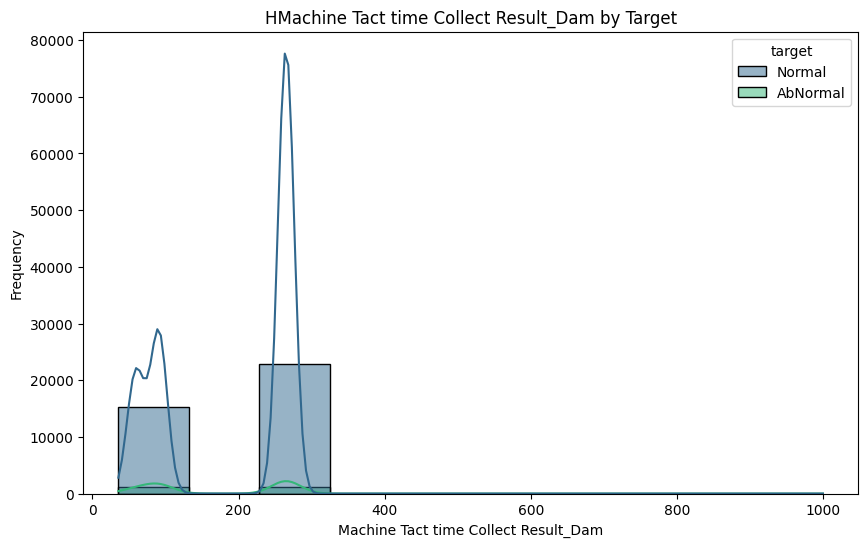

In [59]:
# 히스토그램 시각화
plt.figure(figsize=(10, 6))
sns.histplot(data=collect_resulf_df, x='Machine Tact time Collect Result_Dam', hue='target', bins=10, kde=True, palette='viridis')
plt.title('Machine Tact time Collect Result_Dam by Target')
plt.xlabel('Machine Tact time Collect Result_Dam')
plt.ylabel('Frequency')
plt.show()

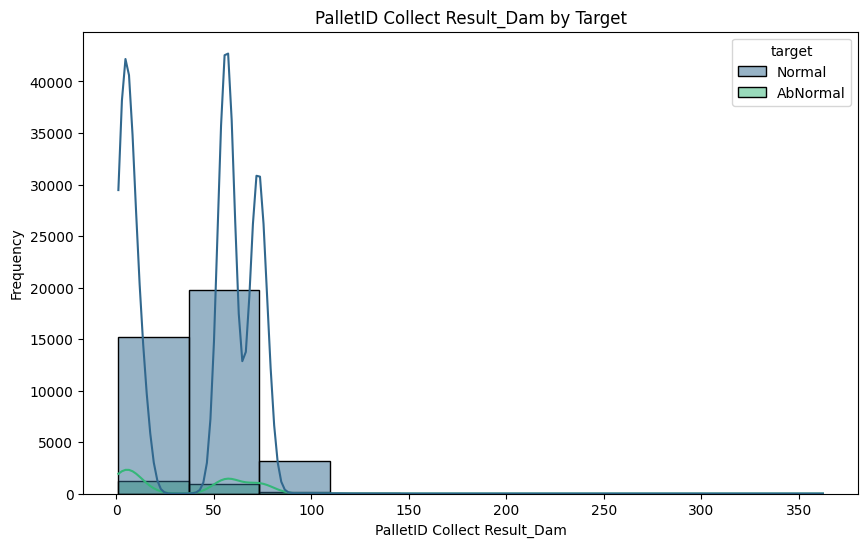

In [61]:
# 히스토그램 시각화
plt.figure(figsize=(10, 6))
sns.histplot(data=collect_resulf_df, x='PalletID Collect Result_Dam', hue='target', bins=10, kde=True, palette='viridis')
plt.title('PalletID Collect Result_Dam by Target')
plt.xlabel('PalletID Collect Result_Dam')
plt.ylabel('Frequency')
plt.show()

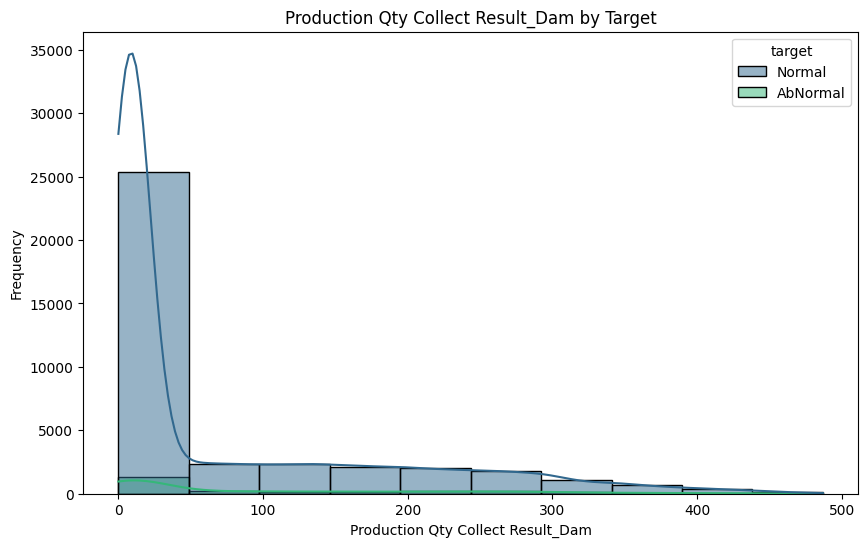

In [62]:
# 히스토그램 시각화
plt.figure(figsize=(10, 6))
sns.histplot(data=collect_resulf_df, x='Production Qty Collect Result_Dam', hue='target', bins=10, kde=True, palette='viridis')
plt.title('Production Qty Collect Result_Dam by Target')
plt.xlabel('Production Qty Collect Result_Dam')
plt.ylabel('Frequency')
plt.show()

### Circle, Line, Distance Speed
 'Stage1 Circle1 Distance Speed Collect Result_Dam',
 
 'Stage1 Circle2 Distance Speed Collect Result_Dam',
 
 'Stage1 Circle3 Distance Speed Collect Result_Dam',
 
 'Stage1 Circle4 Distance Speed Collect Result_Dam',
 
 'Stage1 Line1 Distance Speed Collect Result_Dam',
 
 'Stage1 Line2 Distance Speed Collect Result_Dam',
 
 'Stage1 Line3 Distance Speed Collect Result_Dam',
 
 'Stage1 Line4 Distance Speed Collect Result_Dam',
 
 'Stage2 Circle1 Distance Speed Collect Result_Dam',
 
 
 'Stage2 Circle2 Distance Speed Collect Result_Dam',
 
 'Stage2 Circle3 Distance Speed Collect Result_Dam',
 
 'Stage2 Circle4 Distance Speed Collect Result_Dam',
 
 'Stage2 Line1 Distance Speed Collect Result_Dam',
 
 'Stage2 Line2 Distance Speed Collect Result_Dam',
 
 'Stage2 Line3 Distance Speed Collect Result_Dam',
 
 'Stage2 Line4 Distance Speed Collect Result_Dam',
 
 
 'Stage3 Circle1 Distance Speed Collect Result_Dam',
 
 'Stage3 Circle2 Distance Speed Collect Result_Dam',
 
 'Stage3 Circle3 Distance Speed Collect Result_Dam',
 
 'Stage3 Circle4 Distance Speed Collect Result_Dam',
 
 'Stage3 Line1 Distance Speed Collect Result_Dam',
 
 'Stage3 Line2 Distance Speed Collect Result_Dam',
 
 'Stage3 Line3 Distance Speed Collect Result_Dam',
 
 'Stage3 Line4 Distance Speed Collect Result_Dam',
 

In [25]:
# 데이터프레임에서 지정된 칼럼 선택
circle_line_distance_speed_df = df_dam_cleaned[
    [
        'Stage1 Circle1 Distance Speed Collect Result_Dam',
        'Stage1 Circle2 Distance Speed Collect Result_Dam',
        'Stage1 Circle3 Distance Speed Collect Result_Dam',
        'Stage1 Circle4 Distance Speed Collect Result_Dam',
        'Stage1 Line1 Distance Speed Collect Result_Dam',
        'Stage1 Line2 Distance Speed Collect Result_Dam',
        'Stage1 Line3 Distance Speed Collect Result_Dam',
        'Stage1 Line4 Distance Speed Collect Result_Dam',
        'Stage2 Circle1 Distance Speed Collect Result_Dam',
        'Stage2 Circle2 Distance Speed Collect Result_Dam',
        'Stage2 Circle3 Distance Speed Collect Result_Dam',
        'Stage2 Circle4 Distance Speed Collect Result_Dam',
        'Stage2 Line1 Distance Speed Collect Result_Dam',
        'Stage2 Line2 Distance Speed Collect Result_Dam',
        'Stage2 Line3 Distance Speed Collect Result_Dam',
        'Stage2 Line4 Distance Speed Collect Result_Dam',
        'Stage3 Circle1 Distance Speed Collect Result_Dam',
        'Stage3 Circle2 Distance Speed Collect Result_Dam',
        'Stage3 Circle3 Distance Speed Collect Result_Dam',
        'Stage3 Circle4 Distance Speed Collect Result_Dam',
        'Stage3 Line1 Distance Speed Collect Result_Dam',
        'Stage3 Line2 Distance Speed Collect Result_Dam',
        'Stage3 Line3 Distance Speed Collect Result_Dam',
        'Stage3 Line4 Distance Speed Collect Result_Dam',
        'target'
    ]
]

# 선택된 데이터프레임 출력
circle_line_distance_speed_df 

,Stage1 Circle1 Distance Speed Collect Result_Dam,Stage1 Circle2 Distance Speed Collect Result_Dam,Stage1 Circle3 Distance Speed Collect Result_Dam,Stage1 Circle4 Distance Speed Collect Result_Dam,Stage1 Line1 Distance Speed Collect Result_Dam,Stage1 Line2 Distance Speed Collect Result_Dam,Stage1 Line3 Distance Speed Collect Result_Dam,Stage1 Line4 Distance Speed Collect Result_Dam,Stage2 Circle1 Distance Speed Collect Result_Dam,Stage2 Circle2 Distance Speed Collect Result_Dam,...,Stage2 Line4 Distance Speed Collect Result_Dam,Stage3 Circle1 Distance Speed Collect Result_Dam,Stage3 Circle2 Distance Speed Collect Result_Dam,Stage3 Circle3 Distance Speed Collect Result_Dam,Stage3 Circle4 Distance Speed Collect Result_Dam,Stage3 Line1 Distance Speed Collect Result_Dam,Stage3 Line2 Distance Speed Collect Result_Dam,Stage3 Line3 Distance Speed Collect Result_Dam,Stage3 Line4 Distance Speed Collect Result_Dam,target
0,1,5800,5800,5800,5800,5800,5800,5600,5800,5300,...,5300,5300,5800,5800,5800,5800,5800,5800,5800,Normal
1,4000,4000,4000,4000,4000,4000,4000,4000,9000,9000,...,9000,4000,4000,4000,4000,4000,4000,4000,4000,Normal
2,1,5800,5800,5800,5800,5800,5800,5800,5800,5300,...,5300,5300,5800,5800,5800,5800,5800,5800,5800,Normal
3,4000,4000,4000,4000,4000,4000,4000,4000,5000,5000,...,5000,4000,4000,4000,4000,4000,4000,4000,4000,Normal
4,9000,9000,9000,9000,9000,9000,9000,9000,9000,9000,...,9000,9000,9000,9000,9000,9000,9000,9000,9000,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40501,5000,5000,5000,5000,5000,5000,5000,5000,9000,9000,...,9000,5000,5000,5000,5000,5000,5000,5000,5000,Normal
40502,1,5800,5800,5800,5800,5800,5800,5600,5800,5300,...,5300,5300,5800,5800,5800,5800,5800,5800,5800,Normal
40503,1,6000,6000,6000,6000,6000,6000,6000,6000,5500,...,5500,5500,6000,6000,6000,6000,6000,6000,6000,Normal
40504,9000,9000,9000,9000,9000,9000,9000,9000,9000,9000,...,9000,9000,9000,9000,9000,9000,9000,9000,9000,Normal


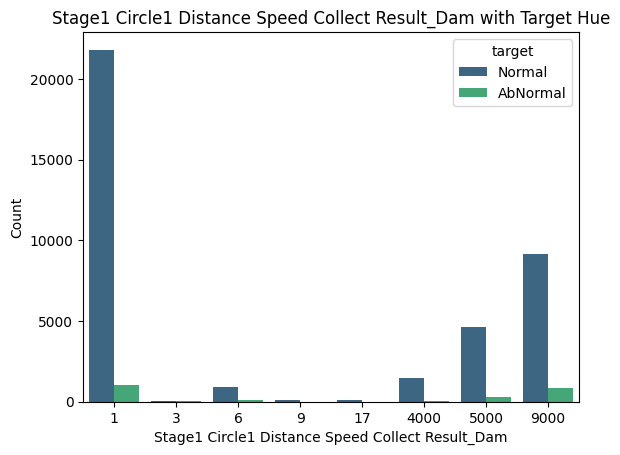

In [69]:
#plt.figure(figsize=(10, 6))
sns.countplot(
    data=circle_line_distance_speed_df ,
    x='Stage1 Circle1 Distance Speed Collect Result_Dam',
    hue='target',
    palette='viridis'
)
plt.title('Stage1 Circle1 Distance Speed Collect Result_Dam with Target Hue')
plt.xlabel('Stage1 Circle1 Distance Speed Collect Result_Dam')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

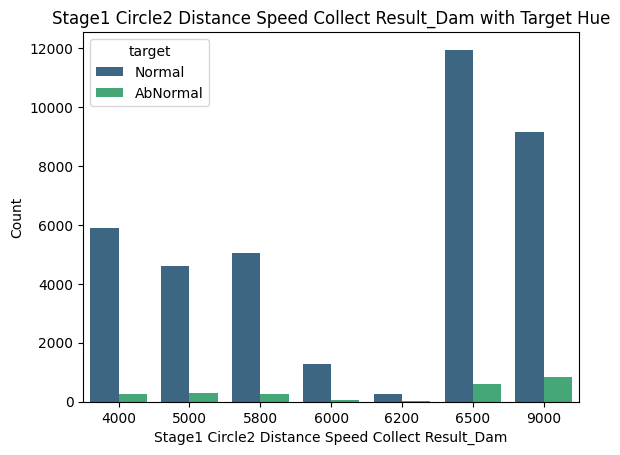

In [70]:
#plt.figure(figsize=(10, 6))
sns.countplot(
    data=circle_line_distance_speed_df ,
    x='Stage1 Circle2 Distance Speed Collect Result_Dam',
    hue='target',
    palette='viridis'
)
plt.title('Stage1 Circle2 Distance Speed Collect Result_Dam with Target Hue')
plt.xlabel('Stage1 Circle2 Distance Speed Collect Result_Dam')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

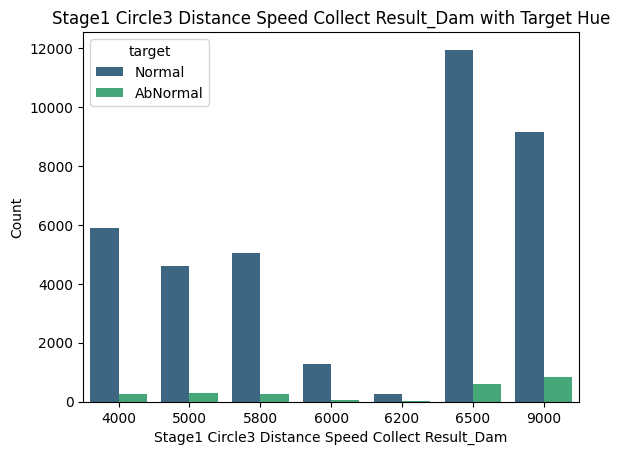

In [71]:
#plt.figure(figsize=(10, 6))
sns.countplot(
    data=circle_line_distance_speed_df ,
    x='Stage1 Circle3 Distance Speed Collect Result_Dam',
    hue='target',
    palette='viridis'
)
plt.title('Stage1 Circle3 Distance Speed Collect Result_Dam with Target Hue')
plt.xlabel('Stage1 Circle3 Distance Speed Collect Result_Dam')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

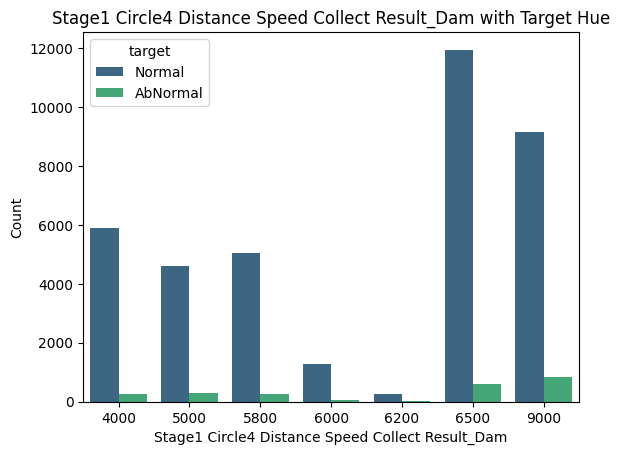

In [72]:
#plt.figure(figsize=(10, 6))
sns.countplot(
    data=circle_line_distance_speed_df ,
    x='Stage1 Circle4 Distance Speed Collect Result_Dam',
    hue='target',
    palette='viridis'
)
plt.title('Stage1 Circle4 Distance Speed Collect Result_Dam with Target Hue')
plt.xlabel('Stage1 Circle4 Distance Speed Collect Result_Dam')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

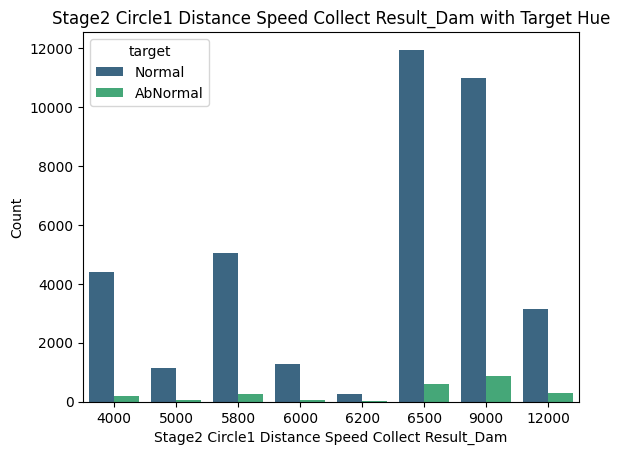

In [73]:
#plt.figure(figsize=(10, 6))
sns.countplot(
    data=circle_line_distance_speed_df ,
    x='Stage2 Circle1 Distance Speed Collect Result_Dam',
    hue='target',
    palette='viridis'
)
plt.title('Stage2 Circle1 Distance Speed Collect Result_Dam with Target Hue')
plt.xlabel('Stage2 Circle1 Distance Speed Collect Result_Dam')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

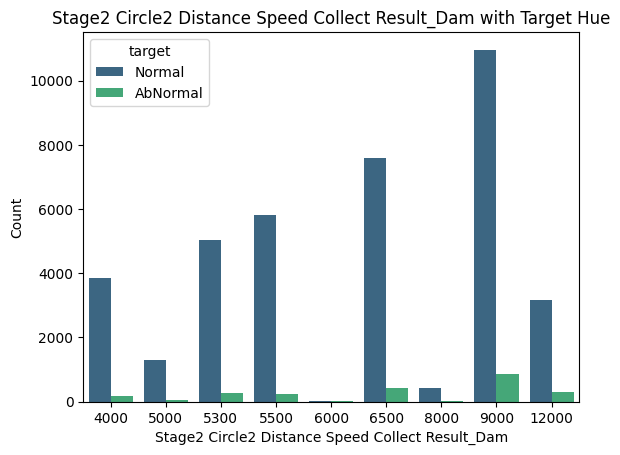

In [26]:
#plt.figure(figsize=(10, 6))
sns.countplot(
    data=circle_line_distance_speed_df ,
    x='Stage2 Circle2 Distance Speed Collect Result_Dam',
    hue='target',
    palette='viridis'
)
plt.title('Stage2 Circle2 Distance Speed Collect Result_Dam with Target Hue')
plt.xlabel('Stage2 Circle2 Distance Speed Collect Result_Dam')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

# THICKNESS
'THICKNESS 1 Collect Result_Dam',

'THICKNESS 2 Collect Result_Dam',

'THICKNESS 3 Collect Result_Dam',

In [29]:
# 데이터프레임에서 지정된 칼럼 선택
thickness_df = df_dam_cleaned[
    [
        'THICKNESS 1 Collect Result_Dam',
        'THICKNESS 2 Collect Result_Dam',
        'THICKNESS 3 Collect Result_Dam',
        'target'
    ]
]

# 선택된 데이터프레임 출력
thickness_df 

,THICKNESS 1 Collect Result_Dam,THICKNESS 2 Collect Result_Dam,THICKNESS 3 Collect Result_Dam,target
0,5800,0.000,0.000,Normal
1,0,0.000,0.000,Normal
2,5800,0.012,-0.022,Normal
3,0,0.000,0.000,Normal
4,0,0.000,0.000,Normal
...,...,...,...,...
40501,0,0.000,0.000,Normal
40502,5800,-0.019,-0.021,Normal
40503,6000,0.000,0.000,Normal
40504,0,0.000,0.000,Normal


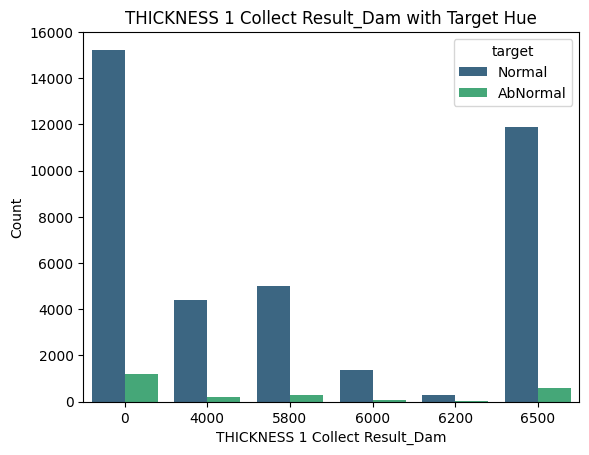

In [30]:
#plt.figure(figsize=(10, 6))
sns.countplot(
    data=thickness_df ,
    x='THICKNESS 1 Collect Result_Dam',
    hue='target',
    palette='viridis'
)
plt.title('THICKNESS 1 Collect Result_Dam with Target Hue')
plt.xlabel('THICKNESS 1 Collect Result_Dam')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

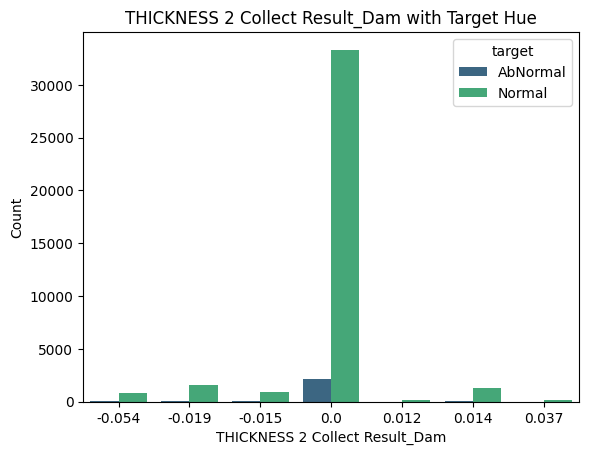

In [31]:
#plt.figure(figsize=(10, 6))
sns.countplot(
    data=thickness_df ,
    x='THICKNESS 2 Collect Result_Dam',
    hue='target',
    palette='viridis'
)
plt.title('THICKNESS 2 Collect Result_Dam with Target Hue')
plt.xlabel('THICKNESS 2 Collect Result_Dam')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

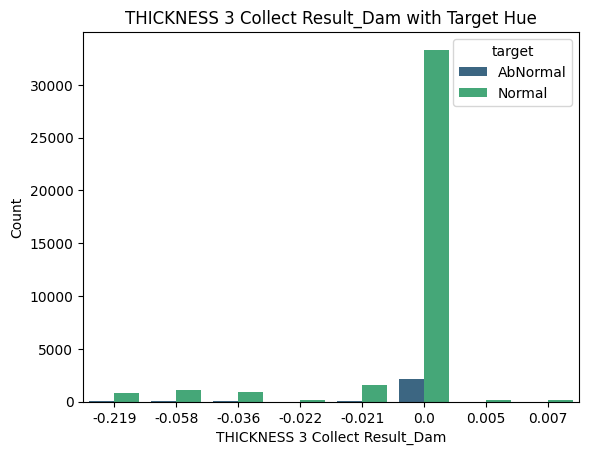

In [32]:
#plt.figure(figsize=(10, 6))
sns.countplot(
    data=thickness_df ,
    x='THICKNESS 3 Collect Result_Dam',
    hue='target',
    palette='viridis'
)
plt.title('THICKNESS 3 Collect Result_Dam with Target Hue')
plt.xlabel('THICKNESS 3 Collect Result_Dam')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

### WorkMode Collect Result_Dam

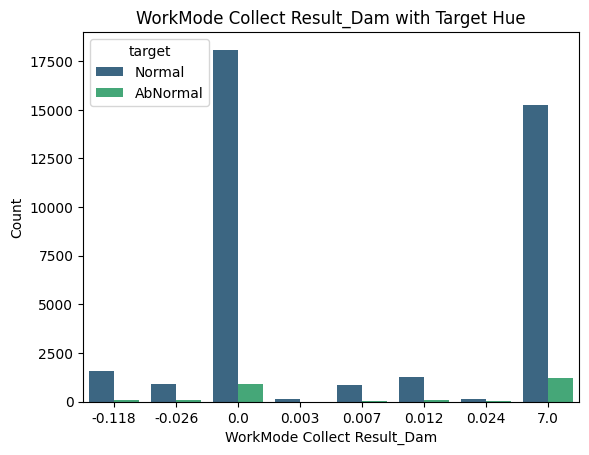

In [33]:
#plt.figure(figsize=(10, 6))
sns.countplot(
    data= df_dam_cleaned,
    x='WorkMode Collect Result_Dam',
    hue='target',
    palette='viridis'
)
plt.title('WorkMode Collect Result_Dam with Target Hue')
plt.xlabel('WorkMode Collect Result_Dam')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

# 2. AutoClave 데이터 분석
탈포


Model.Suffix_AutoClave

압력값<br/>
1st Pressure Collect Result_AutoClave<br/>
2nd Pressure Collect Result_AutoClave<br/>
3rd Pressure Collect Result_AutoClave<br/>
 
압력 시간<br/>
1st Pressure 1st Pressure Unit Time_AutoClave<br/>
2nd Pressure Unit Time_AutoClave<br/>
3rd Pressure Unit Time_AutoClave<br/>

압력 Judge Value<br/>
1st Pressure Judge Value_AutoClave<br/>
2nd Pressure Judge Value_AutoClave<br/>
3rd Pressure Judge Value_AutoClave<br/>
 
Chamber 온도<br/>
Chamber Temp. Collect Result_AutoClave<br/>
Chamber Temp. Unit Time_AutoClave<br/>
Chamber Temp. Judge Value_AutoClave<br/>


GMES_ORIGIN_INSP_JUDGE_CODE Collect Result_AutoClave<br/>
GMES_ORIGIN_INSP_JUDGE_CODE Judge Value_AutoClave<br/>


target

In [176]:
df_autoclave

,Wip Line_AutoClave,Process Desc._AutoClave,Equipment_AutoClave,Model.Suffix_AutoClave,Insp. Seq No._AutoClave,Insp Judge Code_AutoClave,1st Pressure Collect Result_AutoClave,1st Pressure 1st Pressure Unit Time_AutoClave,1st Pressure Judge Value_AutoClave,2nd Pressure Collect Result_AutoClave,...,2nd Pressure Judge Value_AutoClave,3rd Pressure Collect Result_AutoClave,3rd Pressure Unit Time_AutoClave,3rd Pressure Judge Value_AutoClave,Chamber Temp. Collect Result_AutoClave,Chamber Temp. Unit Time_AutoClave,Chamber Temp. Judge Value_AutoClave,GMES_ORIGIN_INSP_JUDGE_CODE Collect Result_AutoClave,GMES_ORIGIN_INSP_JUDGE_CODE Judge Value_AutoClave,target
0,IVI-OB6,Auto Clave Out,Auto Clave Out,AJX75334505,1,OK,0.312,240,OK,0.493,...,OK,0.499,120,OK,54,361,OK,NaN,NaN,Normal
1,IVI-OB6,Auto Clave Out,Auto Clave Out,AJX75334505,1,OK,0.311,241,OK,0.311,...,OK,0.498,121,OK,54,483,OK,NaN,NaN,Normal
2,IVI-OB6,Auto Clave Out,Auto Clave Out,AJX75334501,1,OK,0.315,241,OK,0.490,...,OK,0.498,121,OK,56,363,OK,OK,OK,Normal
3,IVI-OB6,Auto Clave Out,Auto Clave Out,AJX75334501,1,OK,0.299,241,OK,0.300,...,OK,0.500,121,OK,54,483,OK,NaN,NaN,Normal
4,IVI-OB6,Auto Clave Out,Auto Clave Out,AJX75334501,1,OK,0.302,240,OK,0.302,...,OK,0.498,120,OK,47,480,NG,NaN,NaN,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40501,IVI-OB6,Auto Clave Out,Auto Clave Out,AJX75334501,1,OK,0.300,241,OK,0.300,...,OK,0.500,121,OK,54,483,OK,NaN,NaN,Normal
40502,IVI-OB6,Auto Clave Out,Auto Clave Out,AJX75334501,1,OK,0.305,240,OK,0.493,...,OK,0.498,120,OK,49,361,NG,NaN,NaN,Normal
40503,IVI-OB6,Auto Clave Out,Auto Clave Out,AJX75334501,1,OK,0.309,241,OK,0.490,...,OK,0.498,121,OK,48,363,NG,OK,OK,Normal
40504,IVI-OB6,Auto Clave Out,Auto Clave Out,AJX75334501,1,OK,0.302,241,OK,0.303,...,OK,0.499,121,OK,54,483,OK,NaN,NaN,Normal


In [30]:
list(df_autoclave.columns) 

['Wip Line_AutoClave',
 'Process Desc._AutoClave',
 'Equipment_AutoClave',
 'Model.Suffix_AutoClave',
 'Insp. Seq No._AutoClave',
 'Insp Judge Code_AutoClave',
 '1st Pressure Collect Result_AutoClave',
 '1st Pressure 1st Pressure Unit Time_AutoClave',
 '1st Pressure Judge Value_AutoClave',
 '2nd Pressure Collect Result_AutoClave',
 '2nd Pressure Unit Time_AutoClave',
 '2nd Pressure Judge Value_AutoClave',
 '3rd Pressure Collect Result_AutoClave',
 '3rd Pressure Unit Time_AutoClave',
 '3rd Pressure Judge Value_AutoClave',
 'Chamber Temp. Collect Result_AutoClave',
 'Chamber Temp. Unit Time_AutoClave',
 'Chamber Temp. Judge Value_AutoClave',
 'GMES_ORIGIN_INSP_JUDGE_CODE Collect Result_AutoClave',
 'GMES_ORIGIN_INSP_JUDGE_CODE Judge Value_AutoClave',
 'target']

In [31]:
for column in df_autoclave.columns:
    unique_values = df_autoclave[column].unique()
    print(f'Column: {column}')
    print(f'Unique values: {unique_values}')
    print
    

Column: Wip Line_AutoClave
Unique values: ['IVI-OB6']

Column: Process Desc._AutoClave
Unique values: ['Auto Clave Out']

Column: Equipment_AutoClave
Unique values: ['Auto Clave Out']

Column: Model.Suffix_AutoClave
Unique values: ['AJX75334505' 'AJX75334501' 'AJX75334502' 'AJX75334507' 'AJX75334506'
 'AJX75334508' 'AJX75334503']

Column: Insp. Seq No._AutoClave
Unique values: [1]

Column: Insp Judge Code_AutoClave
Unique values: ['OK']

Column: 1st Pressure Collect Result_AutoClave
Unique values: [0.312 0.311 0.315 0.299 0.302 0.316 0.31  0.313 0.303 0.308 0.309 0.304
 0.3   0.301 0.314 0.305 0.307 0.306 0.297 0.298 0.319 0.317 0.318 0.29
 0.292 0.295 0.296]

Column: 1st Pressure 1st Pressure Unit Time_AutoClave
Unique values: [240 241 300 181 180   1  61   0  60]

Column: 1st Pressure Judge Value_AutoClave
Unique values: ['OK']

Column: 2nd Pressure Collect Result_AutoClave
Unique values: [0.493 0.311 0.49  0.3   0.302 0.501 0.492 0.314 0.491 0.303 0.317 0.304
 0.316 0.581 0.58  0.5 

#### 데이터의 값이 한가지인 칼럼
Wip Line_AutoClave

Process Desc._AutoClave 

Equipment_AutoClave 

Insp. Seq No._AutoClave

Insp Judge Code_AutoClave

1st Pressure Judge Value_AutoClave

2nd Pressure Judge Value_AutoClave

3rd Pressure Judge Value_AutoClave

#### 데이터의 값이 nan 또는 OK 뿐인 칼럼
GMES_ORIGIN_INSP_JUDGE_CODE Collect Result_AutoClave

GMES_ORIGIN_INSP_JUDGE_CODE Judge Value_AutoClave

### 분석을 위해 데이터의 값이 nan인 데이터를 'Nan' 으로 변경해준다 . 

In [51]:
df_autoclave['GMES_ORIGIN_INSP_JUDGE_CODE Collect Result_AutoClave'] = df_autoclave['GMES_ORIGIN_INSP_JUDGE_CODE Collect Result_AutoClave'].fillna('NaN')
df_autoclave['GMES_ORIGIN_INSP_JUDGE_CODE Judge Value_AutoClave'] = df_autoclave['GMES_ORIGIN_INSP_JUDGE_CODE Judge Value_AutoClave'].fillna('NaN')

/tmp/ipykernel_93/563418551.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_autoclave['GMES_ORIGIN_INSP_JUDGE_CODE Collect Result_AutoClave'] = df_autoclave['GMES_ORIGIN_INSP_JUDGE_CODE Collect Result_AutoClave'].fillna('NaN')
/tmp/ipykernel_93/563418551.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_autoclave['GMES_ORIGIN_INSP_JUDGE_CODE Judge Value_AutoClave'] = df_autoclave['GMES_ORIGIN_INSP_JUDGE_CODE Judge Value_AutoClave'].fillna('NaN')


### 데이터 값이 한가지인 칼럼 제거

In [52]:
# unique 값이 1개인 열을 찾기
columns_with_unique_values_1 = [col for col in df_autoclave.columns if df_autoclave[col].nunique() == 1]
print('Unique 값이 1개')
for col in columns_with_unique_values_1:
    print(col)

Unique 값이 1개
Wip Line_AutoClave
Process Desc._AutoClave
Equipment_AutoClave
Insp. Seq No._AutoClave
Insp Judge Code_AutoClave
1st Pressure Judge Value_AutoClave
2nd Pressure Judge Value_AutoClave
3rd Pressure Judge Value_AutoClave


In [64]:
df_autoclave_cleaned = df_autoclave.drop(columns=columns_with_unique_values_1)

print("\n칼럼 제거 후 데이터프레임:")
df_autoclave_cleaned


칼럼 제거 후 데이터프레임:


,Model.Suffix_AutoClave,1st Pressure Collect Result_AutoClave,1st Pressure 1st Pressure Unit Time_AutoClave,2nd Pressure Collect Result_AutoClave,2nd Pressure Unit Time_AutoClave,3rd Pressure Collect Result_AutoClave,3rd Pressure Unit Time_AutoClave,Chamber Temp. Collect Result_AutoClave,Chamber Temp. Unit Time_AutoClave,Chamber Temp. Judge Value_AutoClave,GMES_ORIGIN_INSP_JUDGE_CODE Collect Result_AutoClave,GMES_ORIGIN_INSP_JUDGE_CODE Judge Value_AutoClave,target
0,AJX75334505,0.312,240,0.493,1,0.499,120,54,361,OK,NaN,NaN,Normal
1,AJX75334505,0.311,241,0.311,121,0.498,121,54,483,OK,NaN,NaN,Normal
2,AJX75334501,0.315,241,0.490,1,0.498,121,56,363,OK,OK,OK,Normal
3,AJX75334501,0.299,241,0.300,121,0.500,121,54,483,OK,NaN,NaN,Normal
4,AJX75334501,0.302,240,0.302,120,0.498,120,47,480,NG,NaN,NaN,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...
40501,AJX75334501,0.300,241,0.300,121,0.500,121,54,483,OK,NaN,NaN,Normal
40502,AJX75334501,0.305,240,0.493,1,0.498,120,49,361,NG,NaN,NaN,Normal
40503,AJX75334501,0.309,241,0.490,1,0.498,121,48,363,NG,OK,OK,Normal
40504,AJX75334501,0.302,241,0.303,121,0.499,121,54,483,OK,NaN,NaN,Normal


In [111]:
list(df_autoclave_cleaned.columns) 

['Model.Suffix_AutoClave',
 '1st Pressure Collect Result_AutoClave',
 '1st Pressure 1st Pressure Unit Time_AutoClave',
 '2nd Pressure Collect Result_AutoClave',
 '2nd Pressure Unit Time_AutoClave',
 '3rd Pressure Collect Result_AutoClave',
 '3rd Pressure Unit Time_AutoClave',
 'Chamber Temp. Collect Result_AutoClave',
 'Chamber Temp. Unit Time_AutoClave',
 'Chamber Temp. Judge Value_AutoClave',
 'target']

#### GMES_ORIGIN_INSP_JUDGE_CODE Collect Result_AutoClave 과 GMES_ORIGIN_INSP_JUDGE_CODE Judge Value_AutoClave의 데이터 분포 확인

In [55]:
df_autoclave_cleaned['GMES_ORIGIN_INSP_JUDGE_CODE Collect Result_AutoClave'].value_counts()

GMES_ORIGIN_INSP_JUDGE_CODE Collect Result_AutoClave
NaN    29213
OK     11293
Name: count, dtype: int64

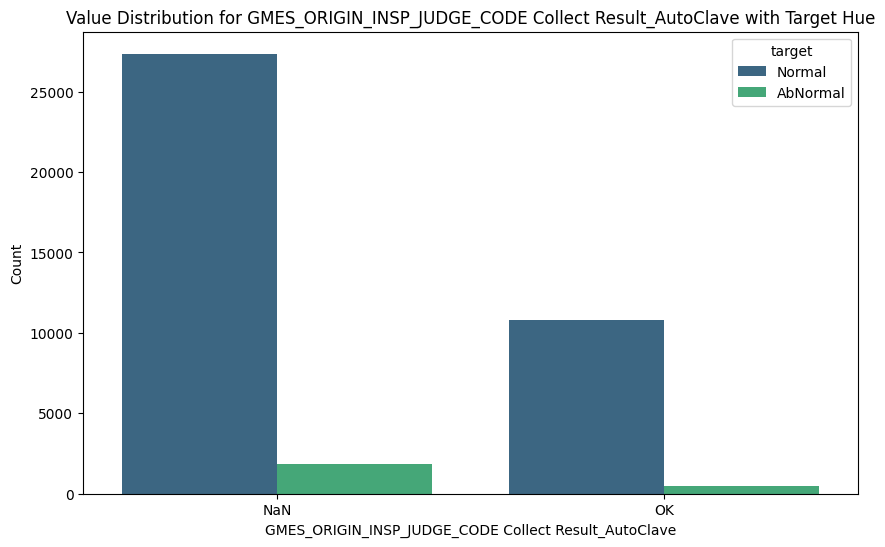

In [57]:
plt.figure(figsize=(10, 6))
sns.countplot(
    data=df_autoclave,
    x='GMES_ORIGIN_INSP_JUDGE_CODE Collect Result_AutoClave',
    hue='target',
    palette='viridis'
)
plt.title('Value Distribution for GMES_ORIGIN_INSP_JUDGE_CODE Collect Result_AutoClave with Target Hue')
plt.xlabel('GMES_ORIGIN_INSP_JUDGE_CODE Collect Result_AutoClave')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

In [59]:
df_autoclave_cleaned['GMES_ORIGIN_INSP_JUDGE_CODE Judge Value_AutoClave'].value_counts()

GMES_ORIGIN_INSP_JUDGE_CODE Judge Value_AutoClave
NaN    29213
OK     11293
Name: count, dtype: int64

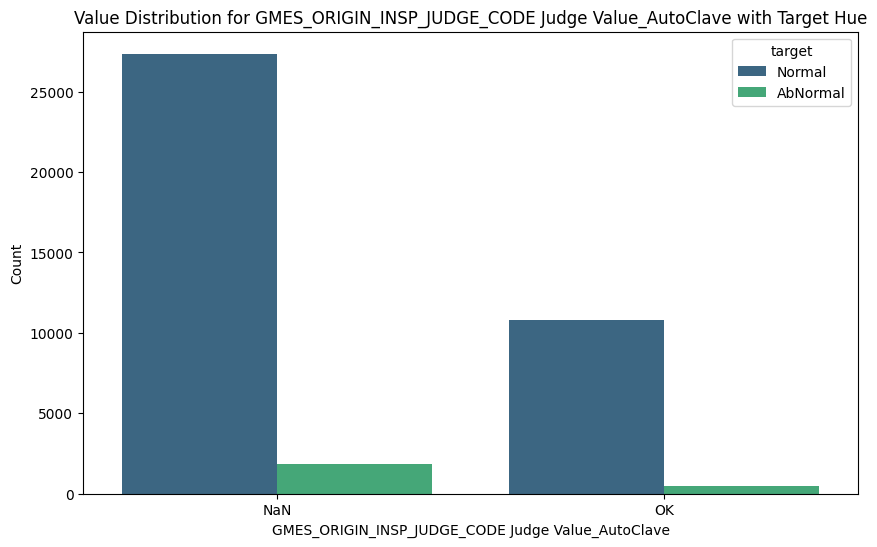

In [58]:
plt.figure(figsize=(10, 6))
sns.countplot(
    data=df_autoclave,
    x='GMES_ORIGIN_INSP_JUDGE_CODE Judge Value_AutoClave',
    hue='target',
    palette='viridis'
)
plt.title('Value Distribution for GMES_ORIGIN_INSP_JUDGE_CODE Judge Value_AutoClave with Target Hue')
plt.xlabel('GMES_ORIGIN_INSP_JUDGE_CODE Judge Value_AutoClave')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

GMES_ORIGIN_INSP_JUDGE_CODE Judge Value_AutoClave 와 GMES_ORIGIN_INSP_JUDGE_CODE Collect Result_AutoClave은 공통된 값을 가지고 있으며 해당 데이터는 타겟을 분류하는데 큰 영향을 미치지 못하는 것으로 판단된다

In [65]:
df_autoclave_cleaned = df_autoclave_cleaned.drop(['GMES_ORIGIN_INSP_JUDGE_CODE Judge Value_AutoClave','GMES_ORIGIN_INSP_JUDGE_CODE Collect Result_AutoClave'], axis = 1)

In [66]:
df_autoclave_cleaned

,Model.Suffix_AutoClave,1st Pressure Collect Result_AutoClave,1st Pressure 1st Pressure Unit Time_AutoClave,2nd Pressure Collect Result_AutoClave,2nd Pressure Unit Time_AutoClave,3rd Pressure Collect Result_AutoClave,3rd Pressure Unit Time_AutoClave,Chamber Temp. Collect Result_AutoClave,Chamber Temp. Unit Time_AutoClave,Chamber Temp. Judge Value_AutoClave,target
0,AJX75334505,0.312,240,0.493,1,0.499,120,54,361,OK,Normal
1,AJX75334505,0.311,241,0.311,121,0.498,121,54,483,OK,Normal
2,AJX75334501,0.315,241,0.490,1,0.498,121,56,363,OK,Normal
3,AJX75334501,0.299,241,0.300,121,0.500,121,54,483,OK,Normal
4,AJX75334501,0.302,240,0.302,120,0.498,120,47,480,NG,Normal
...,...,...,...,...,...,...,...,...,...,...,...
40501,AJX75334501,0.300,241,0.300,121,0.500,121,54,483,OK,Normal
40502,AJX75334501,0.305,240,0.493,1,0.498,120,49,361,NG,Normal
40503,AJX75334501,0.309,241,0.490,1,0.498,121,48,363,NG,Normal
40504,AJX75334501,0.302,241,0.303,121,0.499,121,54,483,OK,Normal


### Model.Suffix_AutoClave 데이터 분석

In [67]:
df_autoclave_cleaned['Model.Suffix_AutoClave'].value_counts()

Model.Suffix_AutoClave
AJX75334501    33820
AJX75334502     3390
AJX75334505     2635
AJX75334507      310
AJX75334503      162
AJX75334506      129
AJX75334508       60
Name: count, dtype: int64

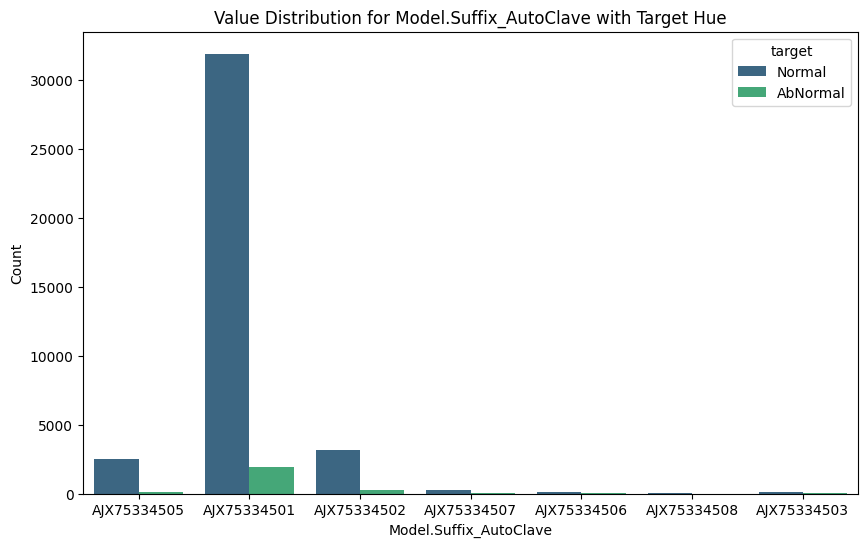

In [68]:
plt.figure(figsize=(10, 6))
sns.countplot(
    data=df_autoclave,
    x='Model.Suffix_AutoClave',
    hue='target',
    palette='viridis'
)
plt.title('Value Distribution for Model.Suffix_AutoClave with Target Hue')
plt.xlabel('Model.Suffix_AutoClave')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

In [81]:
suffix_target_distribution = df_autoclave_cleaned.groupby('Model.Suffix_AutoClave')['target'].value_counts().unstack()
suffix_target_distribution

target,AbNormal,Normal
Model.Suffix_AutoClave,,
AJX75334501,1918,31902
AJX75334502,230,3160
AJX75334503,44,118
AJX75334505,130,2505
AJX75334506,8,121
AJX75334507,18,292
AJX75334508,2,58


### Pressure Collect Result_AutoClave 데이터 분석

In [85]:
pressure_collect_result = df_autoclave_cleaned[['1st Pressure Collect Result_AutoClave','2nd Pressure Collect Result_AutoClave','3rd Pressure Collect Result_AutoClave','target']]
pressure_collect_result

,1st Pressure Collect Result_AutoClave,2nd Pressure Collect Result_AutoClave,3rd Pressure Collect Result_AutoClave,target
0,0.312,0.493,0.499,Normal
1,0.311,0.311,0.498,Normal
2,0.315,0.490,0.498,Normal
3,0.299,0.300,0.500,Normal
4,0.302,0.302,0.498,Normal
...,...,...,...,...
40501,0.300,0.300,0.500,Normal
40502,0.305,0.493,0.498,Normal
40503,0.309,0.490,0.498,Normal
40504,0.302,0.303,0.499,Normal


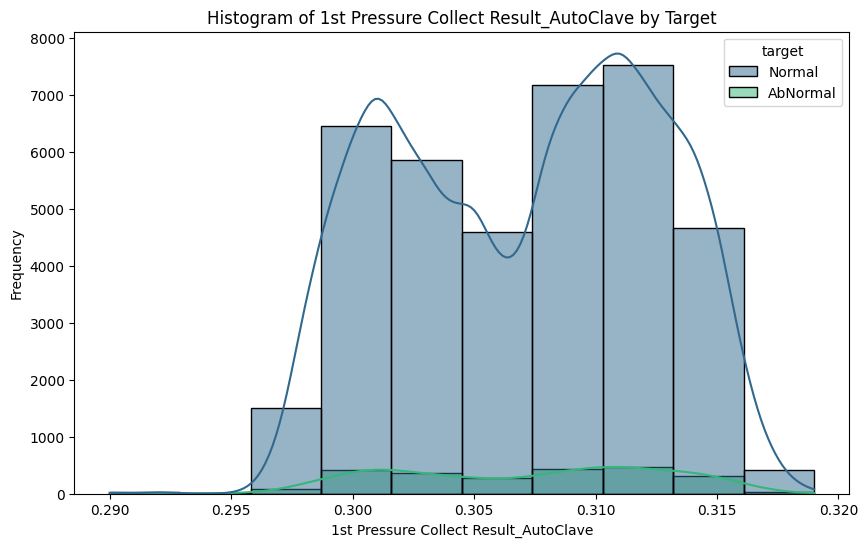

In [89]:
# 히스토그램 시각화
plt.figure(figsize=(10, 6))
sns.histplot(data=pressure_collect_result, x='1st Pressure Collect Result_AutoClave', hue='target', bins=10, kde=True, palette='viridis')
plt.title('Histogram of 1st Pressure Collect Result_AutoClave by Target')
plt.xlabel('1st Pressure Collect Result_AutoClave')
plt.ylabel('Frequency')
plt.show()

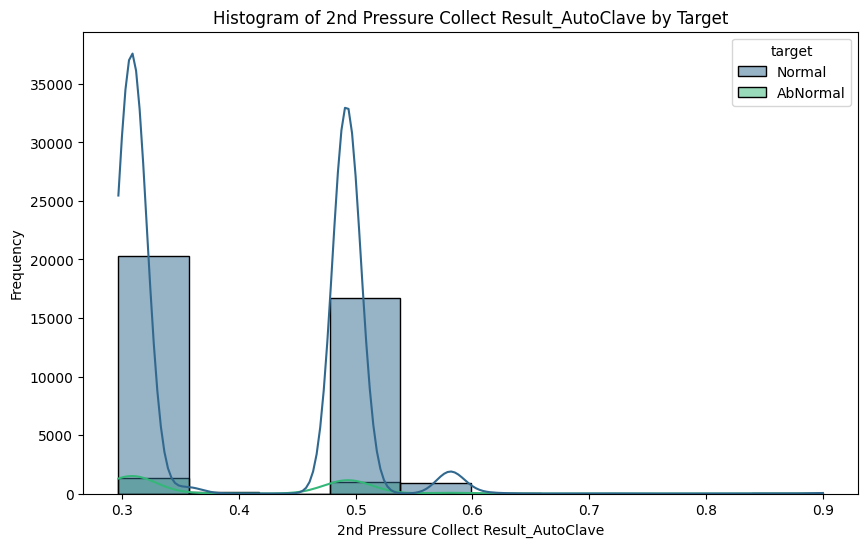

In [90]:
# 히스토그램 시각화
plt.figure(figsize=(10, 6))
sns.histplot(data=pressure_collect_result, x='2nd Pressure Collect Result_AutoClave', hue='target', bins=10, kde=True, palette='viridis')
plt.title('Histogram of 2nd Pressure Collect Result_AutoClave by Target')
plt.xlabel('2nd Pressure Collect Result_AutoClave')
plt.ylabel('Frequency')
plt.show()

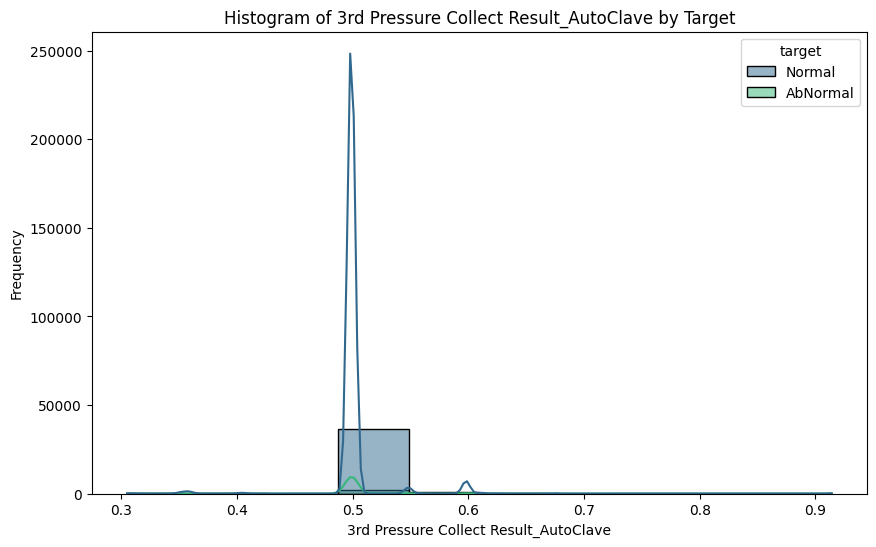

In [91]:
# 히스토그램 시각화
plt.figure(figsize=(10, 6))
sns.histplot(data=pressure_collect_result, x='3rd Pressure Collect Result_AutoClave', hue='target', bins=10, kde=True, palette='viridis')
plt.title('Histogram of 3rd Pressure Collect Result_AutoClave by Target')
plt.xlabel('3rd Pressure Collect Result_AutoClave')
plt.ylabel('Frequency')
plt.show()

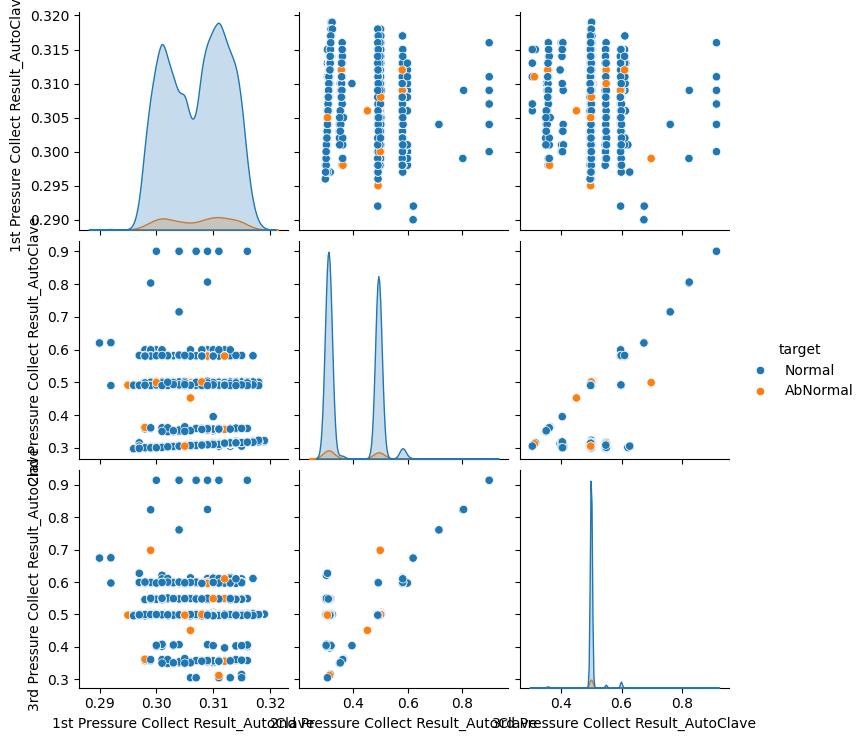

In [86]:
sns.pairplot(pressure_collect_result, hue = 'target')

### Pressure Unit Time_AutoClave 분석

In [94]:
pressure_unit_time = df_autoclave_cleaned[['1st Pressure 1st Pressure Unit Time_AutoClave','2nd Pressure Unit Time_AutoClave','3rd Pressure Unit Time_AutoClave','target']]
pressure_unit_time

,1st Pressure 1st Pressure Unit Time_AutoClave,2nd Pressure Unit Time_AutoClave,3rd Pressure Unit Time_AutoClave,target
0,240,1,120,Normal
1,241,121,121,Normal
2,241,1,121,Normal
3,241,121,121,Normal
4,240,120,120,Normal
...,...,...,...,...
40501,241,121,121,Normal
40502,240,1,120,Normal
40503,241,1,121,Normal
40504,241,121,121,Normal


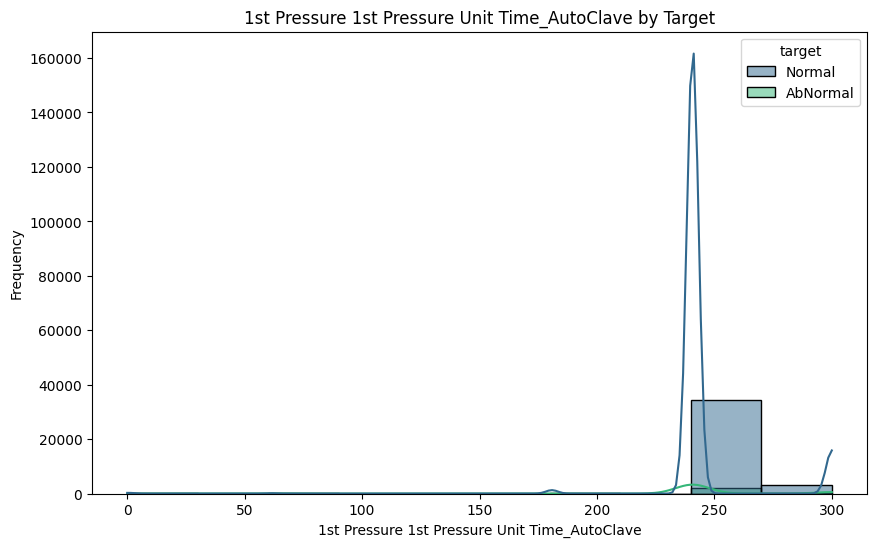

In [96]:
# 히스토그램 시각화
plt.figure(figsize=(10, 6))
sns.histplot(data=pressure_unit_time, x='1st Pressure 1st Pressure Unit Time_AutoClave', hue='target', bins=10, kde=True, palette='viridis')
plt.title('1st Pressure 1st Pressure Unit Time_AutoClave by Target')
plt.xlabel('1st Pressure 1st Pressure Unit Time_AutoClave')
plt.ylabel('Frequency')
plt.show()

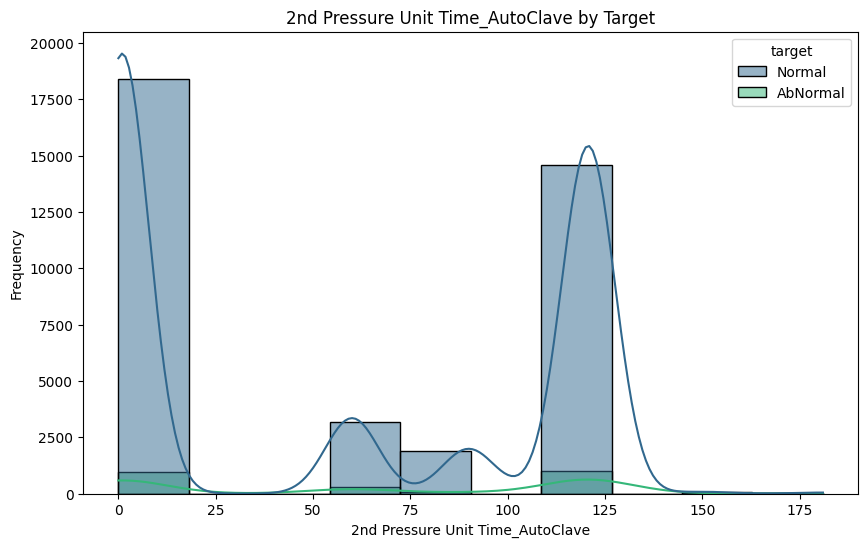

In [97]:
# 히스토그램 시각화
plt.figure(figsize=(10, 6))
sns.histplot(data=pressure_unit_time, x='2nd Pressure Unit Time_AutoClave', hue='target', bins=10, kde=True, palette='viridis')
plt.title('2nd Pressure Unit Time_AutoClave by Target')
plt.xlabel('2nd Pressure Unit Time_AutoClave')
plt.ylabel('Frequency')
plt.show()

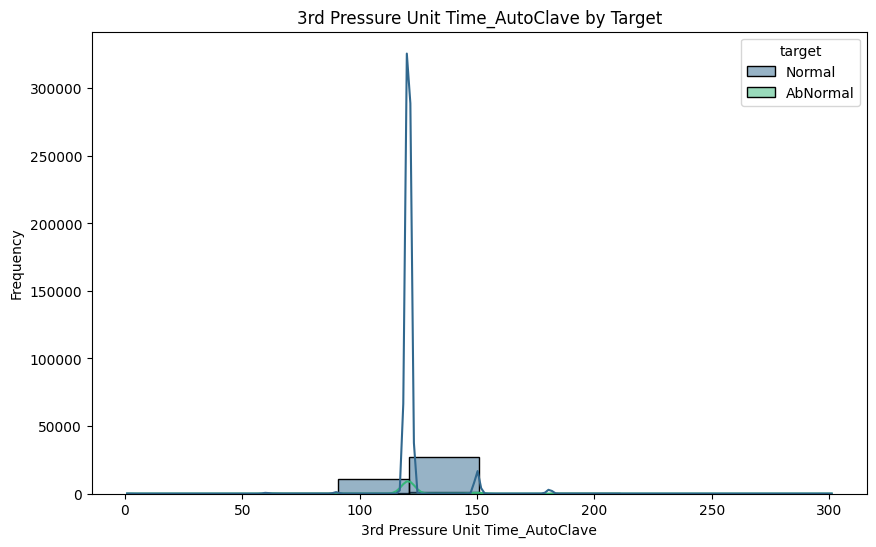

In [98]:
# 히스토그램 시각화
plt.figure(figsize=(10, 6))
sns.histplot(data=pressure_unit_time, x='3rd Pressure Unit Time_AutoClave', hue='target', bins=10, kde=True, palette='viridis')
plt.title('3rd Pressure Unit Time_AutoClave by Target')
plt.xlabel('3rd Pressure Unit Time_AutoClave')
plt.ylabel('Frequency')
plt.show()

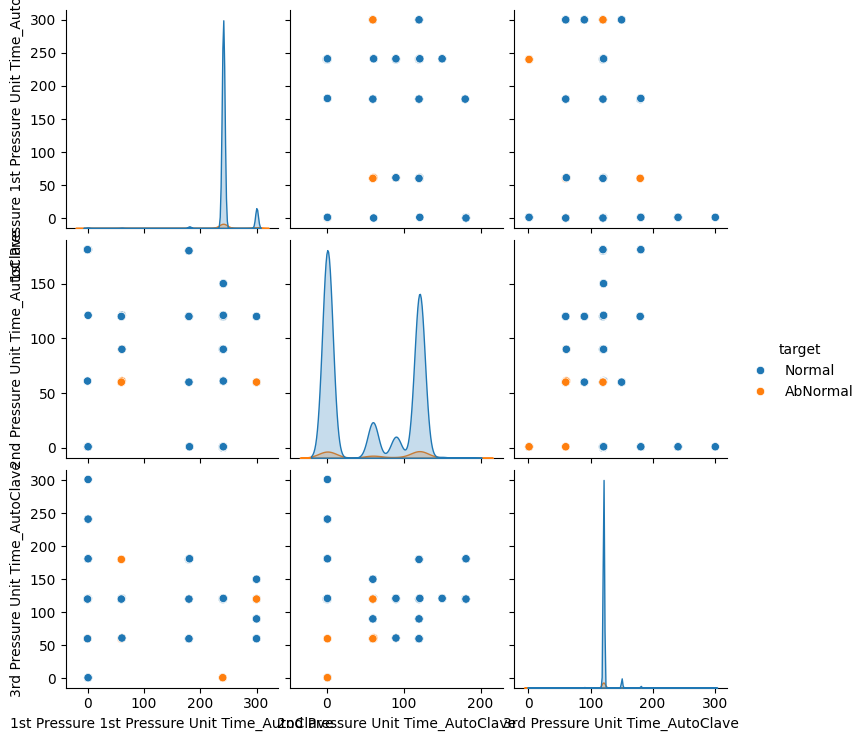

In [101]:
sns.pairplot(pressure_unit_time, hue = 'target')

### Chamber Temp. Collect Result_AutoClave , Chamber Temp. Unit Time_AutoClave, Chamber Temp. Judge Value_AutoClave 분석

방 온도?

In [100]:
chambertemp = df_autoclave_cleaned[['Chamber Temp. Collect Result_AutoClave','Chamber Temp. Unit Time_AutoClave','Chamber Temp. Judge Value_AutoClave','target']]
chambertemp

,Chamber Temp. Collect Result_AutoClave,Chamber Temp. Unit Time_AutoClave,Chamber Temp. Judge Value_AutoClave,target
0,54,361,OK,Normal
1,54,483,OK,Normal
2,56,363,OK,Normal
3,54,483,OK,Normal
4,47,480,NG,Normal
...,...,...,...,...
40501,54,483,OK,Normal
40502,49,361,NG,Normal
40503,48,363,NG,Normal
40504,54,483,OK,Normal


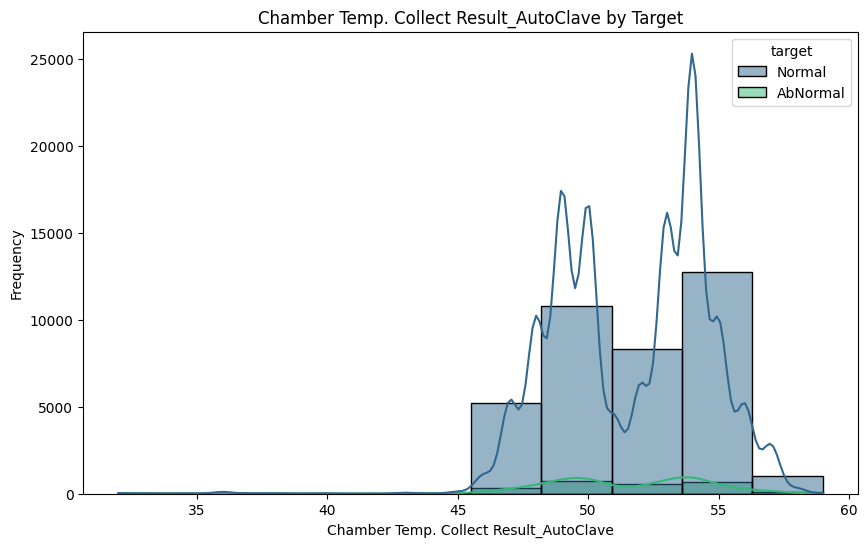

In [102]:
# 히스토그램 시각화
plt.figure(figsize=(10, 6))
sns.histplot(data=chambertemp, x='Chamber Temp. Collect Result_AutoClave', hue='target', bins=10, kde=True, palette='viridis')
plt.title('Chamber Temp. Collect Result_AutoClave by Target')
plt.xlabel('Chamber Temp. Collect Result_AutoClave')
plt.ylabel('Frequency')
plt.show()

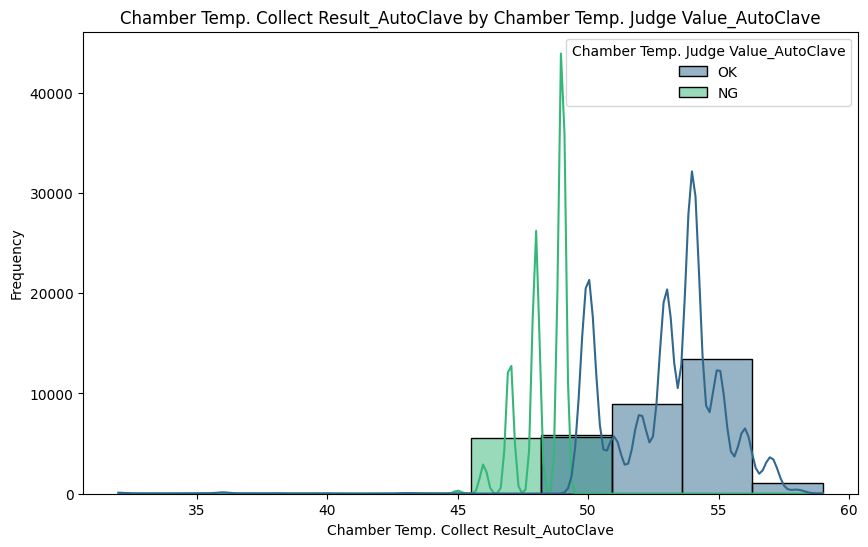

In [110]:
# 히스토그램 시각화
plt.figure(figsize=(10, 6))
sns.histplot(data=chambertemp, x='Chamber Temp. Collect Result_AutoClave', hue='Chamber Temp. Judge Value_AutoClave', bins=10, kde=True, palette='viridis')
plt.title('Chamber Temp. Collect Result_AutoClave by Chamber Temp. Judge Value_AutoClave')
plt.xlabel('Chamber Temp. Collect Result_AutoClave')
plt.ylabel('Frequency')
plt.show()

### `Chamber Temp. Judge Value 와 Chamber Temp. Collect Result의 관계에서 Chamber Temp.Judge Value_AutoClave 의 값이 NG인 데이터는  Chamber Temp. Collect Result의 값이 대체적으로 50보다 낮다.`

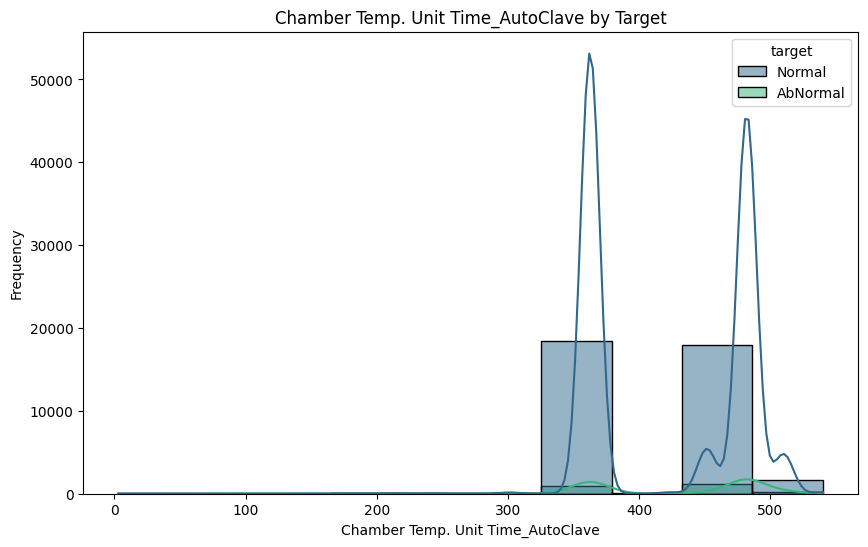

In [103]:
# 히스토그램 시각화
plt.figure(figsize=(10, 6))
sns.histplot(data=chambertemp, x='Chamber Temp. Unit Time_AutoClave', hue='target', bins=10, kde=True, palette='viridis')
plt.title('Chamber Temp. Unit Time_AutoClave by Target')
plt.xlabel('Chamber Temp. Unit Time_AutoClave')
plt.ylabel('Frequency')
plt.show()

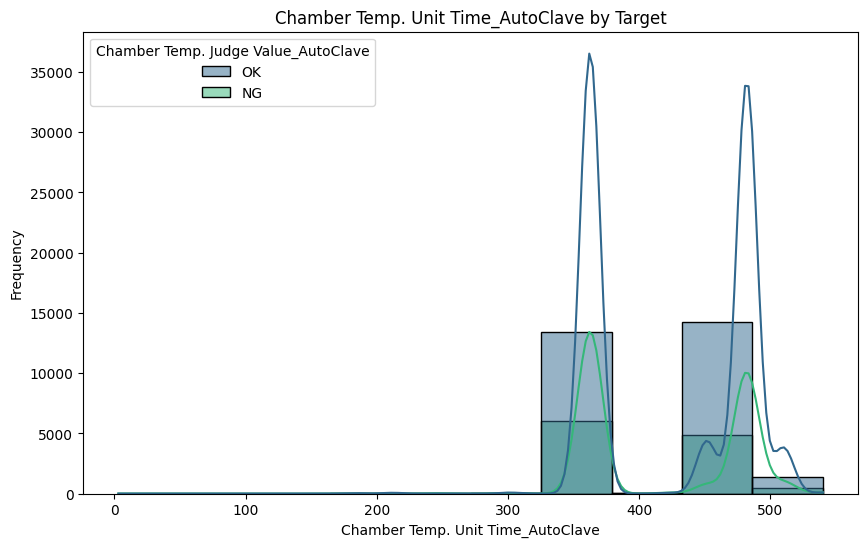

In [109]:
# 히스토그램 시각화
plt.figure(figsize=(10, 6))
sns.histplot(data=chambertemp, x='Chamber Temp. Unit Time_AutoClave', hue='Chamber Temp. Judge Value_AutoClave', bins=10, kde=True, palette='viridis')
plt.title('Chamber Temp. Unit Time_AutoClave by Target')
plt.xlabel('Chamber Temp. Unit Time_AutoClave')
plt.ylabel('Frequency')
plt.show()

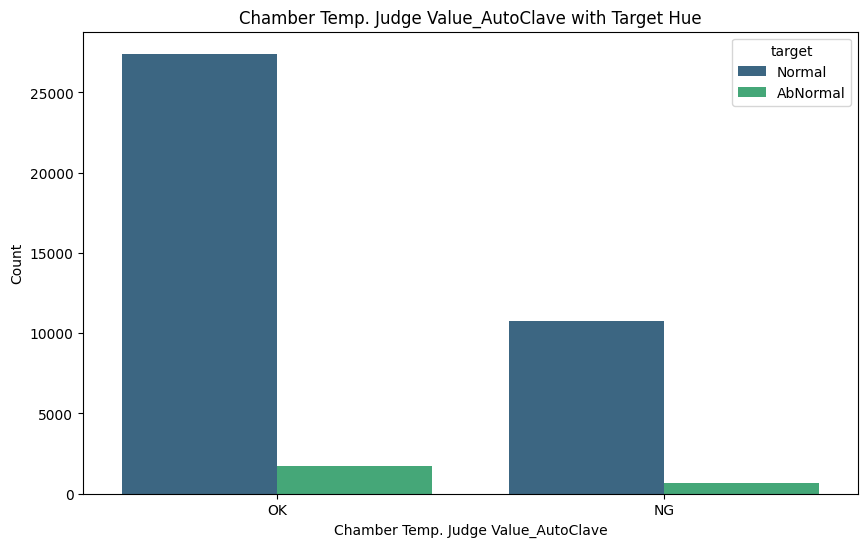

In [104]:
plt.figure(figsize=(10, 6))
sns.countplot(
    data=chambertemp,
    x='Chamber Temp. Judge Value_AutoClave',
    hue='target',
    palette='viridis'
)
plt.title('Chamber Temp. Judge Value_AutoClave with Target Hue')
plt.xlabel('Chamber Temp. Judge Value_AutoClave')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

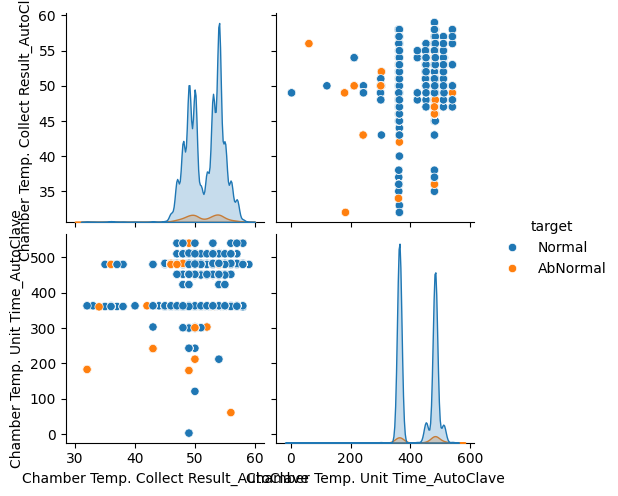

In [107]:
sns.pairplot(chambertemp, hue = 'target')

# 3. Fill 데이터 분석

In [18]:
df_fill1

,Wip Line_Fill1,Process Desc._Fill1,Equipment_Fill1,Model.Suffix_Fill1,Insp. Seq No._Fill1,Insp Judge Code_Fill1,DISCHARGED SPEED OF RESIN Collect Result_Fill1,DISCHARGED TIME OF RESIN(Stage1) Collect Result_Fill1,DISCHARGED TIME OF RESIN(Stage2) Collect Result_Fill1,DISCHARGED TIME OF RESIN(Stage3) Collect Result_Fill1,...,Head Clean Position Z Collect Result_Fill1,Head Purge Position X Collect Result_Fill1,Head Purge Position Y Collect Result_Fill1,Head Purge Position Z Collect Result_Fill1,Machine Tact time Collect Result_Fill1,PalletID Collect Result_Fill1,Production Qty Collect Result_Fill1,Receip No Collect Result_Fill1,WorkMode Collect Result_Fill1,target
0,IVI-OB6,Fill1 Dispenser,Fill1 dispenser #1,AJX75334505,1,OK,10.6,12.7,3.6,12.6,...,50.0,92.2,289,50,128.0,55.7,7,127,1,Normal
1,IVI-OB6,Fill1 Dispenser,Fill1 dispenser #1,AJX75334505,1,OK,10.6,13.5,3.6,13.5,...,92.2,289.0,50,145,56.5,7.0,185,1,7,Normal
2,IVI-OB6,Fill1 Dispenser,Fill1 dispenser #2,AJX75334501,1,OK,10.6,13.5,3.5,13.4,...,50.0,92.2,289,50,128.0,58.7,10,73,1,Normal
3,IVI-OB6,Fill1 Dispenser,Fill1 dispenser #2,AJX75334501,1,OK,10.6,13.5,3.6,13.5,...,92.2,289.0,50,145,57.7,12.0,268,1,7,Normal
4,IVI-OB6,Fill1 Dispenser,Fill1 dispenser #1,AJX75334501,1,OK,10.6,13.5,3.6,13.5,...,92.2,289.0,50,85,89.9,8.0,121,1,7,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40501,IVI-OB6,Fill1 Dispenser,Fill1 dispenser #1,AJX75334501,1,OK,10.6,13.5,3.6,13.5,...,92.2,289.0,50,145,51.8,1.0,318,1,7,Normal
40502,IVI-OB6,Fill1 Dispenser,Fill1 dispenser #2,AJX75334501,1,OK,10.6,13.5,3.6,13.5,...,50.0,92.2,289,50,128.0,58.7,14,197,1,Normal
40503,IVI-OB6,Fill1 Dispenser,Fill1 dispenser #1,AJX75334501,1,OK,10.6,12.9,3.6,12.9,...,50.0,92.2,289,50,128.0,56.2,1,27,1,Normal
40504,IVI-OB6,Fill1 Dispenser,Fill1 dispenser #2,AJX75334501,1,OK,10.6,13.5,3.6,13.4,...,92.2,289.0,50,145,57.4,13.0,117,1,7,Normal


In [19]:
list(df_fill1.columns) 

['Wip Line_Fill1',
 'Process Desc._Fill1',
 'Equipment_Fill1',
 'Model.Suffix_Fill1',
 'Insp. Seq No._Fill1',
 'Insp Judge Code_Fill1',
 'DISCHARGED SPEED OF RESIN Collect Result_Fill1',
 'DISCHARGED TIME OF RESIN(Stage1) Collect Result_Fill1',
 'DISCHARGED TIME OF RESIN(Stage2) Collect Result_Fill1',
 'DISCHARGED TIME OF RESIN(Stage3) Collect Result_Fill1',
 'Dispense Volume(Stage1) Collect Result_Fill1',
 'Dispense Volume(Stage2) Collect Result_Fill1',
 'Dispense Volume(Stage3) Collect Result_Fill1',
 'HEAD NORMAL COORDINATE X AXIS(Stage1) Collect Result_Fill1',
 'HEAD NORMAL COORDINATE X AXIS(Stage1) Judge Value_Fill1',
 'HEAD NORMAL COORDINATE X AXIS(Stage2) Collect Result_Fill1',
 'HEAD NORMAL COORDINATE X AXIS(Stage3) Collect Result_Fill1',
 'HEAD NORMAL COORDINATE Y AXIS(Stage1) Collect Result_Fill1',
 'HEAD NORMAL COORDINATE Y AXIS(Stage2) Collect Result_Fill1',
 'HEAD NORMAL COORDINATE Y AXIS(Stage3) Collect Result_Fill1',
 'HEAD NORMAL COORDINATE Z AXIS(Stage1) Collect Result

In [20]:
# unique 값이 1개인 열을 찾기
columns_with_unique_values_1 = [col for col in df_fill1.columns if df_fill1[col].nunique() == 1]
print('Unique 값이 1개')
for col in columns_with_unique_values_1:
    print(col)

Unique 값이 1개
Wip Line_Fill1
Process Desc._Fill1
Insp. Seq No._Fill1
Insp Judge Code_Fill1
HEAD NORMAL COORDINATE X AXIS(Stage1) Judge Value_Fill1


In [21]:
df_fill1_cleaned = df_fill1.drop(columns=columns_with_unique_values_1)

print("\n칼럼 제거 후 데이터프레임:")
df_fill1_cleaned


칼럼 제거 후 데이터프레임:


,Equipment_Fill1,Model.Suffix_Fill1,DISCHARGED SPEED OF RESIN Collect Result_Fill1,DISCHARGED TIME OF RESIN(Stage1) Collect Result_Fill1,DISCHARGED TIME OF RESIN(Stage2) Collect Result_Fill1,DISCHARGED TIME OF RESIN(Stage3) Collect Result_Fill1,Dispense Volume(Stage1) Collect Result_Fill1,Dispense Volume(Stage2) Collect Result_Fill1,Dispense Volume(Stage3) Collect Result_Fill1,HEAD NORMAL COORDINATE X AXIS(Stage1) Collect Result_Fill1,...,Head Clean Position Z Collect Result_Fill1,Head Purge Position X Collect Result_Fill1,Head Purge Position Y Collect Result_Fill1,Head Purge Position Z Collect Result_Fill1,Machine Tact time Collect Result_Fill1,PalletID Collect Result_Fill1,Production Qty Collect Result_Fill1,Receip No Collect Result_Fill1,WorkMode Collect Result_Fill1,target
0,Fill1 dispenser #1,AJX75334505,10.6,12.7,3.6,12.6,12.06,3.42,11.97,NaN,...,50.0,92.2,289,50,128.0,55.7,7,127,1,Normal
1,Fill1 dispenser #1,AJX75334505,10.6,13.5,3.6,13.5,12.82,3.42,12.82,838.4,...,92.2,289.0,50,145,56.5,7.0,185,1,7,Normal
2,Fill1 dispenser #2,AJX75334501,10.6,13.5,3.5,13.4,12.82,3.32,12.73,OK,...,50.0,92.2,289,50,128.0,58.7,10,73,1,Normal
3,Fill1 dispenser #2,AJX75334501,10.6,13.5,3.6,13.5,12.82,3.42,12.82,837.7,...,92.2,289.0,50,145,57.7,12.0,268,1,7,Normal
4,Fill1 dispenser #1,AJX75334501,10.6,13.5,3.6,13.5,12.82,3.42,12.82,838.4,...,92.2,289.0,50,85,89.9,8.0,121,1,7,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40501,Fill1 dispenser #1,AJX75334501,10.6,13.5,3.6,13.5,12.82,3.42,12.82,838.4,...,92.2,289.0,50,145,51.8,1.0,318,1,7,Normal
40502,Fill1 dispenser #2,AJX75334501,10.6,13.5,3.6,13.5,12.82,3.42,12.82,NaN,...,50.0,92.2,289,50,128.0,58.7,14,197,1,Normal
40503,Fill1 dispenser #1,AJX75334501,10.6,12.9,3.6,12.9,12.25,3.42,12.25,OK,...,50.0,92.2,289,50,128.0,56.2,1,27,1,Normal
40504,Fill1 dispenser #2,AJX75334501,10.6,13.5,3.6,13.4,12.82,3.42,12.73,837.7,...,92.2,289.0,50,145,57.4,13.0,117,1,7,Normal


In [22]:
list(df_fill1_cleaned.columns) 

['Equipment_Fill1',
 'Model.Suffix_Fill1',
 'DISCHARGED SPEED OF RESIN Collect Result_Fill1',
 'DISCHARGED TIME OF RESIN(Stage1) Collect Result_Fill1',
 'DISCHARGED TIME OF RESIN(Stage2) Collect Result_Fill1',
 'DISCHARGED TIME OF RESIN(Stage3) Collect Result_Fill1',
 'Dispense Volume(Stage1) Collect Result_Fill1',
 'Dispense Volume(Stage2) Collect Result_Fill1',
 'Dispense Volume(Stage3) Collect Result_Fill1',
 'HEAD NORMAL COORDINATE X AXIS(Stage1) Collect Result_Fill1',
 'HEAD NORMAL COORDINATE X AXIS(Stage2) Collect Result_Fill1',
 'HEAD NORMAL COORDINATE X AXIS(Stage3) Collect Result_Fill1',
 'HEAD NORMAL COORDINATE Y AXIS(Stage1) Collect Result_Fill1',
 'HEAD NORMAL COORDINATE Y AXIS(Stage2) Collect Result_Fill1',
 'HEAD NORMAL COORDINATE Y AXIS(Stage3) Collect Result_Fill1',
 'HEAD NORMAL COORDINATE Z AXIS(Stage1) Collect Result_Fill1',
 'HEAD NORMAL COORDINATE Z AXIS(Stage2) Collect Result_Fill1',
 'HEAD NORMAL COORDINATE Z AXIS(Stage3) Collect Result_Fill1',
 'HEAD Standby Pos

In [23]:
for column in df_fill1_cleaned.columns:
    unique_values = df_fill1_cleaned[column].unique()
    print(f'Column: {column}')
    print(f'Unique values: {unique_values}')
    print
    

Column: Equipment_Fill1
Unique values: ['Fill1 dispenser #1' 'Fill1 dispenser #2']
Column: Model.Suffix_Fill1
Unique values: ['AJX75334505' 'AJX75334501' 'AJX75334502' 'AJX75334507' 'AJX75334506'
 'AJX75334508' 'AJX75334503']
Column: DISCHARGED SPEED OF RESIN Collect Result_Fill1
Unique values: [10.6 10.9  8.   0. ]
Column: DISCHARGED TIME OF RESIN(Stage1) Collect Result_Fill1
Unique values: [12.7 13.5 12.9 13.4 13.6 13.3 12.8 13.2 14.8  4.  14.7 17.3 17.4  3.9
 12.6  0. ]
Column: DISCHARGED TIME OF RESIN(Stage2) Collect Result_Fill1
Unique values: [ 3.6  3.5  5.   3.9  4.9  4.   4.6  3.8  4.1  4.2 14.7  3.7  4.8  4.4
  5.1  4.7  4.3  3.2  5.2 14.8  3.4  4.5  3.3  0. ]
Column: DISCHARGED TIME OF RESIN(Stage3) Collect Result_Fill1
Unique values: [12.6 13.5 13.4 12.9 13.6 13.3 13.2 12.8 14.8 14.7 12.7 17.3 17.4 13.
 13.1  0. ]
Column: Dispense Volume(Stage1) Collect Result_Fill1
Unique values: [12.06 12.82 12.25 12.73 12.92 12.63 12.16 12.54 14.06  3.8  13.96 12.45
 12.52  3.7  11.97  0.

### Equipment, Model.Shufix
'Equipment_Fill1',

'Model.Suffix_Fill1',

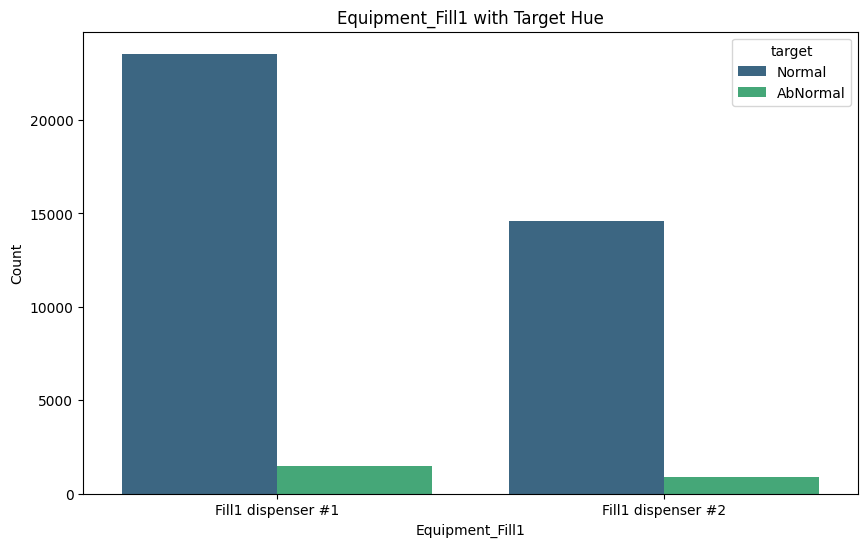

In [23]:
plt.figure(figsize=(10, 6))
sns.countplot(
    data=df_fill1_cleaned,
    x='Equipment_Fill1',
    hue='target',
    palette='viridis'
)
plt.title('Equipment_Fill1 with Target Hue')
plt.xlabel('Equipment_Fill1')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

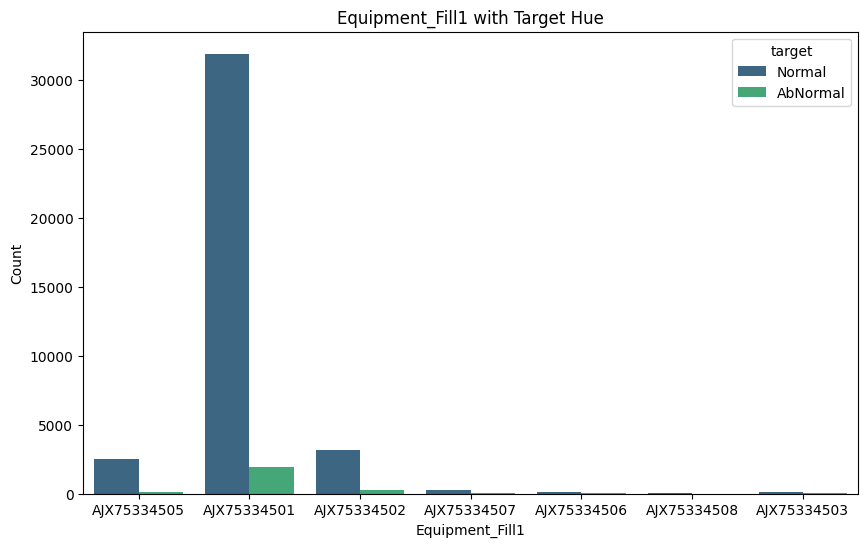

In [24]:
plt.figure(figsize=(10, 6))
sns.countplot(
    data=df_fill1_cleaned,
    x='Model.Suffix_Fill1',
    hue='target',
    palette='viridis'
)
plt.title('Equipment_Fill1 with Target Hue')
plt.xlabel('Equipment_Fill1')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

### DISCHARGED SPEED AND TIME OF RESIN
'DISCHARGED SPEED OF RESIN Collect Result_Fill1',

'DISCHARGED TIME OF RESIN(Stage1) Collect Result_Fill1',

'DISCHARGED TIME OF RESIN(Stage2) Collect Result_Fill1',

'DISCHARGED TIME OF RESIN(Stage3) Collect Result_Fill1',

In [25]:
discharged_speed_time_df = df_fill1_cleaned[[
    'DISCHARGED SPEED OF RESIN Collect Result_Fill1',
    'DISCHARGED TIME OF RESIN(Stage1) Collect Result_Fill1',
    'DISCHARGED TIME OF RESIN(Stage2) Collect Result_Fill1',
    'DISCHARGED TIME OF RESIN(Stage3) Collect Result_Fill1',
    'target'
    ]
]
discharged_speed_time_df 

,DISCHARGED SPEED OF RESIN Collect Result_Fill1,DISCHARGED TIME OF RESIN(Stage1) Collect Result_Fill1,DISCHARGED TIME OF RESIN(Stage2) Collect Result_Fill1,DISCHARGED TIME OF RESIN(Stage3) Collect Result_Fill1,target
0,10.6,12.7,3.6,12.6,Normal
1,10.6,13.5,3.6,13.5,Normal
2,10.6,13.5,3.5,13.4,Normal
3,10.6,13.5,3.6,13.5,Normal
4,10.6,13.5,3.6,13.5,Normal
...,...,...,...,...,...
40501,10.6,13.5,3.6,13.5,Normal
40502,10.6,13.5,3.6,13.5,Normal
40503,10.6,12.9,3.6,12.9,Normal
40504,10.6,13.5,3.6,13.4,Normal


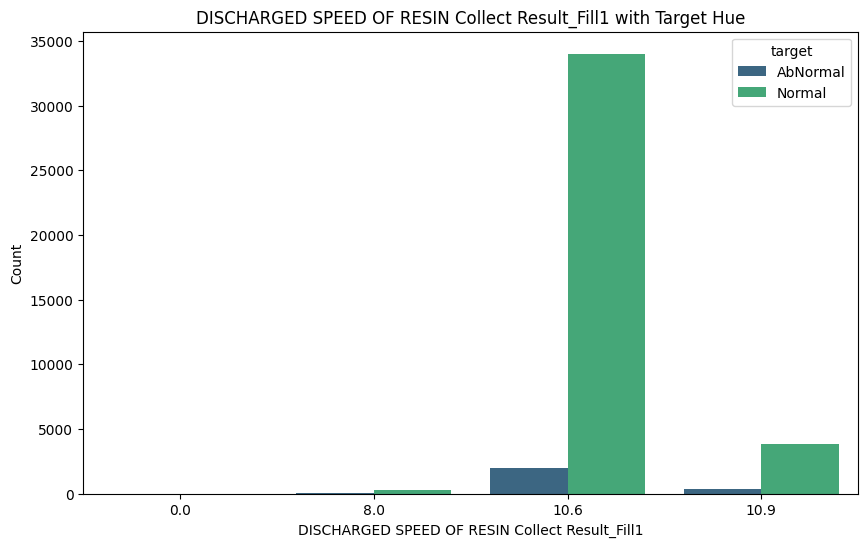

In [28]:
plt.figure(figsize=(10, 6))
sns.countplot(
    data=discharged_speed_time_df,
    x='DISCHARGED SPEED OF RESIN Collect Result_Fill1',
    hue='target',
    palette='viridis'
)
plt.title('DISCHARGED SPEED OF RESIN Collect Result_Fill1 with Target Hue')
plt.xlabel('DISCHARGED SPEED OF RESIN Collect Result_Fill1')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

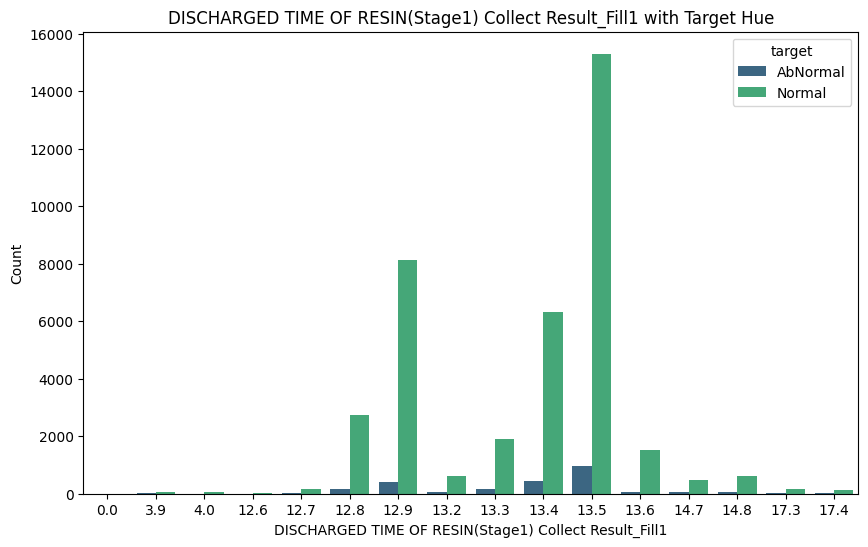

In [29]:
plt.figure(figsize=(10, 6))
sns.countplot(
    data=discharged_speed_time_df,
    x='DISCHARGED TIME OF RESIN(Stage1) Collect Result_Fill1',
    hue='target',
    palette='viridis'
)
plt.title('DISCHARGED TIME OF RESIN(Stage1) Collect Result_Fill1 with Target Hue')
plt.xlabel('DISCHARGED TIME OF RESIN(Stage1) Collect Result_Fill1')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

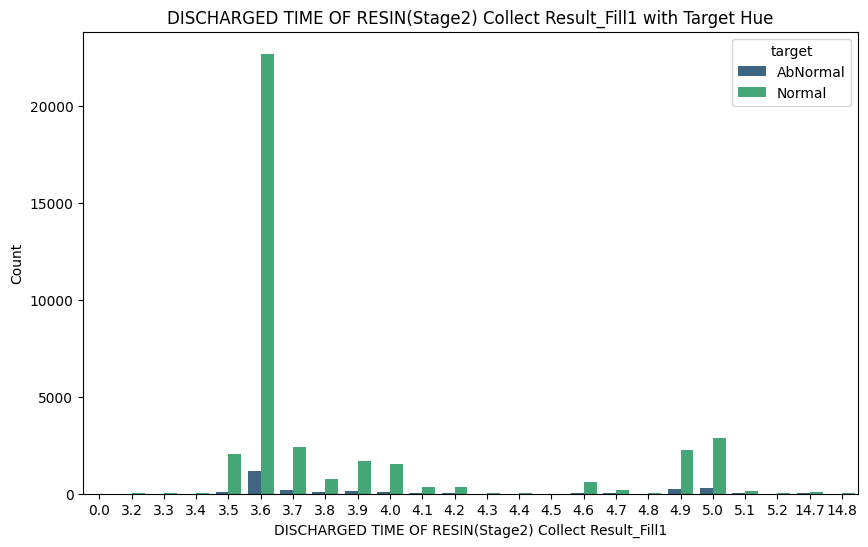

In [30]:
plt.figure(figsize=(10, 6))
sns.countplot(
    data=discharged_speed_time_df,
    x='DISCHARGED TIME OF RESIN(Stage2) Collect Result_Fill1',
    hue='target',
    palette='viridis'
)
plt.title('DISCHARGED TIME OF RESIN(Stage2) Collect Result_Fill1 with Target Hue')
plt.xlabel('DISCHARGED TIME OF RESIN(Stage2) Collect Result_Fill1')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

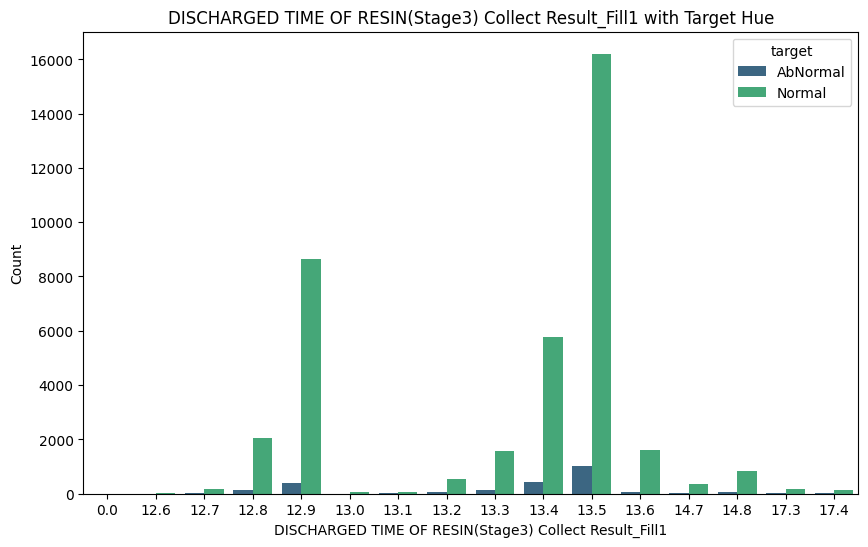

In [31]:
plt.figure(figsize=(10, 6))
sns.countplot(
    data=discharged_speed_time_df,
    x='DISCHARGED TIME OF RESIN(Stage3) Collect Result_Fill1',
    hue='target',
    palette='viridis'
)
plt.title('DISCHARGED TIME OF RESIN(Stage3) Collect Result_Fill1 with Target Hue')
plt.xlabel('DISCHARGED TIME OF RESIN(Stage3) Collect Result_Fill1')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

### Dispense volume
'Dispense Volume(Stage1) Collect Result_Fill1',

'Dispense Volume(Stage2) Collect Result_Fill1',
 
'Dispense Volume(Stage3) Collect Result_Fill1',

In [33]:
discharged_volume_df = df_fill1_cleaned[[
    'Dispense Volume(Stage1) Collect Result_Fill1',
    'Dispense Volume(Stage2) Collect Result_Fill1',
    'Dispense Volume(Stage3) Collect Result_Fill1',
    'target'
    ]
]
discharged_volume_df

,Dispense Volume(Stage1) Collect Result_Fill1,Dispense Volume(Stage2) Collect Result_Fill1,Dispense Volume(Stage3) Collect Result_Fill1,target
0,12.06,3.42,11.97,Normal
1,12.82,3.42,12.82,Normal
2,12.82,3.32,12.73,Normal
3,12.82,3.42,12.82,Normal
4,12.82,3.42,12.82,Normal
...,...,...,...,...
40501,12.82,3.42,12.82,Normal
40502,12.82,3.42,12.82,Normal
40503,12.25,3.42,12.25,Normal
40504,12.82,3.42,12.73,Normal


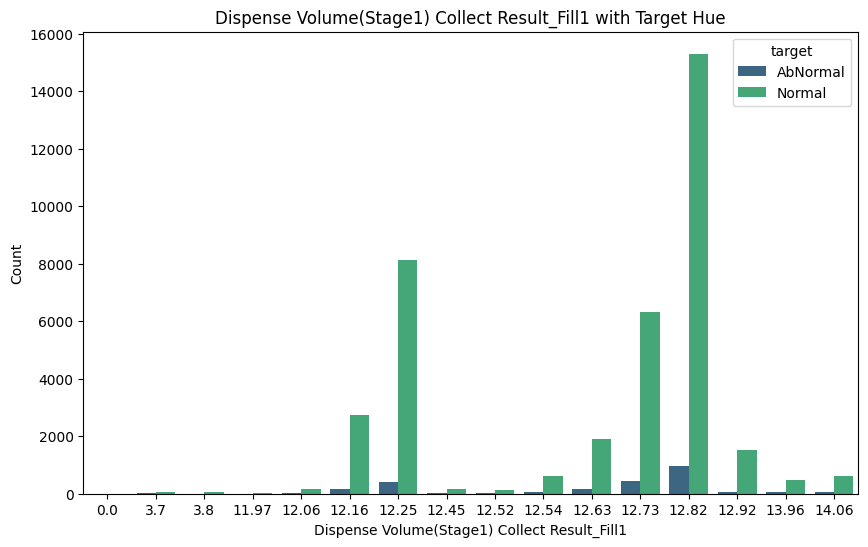

In [34]:
plt.figure(figsize=(10, 6))
sns.countplot(
    data=discharged_volume_df,
    x='Dispense Volume(Stage1) Collect Result_Fill1',
    hue='target',
    palette='viridis'
)
plt.title('Dispense Volume(Stage1) Collect Result_Fill1 with Target Hue')
plt.xlabel('Dispense Volume(Stage1) Collect Result_Fill1')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

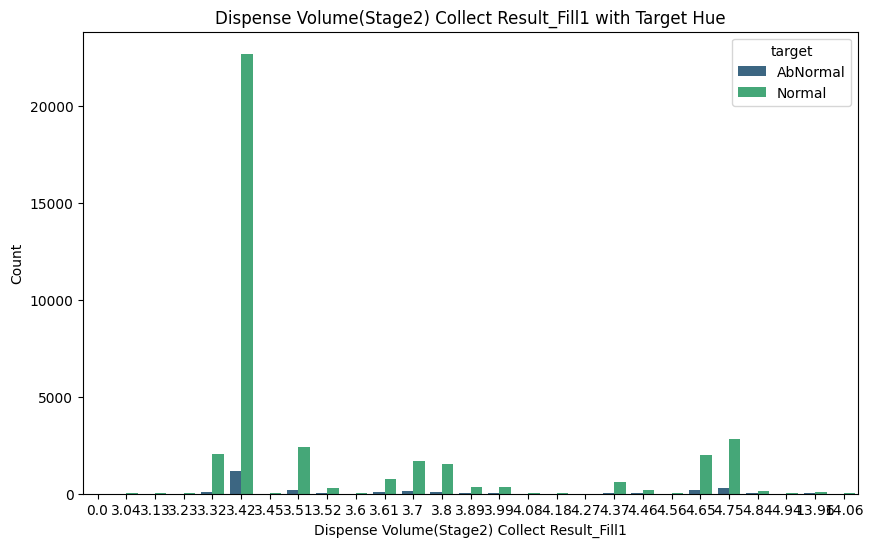

In [35]:
plt.figure(figsize=(10, 6))
sns.countplot(
    data=discharged_volume_df,
    x='Dispense Volume(Stage2) Collect Result_Fill1',
    hue='target',
    palette='viridis'
)
plt.title('Dispense Volume(Stage2) Collect Result_Fill1 with Target Hue')
plt.xlabel('Dispense Volume(Stage2) Collect Result_Fill1')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

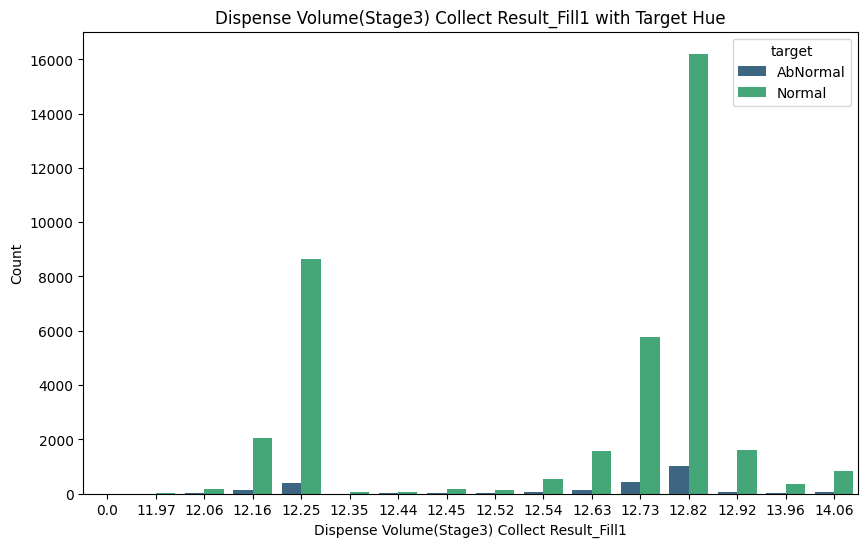

In [36]:
plt.figure(figsize=(10, 6))
sns.countplot(
    data=discharged_volume_df,
    x='Dispense Volume(Stage3) Collect Result_Fill1',
    hue='target',
    palette='viridis'
)
plt.title('Dispense Volume(Stage3) Collect Result_Fill1 with Target Hue')
plt.xlabel('Dispense Volume(Stage3) Collect Result_Fill1')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

### HEAD NORMAL COORDINATE AXIS
'HEAD NORMAL COORDINATE X AXIS(Stage1) Collect Result_Fill1',

'HEAD NORMAL COORDINATE X AXIS(Stage2) Collect Result_Fill1',

'HEAD NORMAL COORDINATE X AXIS(Stage3) Collect Result_Fill1',

'HEAD NORMAL COORDINATE Y AXIS(Stage1) Collect Result_Fill1',

'HEAD NORMAL COORDINATE Y AXIS(Stage2) Collect Result_Fill1',

'HEAD NORMAL COORDINATE Y AXIS(Stage3) Collect Result_Fill1',

'HEAD NORMAL COORDINATE Z AXIS(Stage1) Collect Result_Fill1',

'HEAD NORMAL COORDINATE Z AXIS(Stage2) Collect Result_Fill1',

'HEAD NORMAL COORDINATE Z AXIS(Stage3) Collect Result_Fill1',

In [37]:
head_normal_coordinate_axis_df = df_fill1_cleaned[[
    'HEAD NORMAL COORDINATE X AXIS(Stage1) Collect Result_Fill1',
    'HEAD NORMAL COORDINATE X AXIS(Stage2) Collect Result_Fill1',
    'HEAD NORMAL COORDINATE X AXIS(Stage3) Collect Result_Fill1',
    'HEAD NORMAL COORDINATE Y AXIS(Stage1) Collect Result_Fill1',
    'HEAD NORMAL COORDINATE Y AXIS(Stage2) Collect Result_Fill1',
    'HEAD NORMAL COORDINATE Y AXIS(Stage3) Collect Result_Fill1',
    'HEAD NORMAL COORDINATE Z AXIS(Stage1) Collect Result_Fill1',
    'HEAD NORMAL COORDINATE Z AXIS(Stage2) Collect Result_Fill1',
    'HEAD NORMAL COORDINATE Z AXIS(Stage3) Collect Result_Fill1',
    'target'
    ]
]
head_normal_coordinate_axis_df

,HEAD NORMAL COORDINATE X AXIS(Stage1) Collect Result_Fill1,HEAD NORMAL COORDINATE X AXIS(Stage2) Collect Result_Fill1,HEAD NORMAL COORDINATE X AXIS(Stage3) Collect Result_Fill1,HEAD NORMAL COORDINATE Y AXIS(Stage1) Collect Result_Fill1,HEAD NORMAL COORDINATE Y AXIS(Stage2) Collect Result_Fill1,HEAD NORMAL COORDINATE Y AXIS(Stage3) Collect Result_Fill1,HEAD NORMAL COORDINATE Z AXIS(Stage1) Collect Result_Fill1,HEAD NORMAL COORDINATE Z AXIS(Stage2) Collect Result_Fill1,HEAD NORMAL COORDINATE Z AXIS(Stage3) Collect Result_Fill1,target
0,NaN,838.4,458.7,157.0,430.0,429.8,430.3,244.520,244.520,Normal
1,838.4,458.5,157.0,430.5,430.5,430.8,244.4,244.400,244.400,Normal
2,OK,837.9,458.1,156.1,1323.5,1322.5,1323.1,244.415,244.415,Normal
3,837.7,458.8,157.0,1323.2,1322.5,1322.8,244.3,244.300,244.300,Normal
4,838.4,458.5,157.0,430.2,430.5,430.5,244.4,244.400,244.400,Normal
...,...,...,...,...,...,...,...,...,...,...
40501,838.4,458.5,157.0,430.5,430.5,430.8,244.4,244.400,244.400,Normal
40502,NaN,838.1,458.7,156.1,1325.0,1324.0,1324.3,244.535,244.535,Normal
40503,OK,838.4,458.4,157.0,430.8,430.5,431.1,244.543,244.543,Normal
40504,837.7,458.8,157.0,1323.2,1323.0,1322.8,244.4,244.400,244.400,Normal


In [39]:
# 'HEAD NORMAL COORDINATE X AXIS(Stage1) Collect Result_Dam' 칼럼의 NaN 데이터 개수 계산
nan_count = head_normal_coordinate_axis_df['HEAD NORMAL COORDINATE X AXIS(Stage1) Collect Result_Fill1'].isna().sum()

# 결과 출력
print(f"'HEAD NORMAL COORDINATE X AXIS(Stage1) Collect Result_Fill1' 칼럼의 NaN 데이터 개수: {nan_count}")

'HEAD NORMAL COORDINATE X AXIS(Stage1) Collect Result_Fill1' 칼럼의 NaN 데이터 개수: 12766


In [42]:
head_coordinate_axis_stage1_x = head_normal_coordinate_axis_df[[
    'HEAD NORMAL COORDINATE X AXIS(Stage1) Collect Result_Fill1',
    'target']
]
head_coordinate_axis_stage1_x =  head_coordinate_axis_stage1_x.dropna(subset=['HEAD NORMAL COORDINATE X AXIS(Stage1) Collect Result_Fill1'])
head_coordinate_axis_stage1_x

,HEAD NORMAL COORDINATE X AXIS(Stage1) Collect Result_Fill1,target
1,838.4,Normal
2,OK,Normal
3,837.7,Normal
4,838.4,Normal
5,837.9,Normal
...,...,...
40499,OK,Normal
40501,838.4,Normal
40503,OK,Normal
40504,837.7,Normal


In [43]:
head_coordinate_axis_stage1_x = head_coordinate_axis_stage1_x[head_coordinate_axis_stage1_x['HEAD NORMAL COORDINATE X AXIS(Stage1) Collect Result_Fill1'] != 'OK']
head_coordinate_axis_stage1_x

,HEAD NORMAL COORDINATE X AXIS(Stage1) Collect Result_Fill1,target
1,838.4,Normal
3,837.7,Normal
4,838.4,Normal
5,837.9,Normal
8,838.4,Normal
...,...,...
40497,838.4,Normal
40498,838.4,Normal
40501,838.4,Normal
40504,837.7,Normal


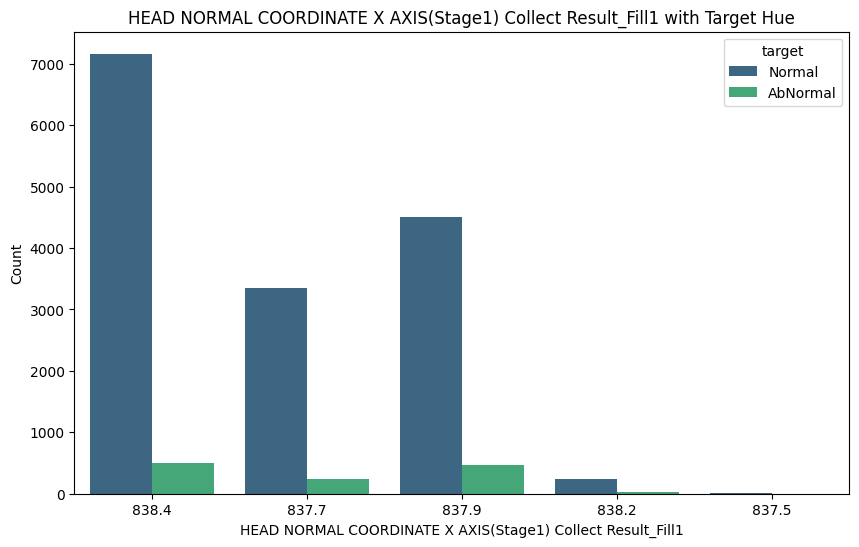

In [45]:
plt.figure(figsize=(10, 6))
sns.countplot(
    data=head_coordinate_axis_stage1_x,
    x='HEAD NORMAL COORDINATE X AXIS(Stage1) Collect Result_Fill1',
    hue='target',
    palette='viridis'
)
plt.title('HEAD NORMAL COORDINATE X AXIS(Stage1) Collect Result_Fill1 with Target Hue')
plt.xlabel('HEAD NORMAL COORDINATE X AXIS(Stage1) Collect Result_Fill1')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

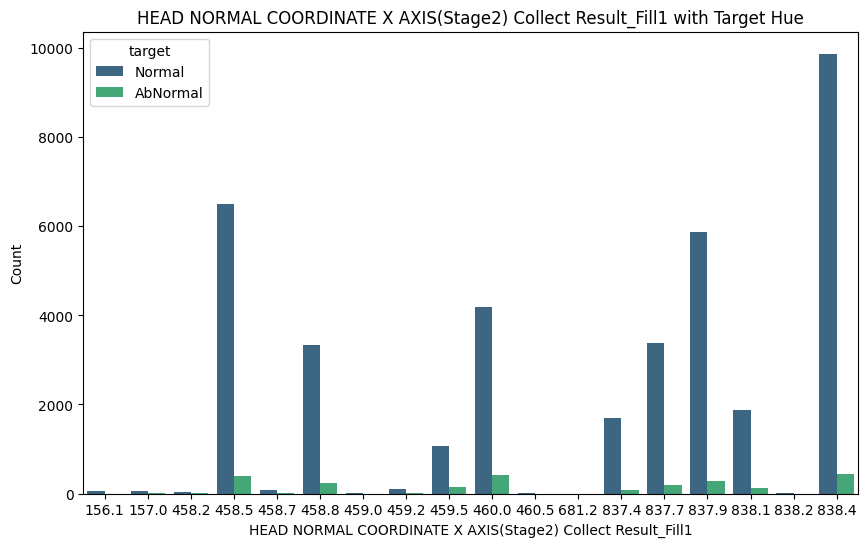

In [46]:
plt.figure(figsize=(10, 6))
sns.countplot(
    data=head_normal_coordinate_axis_df,
    x='HEAD NORMAL COORDINATE X AXIS(Stage2) Collect Result_Fill1',
    hue='target',
    palette='viridis'
)
plt.title('HEAD NORMAL COORDINATE X AXIS(Stage2) Collect Result_Fill1 with Target Hue')
plt.xlabel('HEAD NORMAL COORDINATE X AXIS(Stage2) Collect Result_Fill1')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

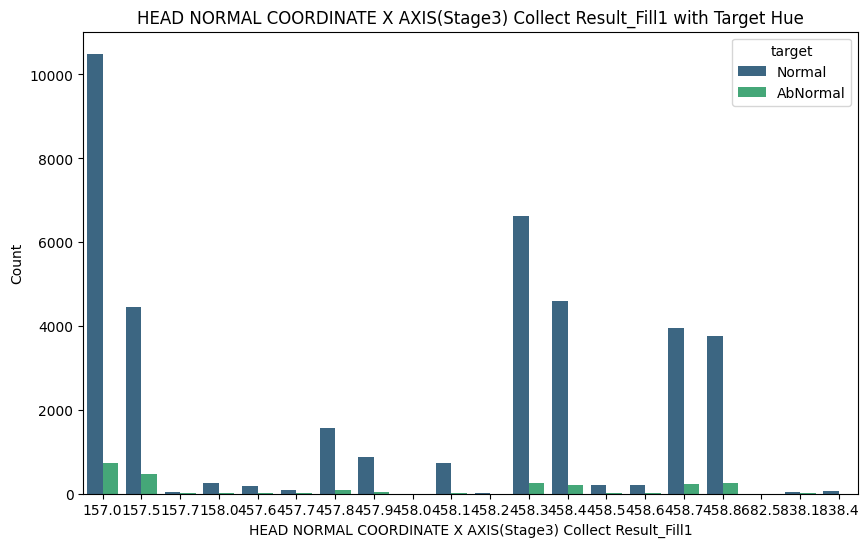

In [47]:
plt.figure(figsize=(10, 6))
sns.countplot(
    data=head_normal_coordinate_axis_df,
    x='HEAD NORMAL COORDINATE X AXIS(Stage3) Collect Result_Fill1',
    hue='target',
    palette='viridis'
)
plt.title('HEAD NORMAL COORDINATE X AXIS(Stage3) Collect Result_Fill1 with Target Hue')
plt.xlabel('HEAD NORMAL COORDINATE X AXIS(Stage3) Collect Result_Fill1')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

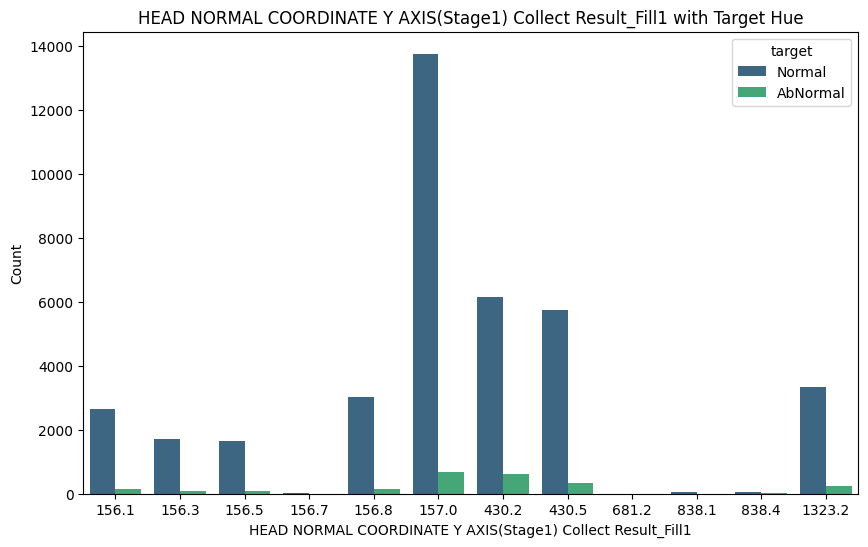

In [48]:
plt.figure(figsize=(10, 6))
sns.countplot(
    data=head_normal_coordinate_axis_df,
    x='HEAD NORMAL COORDINATE Y AXIS(Stage1) Collect Result_Fill1',
    hue='target',
    palette='viridis'
)
plt.title('HEAD NORMAL COORDINATE Y AXIS(Stage1) Collect Result_Fill1 with Target Hue')
plt.xlabel('HEAD NORMAL COORDINATE Y AXIS(Stage1) Collect Result_Fill1')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

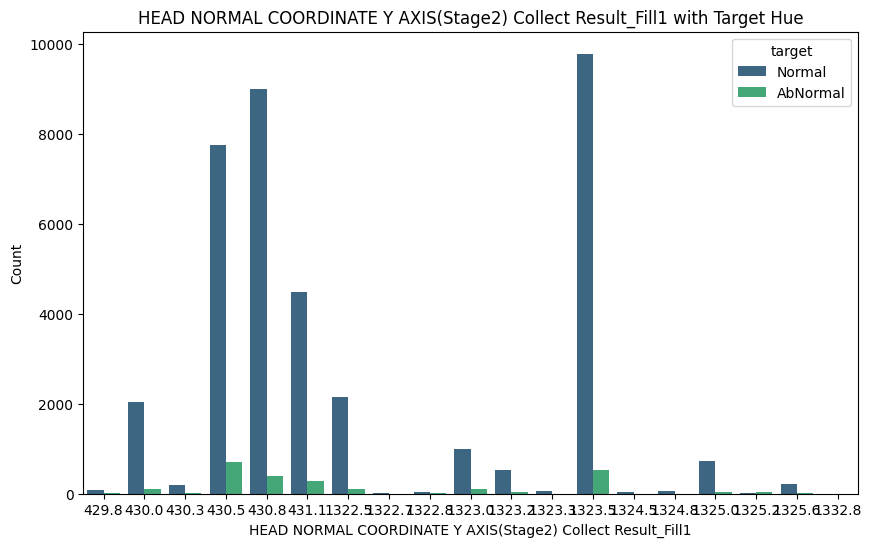

In [49]:
plt.figure(figsize=(10, 6))
sns.countplot(
    data=head_normal_coordinate_axis_df,
    x='HEAD NORMAL COORDINATE Y AXIS(Stage2) Collect Result_Fill1',
    hue='target',
    palette='viridis'
)
plt.title('HEAD NORMAL COORDINATE Y AXIS(Stage2) Collect Result_Fill1 with Target Hue')
plt.xlabel('HEAD NORMAL COORDINATE Y AXIS(Stage2) Collect Result_Fill1')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

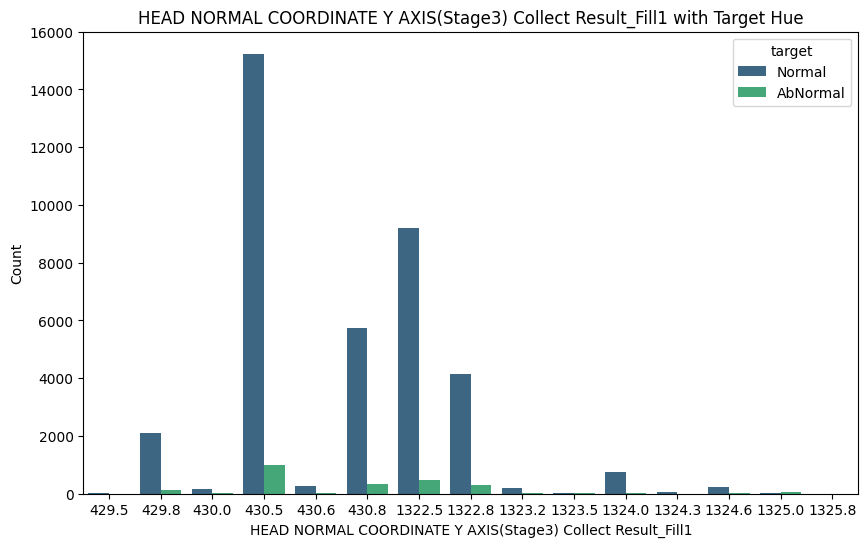

In [50]:
plt.figure(figsize=(10, 6))
sns.countplot(
    data=head_normal_coordinate_axis_df,
    x='HEAD NORMAL COORDINATE Y AXIS(Stage3) Collect Result_Fill1',
    hue='target',
    palette='viridis'
)
plt.title('HEAD NORMAL COORDINATE Y AXIS(Stage3) Collect Result_Fill1 with Target Hue')
plt.xlabel('HEAD NORMAL COORDINATE Y AXIS(Stage3) Collect Result_Fill1')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

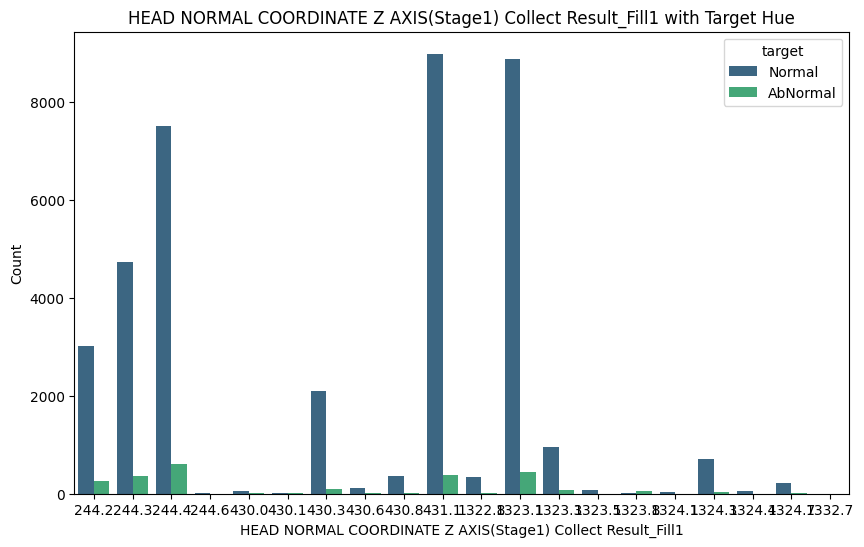

In [51]:
plt.figure(figsize=(10, 6))
sns.countplot(
    data=head_normal_coordinate_axis_df,
    x='HEAD NORMAL COORDINATE Z AXIS(Stage1) Collect Result_Fill1',
    hue='target',
    palette='viridis'
)
plt.title('HEAD NORMAL COORDINATE Z AXIS(Stage1) Collect Result_Fill1 with Target Hue')
plt.xlabel('HEAD NORMAL COORDINATE Z AXIS(Stage1) Collect Result_Fill1')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

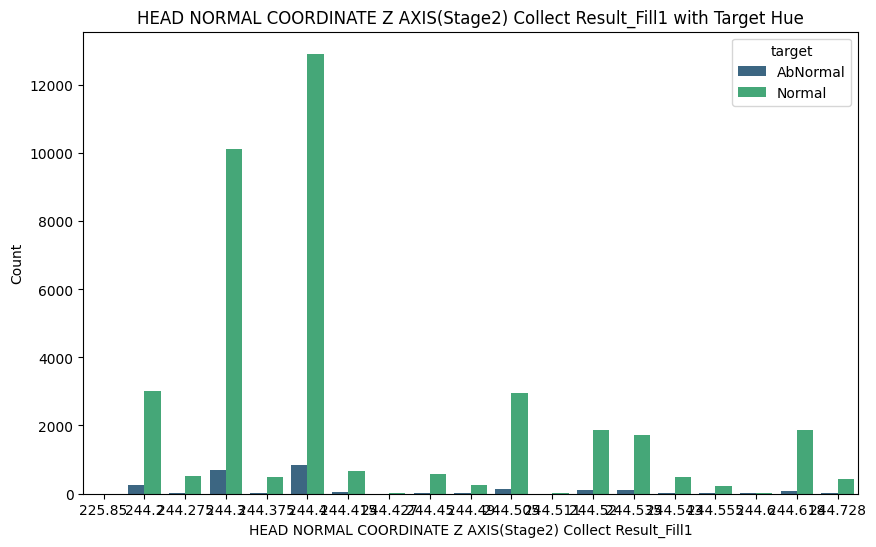

In [52]:
plt.figure(figsize=(10, 6))
sns.countplot(
    data=head_normal_coordinate_axis_df,
    x='HEAD NORMAL COORDINATE Z AXIS(Stage2) Collect Result_Fill1',
    hue='target',
    palette='viridis'
)
plt.title('HEAD NORMAL COORDINATE Z AXIS(Stage2) Collect Result_Fill1 with Target Hue')
plt.xlabel('HEAD NORMAL COORDINATE Z AXIS(Stage2) Collect Result_Fill1')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

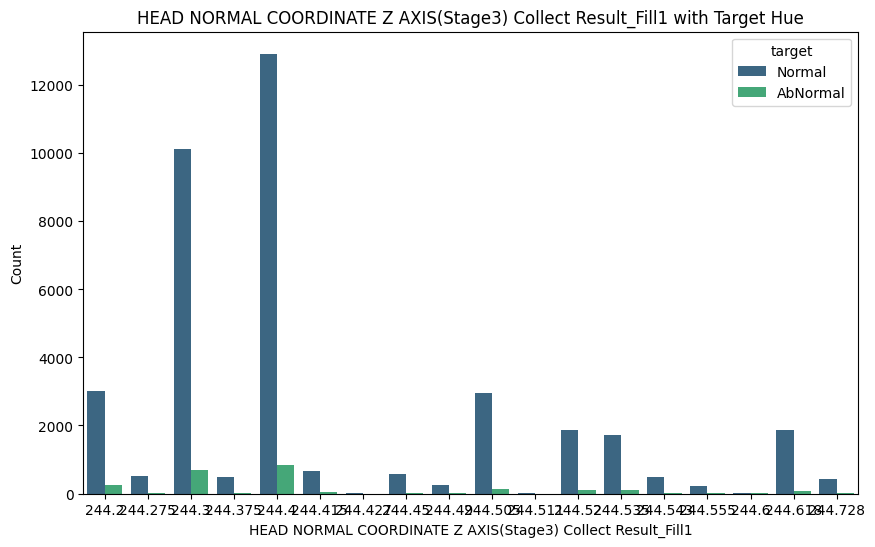

In [53]:
plt.figure(figsize=(10, 6))
sns.countplot(
    data=head_normal_coordinate_axis_df,
    x='HEAD NORMAL COORDINATE Z AXIS(Stage3) Collect Result_Fill1',
    hue='target',
    palette='viridis'
)
plt.title('HEAD NORMAL COORDINATE Z AXIS(Stage3) Collect Result_Fill1 with Target Hue')
plt.xlabel('HEAD NORMAL COORDINATE Z AXIS(Stage3) Collect Result_Fill1')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

### HEAD position
'HEAD Standby Position X Collect Result_Fill1',

'HEAD Standby Position Y Collect Result_Fill1',

'HEAD Standby Position Z Collect Result_Fill1',

'Head Clean Position X Collect Result_Fill1',

'Head Clean Position Y Collect Result_Fill1',

'Head Clean Position Z Collect Result_Fill1',

'Head Purge Position X Collect Result_Fill1',

'Head Purge Position Y Collect Result_Fill1',

'Head Purge Position Z Collect Result_Fill1',


In [24]:
head_position_df = df_fill1_cleaned[[
    'HEAD Standby Position X Collect Result_Fill1',
    'HEAD Standby Position Y Collect Result_Fill1',
    'HEAD Standby Position Z Collect Result_Fill1',
    'Head Clean Position X Collect Result_Fill1',
    'Head Clean Position Y Collect Result_Fill1',
    'Head Clean Position Z Collect Result_Fill1',
    'Head Purge Position X Collect Result_Fill1',
    'Head Purge Position Y Collect Result_Fill1',
    'Head Purge Position Z Collect Result_Fill1',
    'target'
    ]
]
head_position_df

,HEAD Standby Position X Collect Result_Fill1,HEAD Standby Position Y Collect Result_Fill1,HEAD Standby Position Z Collect Result_Fill1,Head Clean Position X Collect Result_Fill1,Head Clean Position Y Collect Result_Fill1,Head Clean Position Z Collect Result_Fill1,Head Purge Position X Collect Result_Fill1,Head Purge Position Y Collect Result_Fill1,Head Purge Position Z Collect Result_Fill1,target
0,244.520,289,50,0.0,123.4,50.0,92.2,289,50,Normal
1,289.000,50,0,123.4,50.0,92.2,289.0,50,145,Normal
2,244.415,289,50,0.0,123.4,50.0,92.2,289,50,Normal
3,289.000,50,0,123.4,50.0,92.2,289.0,50,145,Normal
4,289.000,50,0,123.4,50.0,92.2,289.0,50,85,Normal
...,...,...,...,...,...,...,...,...,...,...
40501,289.000,50,0,123.4,50.0,92.2,289.0,50,145,Normal
40502,244.535,289,50,0.0,123.4,50.0,92.2,289,50,Normal
40503,244.543,289,50,0.0,123.4,50.0,92.2,289,50,Normal
40504,289.000,50,0,123.4,50.0,92.2,289.0,50,145,Normal


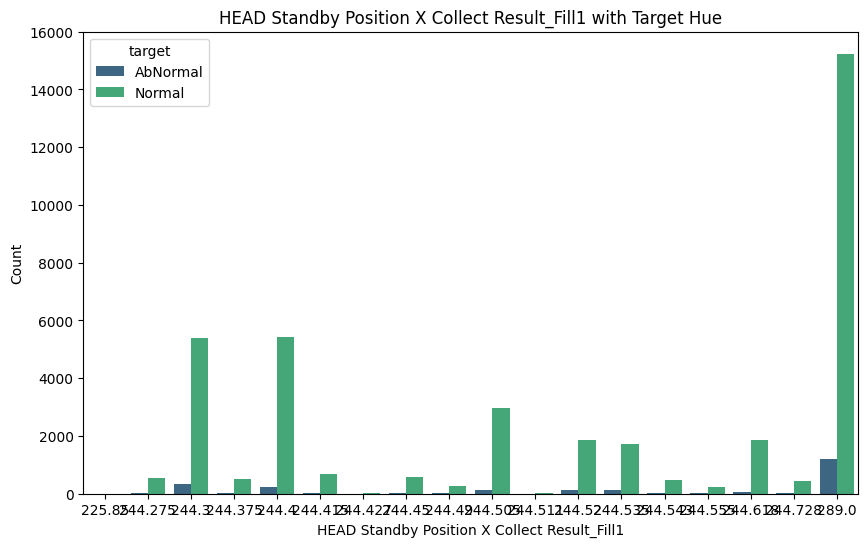

In [25]:
plt.figure(figsize=(10, 6))
sns.countplot(
    data=head_position_df,
    x='HEAD Standby Position X Collect Result_Fill1',
    hue='target',
    palette='viridis'
)
plt.title('HEAD Standby Position X Collect Result_Fill1 with Target Hue')
plt.xlabel('HEAD Standby Position X Collect Result_Fill1')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

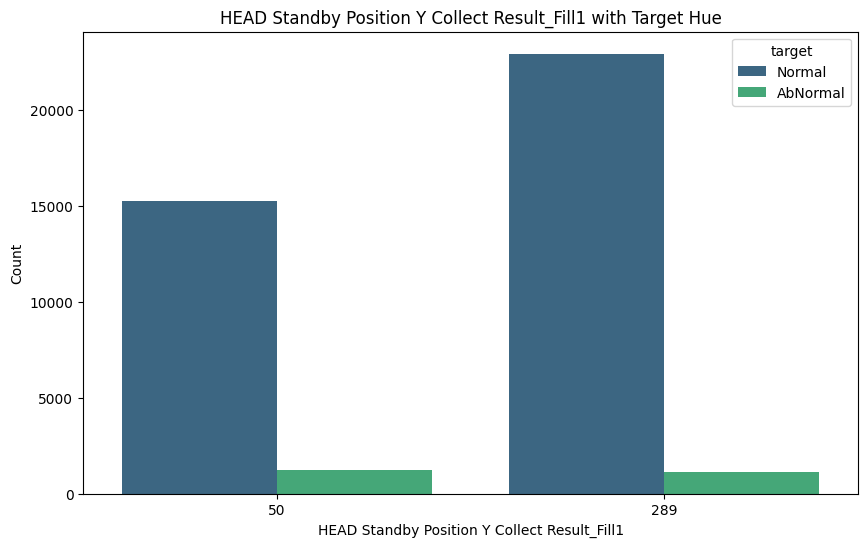

In [26]:
plt.figure(figsize=(10, 6))
sns.countplot(
    data=head_position_df,
    x='HEAD Standby Position Y Collect Result_Fill1',
    hue='target',
    palette='viridis'
)
plt.title('HEAD Standby Position Y Collect Result_Fill1 with Target Hue')
plt.xlabel('HEAD Standby Position Y Collect Result_Fill1')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

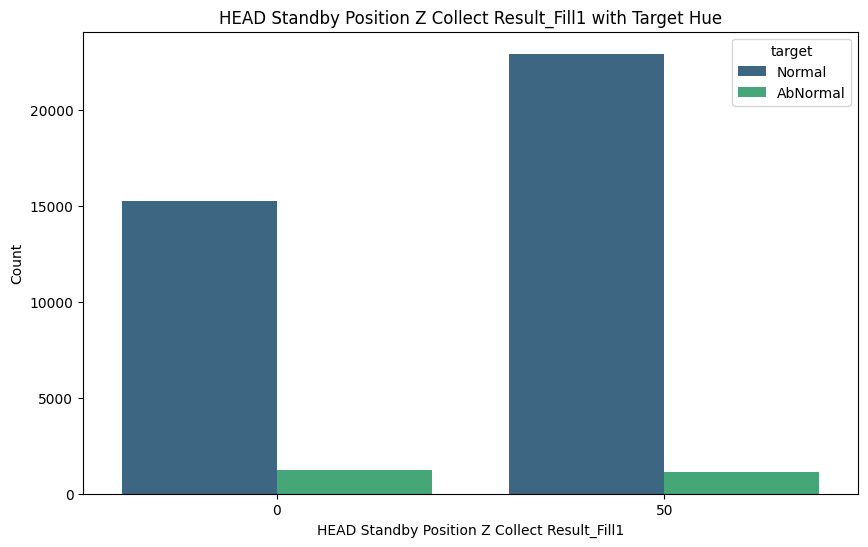

In [27]:
plt.figure(figsize=(10, 6))
sns.countplot(
    data=head_position_df,
    x='HEAD Standby Position Z Collect Result_Fill1',
    hue='target',
    palette='viridis'
)
plt.title('HEAD Standby Position Z Collect Result_Fill1 with Target Hue')
plt.xlabel('HEAD Standby Position Z Collect Result_Fill1')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

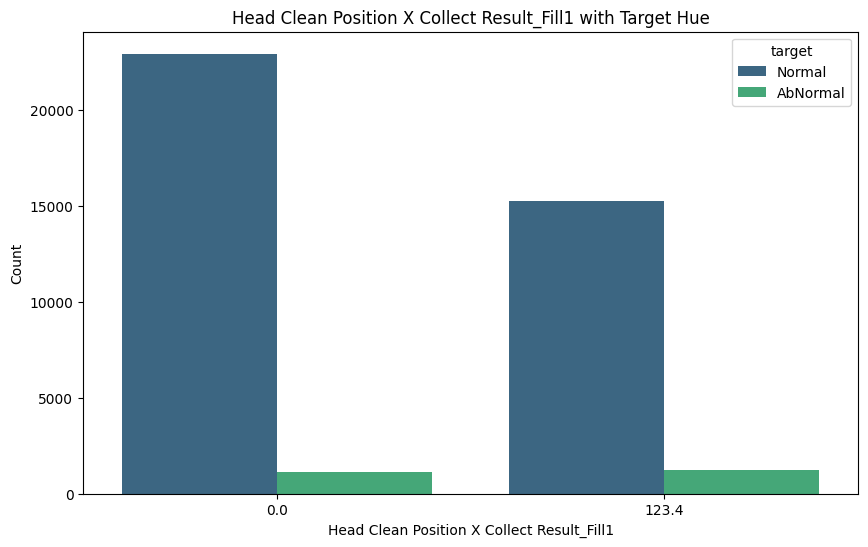

In [28]:
plt.figure(figsize=(10, 6))
sns.countplot(
    data=head_position_df,
    x='Head Clean Position X Collect Result_Fill1',
    hue='target',
    palette='viridis'
)
plt.title('Head Clean Position X Collect Result_Fill1 with Target Hue')
plt.xlabel('Head Clean Position X Collect Result_Fill1')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

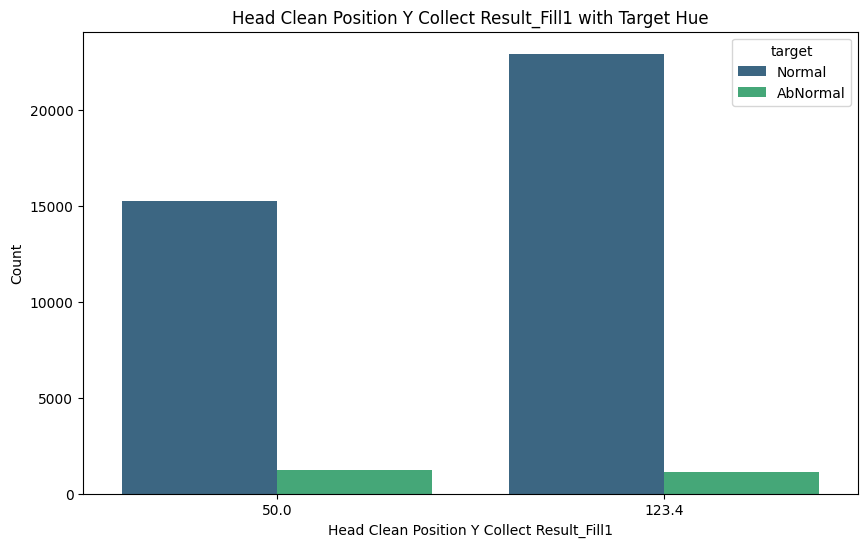

In [29]:
plt.figure(figsize=(10, 6))
sns.countplot(
    data=head_position_df,
    x='Head Clean Position Y Collect Result_Fill1',
    hue='target',
    palette='viridis'
)
plt.title('Head Clean Position Y Collect Result_Fill1 with Target Hue')
plt.xlabel('Head Clean Position Y Collect Result_Fill1')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

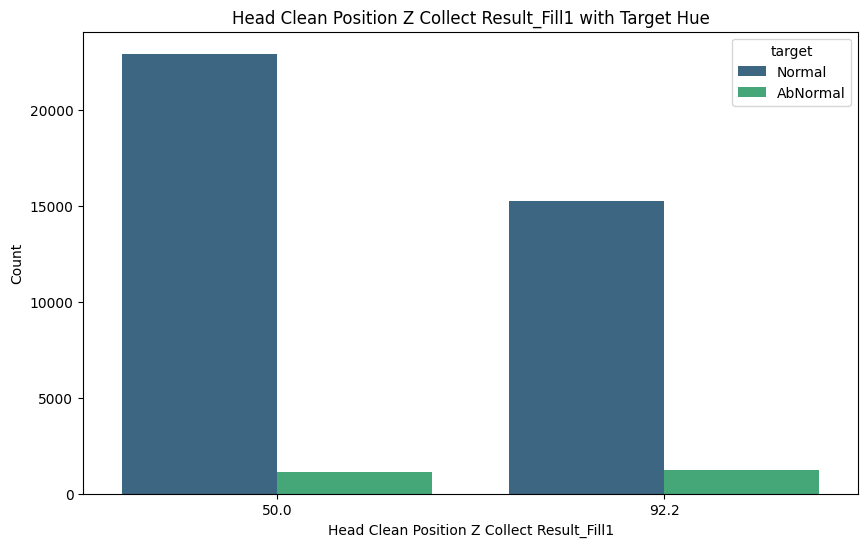

In [30]:
plt.figure(figsize=(10, 6))
sns.countplot(
    data=head_position_df,
    x='Head Clean Position Z Collect Result_Fill1',
    hue='target',
    palette='viridis'
)
plt.title('Head Clean Position Z Collect Result_Fill1 with Target Hue')
plt.xlabel('Head Clean Position Z Collect Result_Fill1')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

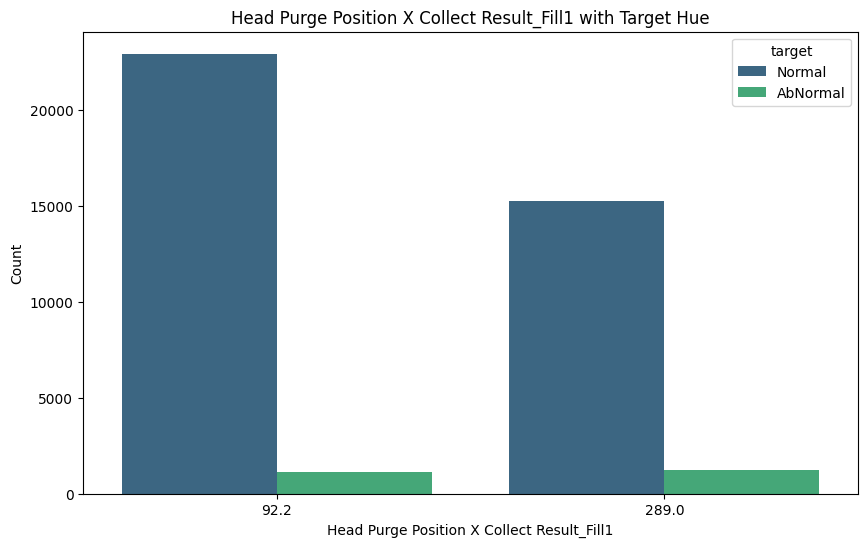

In [32]:
plt.figure(figsize=(10, 6))
sns.countplot(
    data=head_position_df,
    x='Head Purge Position X Collect Result_Fill1',
    hue='target',
    palette='viridis'
)
plt.title('Head Purge Position X Collect Result_Fill1 with Target Hue')
plt.xlabel('Head Purge Position X Collect Result_Fill1')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

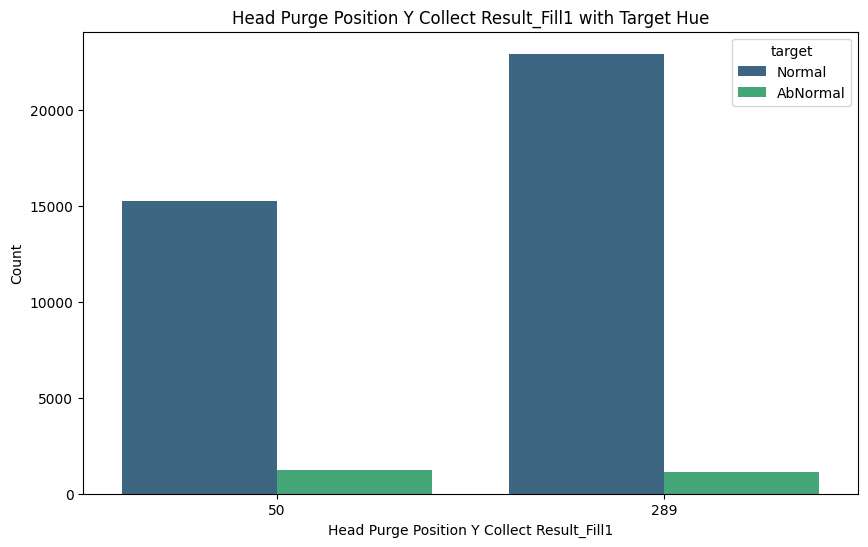

In [33]:
plt.figure(figsize=(10, 6))
sns.countplot(
    data=head_position_df,
    x='Head Purge Position Y Collect Result_Fill1',
    hue='target',
    palette='viridis'
)
plt.title('Head Purge Position Y Collect Result_Fill1 with Target Hue')
plt.xlabel('Head Purge Position Y Collect Result_Fill1')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

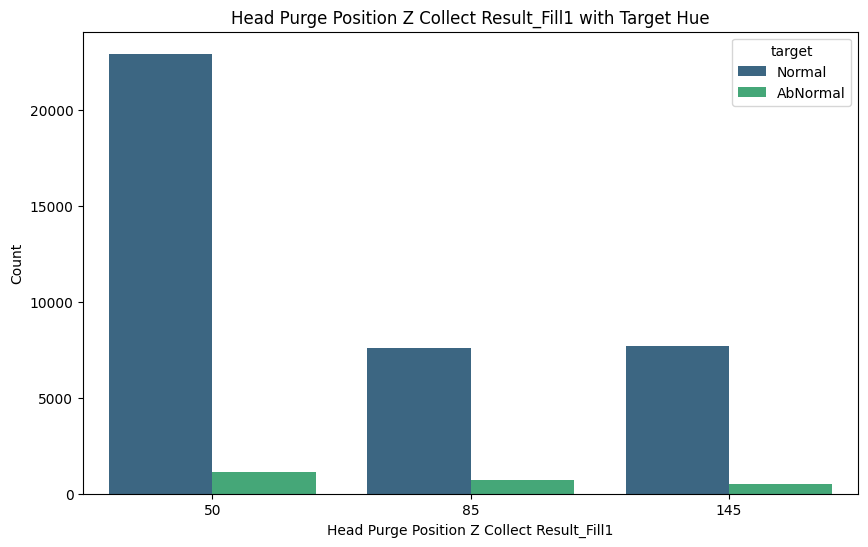

In [34]:
plt.figure(figsize=(10, 6))
sns.countplot(
    data=head_position_df,
    x='Head Purge Position Z Collect Result_Fill1',
    hue='target',
    palette='viridis'
)
plt.title('Head Purge Position Z Collect Result_Fill1 with Target Hue')
plt.xlabel('Head Purge Position Z Collect Result_Fill1')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

 'Machine Tact time Collect Result_Fill1',
 
 'PalletID Collect Result_Fill1',
 
 'Production Qty Collect Result_Fill1',
 
 'Receip No Collect Result_Fill1',
 
 'WorkMode Collect Result_Fill1',

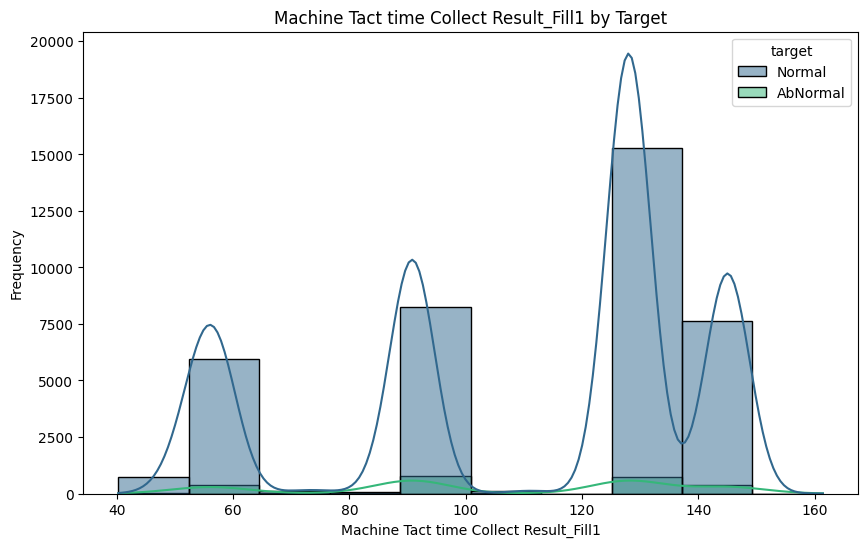

In [36]:
# 히스토그램 시각화
plt.figure(figsize=(10, 6))
sns.histplot(data=df_fill1_cleaned, x='Machine Tact time Collect Result_Fill1', hue='target', bins=10, kde=True, palette='viridis')
plt.title('Machine Tact time Collect Result_Fill1 by Target')
plt.xlabel('Machine Tact time Collect Result_Fill1')
plt.ylabel('Frequency')
plt.show()

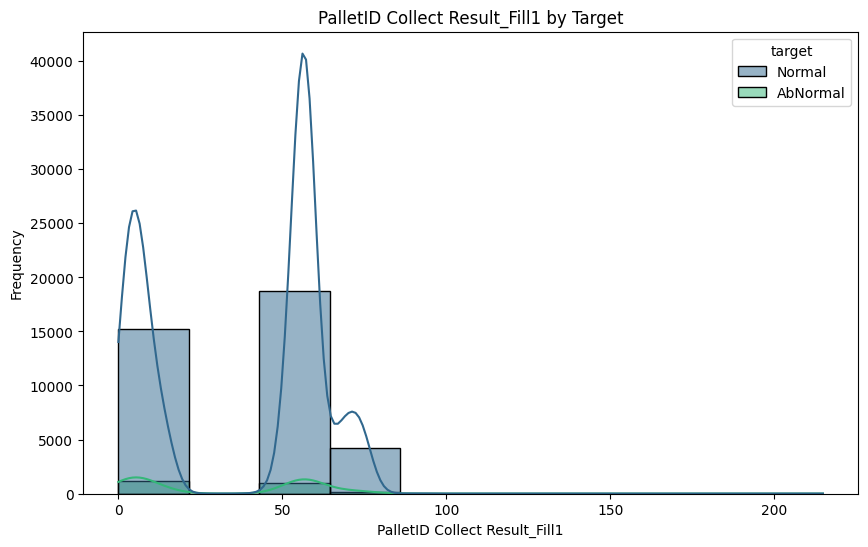

In [37]:
# 히스토그램 시각화
plt.figure(figsize=(10, 6))
sns.histplot(data=df_fill1_cleaned, x='PalletID Collect Result_Fill1', hue='target', bins=10, kde=True, palette='viridis')
plt.title('PalletID Collect Result_Fill1 by Target')
plt.xlabel('PalletID Collect Result_Fill1')
plt.ylabel('Frequency')
plt.show()

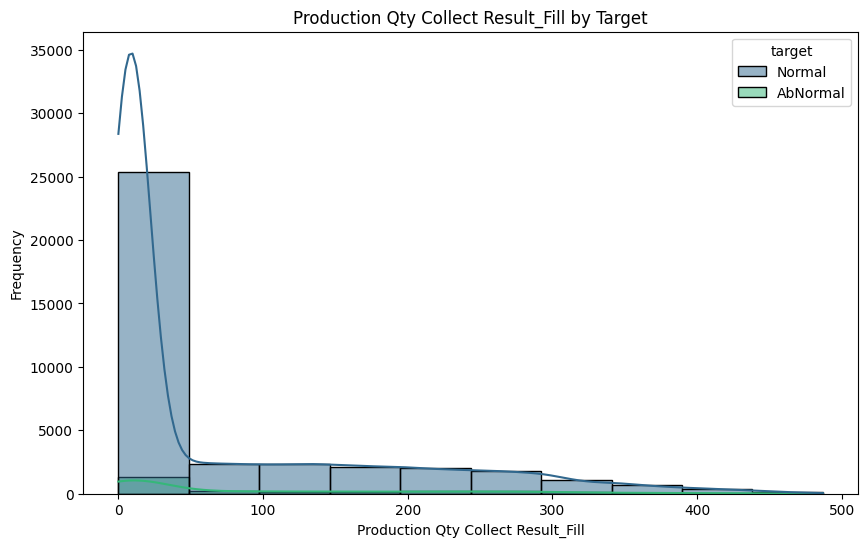

In [40]:
# 히스토그램 시각화
plt.figure(figsize=(10, 6))
sns.histplot(data=df_fill1_cleaned, x='Production Qty Collect Result_Fill1', hue='target', bins=10, kde=True, palette='viridis')
plt.title('Production Qty Collect Result_Fill by Target')
plt.xlabel('Production Qty Collect Result_Fill')
plt.ylabel('Frequency')
plt.show()

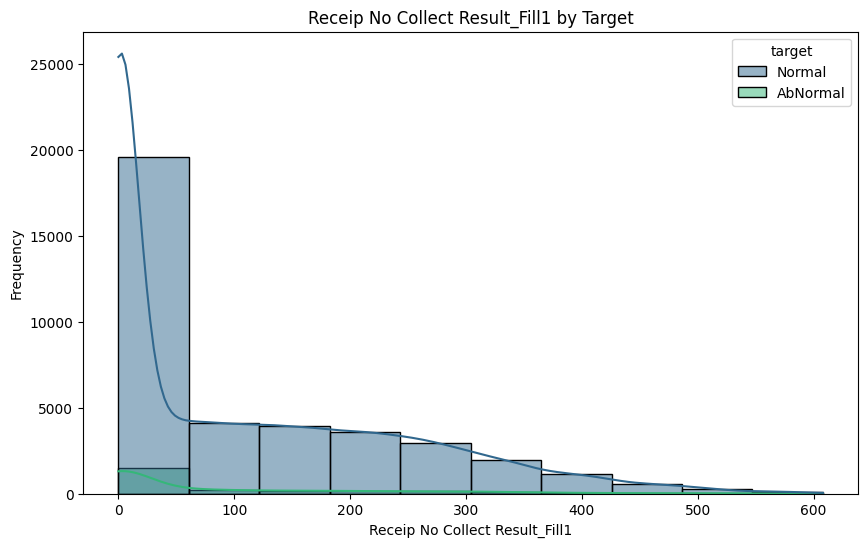

In [41]:
# 히스토그램 시각화
plt.figure(figsize=(10, 6))
sns.histplot(data=df_fill1_cleaned, x='Receip No Collect Result_Fill1', hue='target', bins=10, kde=True, palette='viridis')
plt.title('Receip No Collect Result_Fill1 by Target')
plt.xlabel('Receip No Collect Result_Fill1')
plt.ylabel('Frequency')
plt.show()

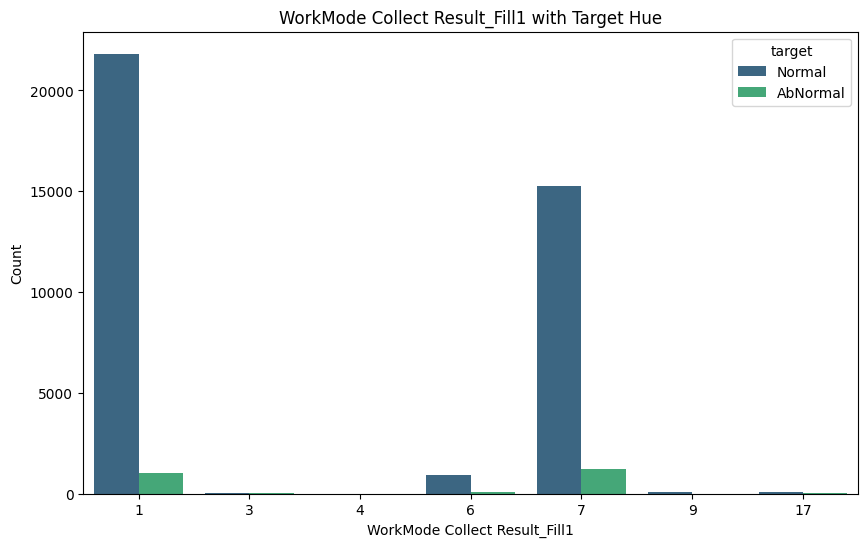

In [42]:
plt.figure(figsize=(10, 6))
sns.countplot(
    data=df_fill1_cleaned,
    x='WorkMode Collect Result_Fill1',
    hue='target',
    palette='viridis'
)
plt.title('WorkMode Collect Result_Fill1 with Target Hue')
plt.xlabel('WorkMode Collect Result_Fill1')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

# FIll2 데이터 분석

In [17]:
df_fill2

,Wip Line_Fill2,Process Desc._Fill2,Equipment_Fill2,Model.Suffix_Fill2,Insp. Seq No._Fill2,Insp Judge Code_Fill2,CURE END POSITION X Collect Result_Fill2,CURE END POSITION Z Collect Result_Fill2,CURE END POSITION Θ Collect Result_Fill2,CURE SPEED Collect Result_Fill2,...,Head Clean Position Z Collect Result_Fill2,Head Purge Position X Collect Result_Fill2,Head Purge Position Y Collect Result_Fill2,Head Purge Position Z Collect Result_Fill2,Machine Tact time Collect Result_Fill2,PalletID Collect Result_Fill2,Production Qty Collect Result_Fill2,Receip No Collect Result_Fill2,WorkMode Collect Result_Fill2,target
0,IVI-OB6,Fill2 Dispenser,Fill2 dispenser #1,AJX75334505,1,OK,240,33,-90,48,...,50.0,91.8,270,50,114.612,19.9,7,127,1,Normal
1,IVI-OB6,Fill2 Dispenser,Fill2 dispenser #1,AJX75334505,1,OK,240,33,-90,50,...,91.8,270.0,50,85,19.600,7.0,185,1,0,Normal
2,IVI-OB6,Fill2 Dispenser,Fill2 dispenser #2,AJX75334501,1,OK,240,33,-90,50,...,50.0,91.8,270,50,114.612,19.8,10,73,1,Normal
3,IVI-OB6,Fill2 Dispenser,Fill2 dispenser #2,AJX75334501,1,OK,240,33,-90,50,...,91.8,270.0,50,85,19.900,12.0,268,1,0,Normal
4,IVI-OB6,Fill2 Dispenser,Fill2 dispenser #1,AJX75334501,1,OK,240,32,-90,50,...,91.8,270.0,50,85,19.700,8.0,121,1,0,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40501,IVI-OB6,Fill2 Dispenser,Fill2 dispenser #1,AJX75334501,1,OK,240,33,-90,50,...,91.8,270.0,50,85,19.200,1.0,318,1,0,Normal
40502,IVI-OB6,Fill2 Dispenser,Fill2 dispenser #2,AJX75334501,1,OK,240,33,-90,48,...,50.0,91.8,270,50,114.612,20.5,14,197,1,Normal
40503,IVI-OB6,Fill2 Dispenser,Fill2 dispenser #1,AJX75334501,1,OK,240,33,-90,50,...,50.0,91.8,270,50,85.000,19.7,1,27,1,Normal
40504,IVI-OB6,Fill2 Dispenser,Fill2 dispenser #2,AJX75334501,1,OK,240,33,-90,50,...,91.8,270.0,50,85,20.100,13.0,117,1,0,Normal


In [18]:
list(df_fill2.columns) 

['Wip Line_Fill2',
 'Process Desc._Fill2',
 'Equipment_Fill2',
 'Model.Suffix_Fill2',
 'Insp. Seq No._Fill2',
 'Insp Judge Code_Fill2',
 'CURE END POSITION X Collect Result_Fill2',
 'CURE END POSITION Z Collect Result_Fill2',
 'CURE END POSITION Θ Collect Result_Fill2',
 'CURE SPEED Collect Result_Fill2',
 'CURE STANDBY POSITION X Collect Result_Fill2',
 'CURE STANDBY POSITION Z Collect Result_Fill2',
 'CURE STANDBY POSITION Θ Collect Result_Fill2',
 'CURE START POSITION X Collect Result_Fill2',
 'CURE START POSITION Z Collect Result_Fill2',
 'CURE START POSITION Θ Collect Result_Fill2',
 'DISCHARGED SPEED OF RESIN Collect Result_Fill2',
 'DISCHARGED TIME OF RESIN(Stage1) Collect Result_Fill2',
 'DISCHARGED TIME OF RESIN(Stage2) Collect Result_Fill2',
 'DISCHARGED TIME OF RESIN(Stage3) Collect Result_Fill2',
 'Dispense Volume(Stage1) Collect Result_Fill2',
 'Dispense Volume(Stage2) Collect Result_Fill2',
 'Dispense Volume(Stage3) Collect Result_Fill2',
 'HEAD NORMAL COORDINATE X AXIS(S

In [19]:
# unique 값이 1개인 열을 찾기
columns_with_unique_values_1 = [col for col in df_fill2.columns if df_fill2[col].nunique() == 1]
print('Unique 값이 1개')
for col in columns_with_unique_values_1:
    print(col)

Unique 값이 1개
Wip Line_Fill2
Process Desc._Fill2
Insp. Seq No._Fill2
Insp Judge Code_Fill2
CURE END POSITION Θ Collect Result_Fill2
CURE STANDBY POSITION X Collect Result_Fill2
CURE STANDBY POSITION Θ Collect Result_Fill2
CURE START POSITION Θ Collect Result_Fill2
DISCHARGED SPEED OF RESIN Collect Result_Fill2
DISCHARGED TIME OF RESIN(Stage1) Collect Result_Fill2
DISCHARGED TIME OF RESIN(Stage2) Collect Result_Fill2
DISCHARGED TIME OF RESIN(Stage3) Collect Result_Fill2
Dispense Volume(Stage1) Collect Result_Fill2
Dispense Volume(Stage2) Collect Result_Fill2
Dispense Volume(Stage3) Collect Result_Fill2
HEAD NORMAL COORDINATE X AXIS(Stage1) Judge Value_Fill2


In [20]:
df_fill2_cleaned = df_fill2.drop(columns=columns_with_unique_values_1)

print("\n칼럼 제거 후 데이터프레임:")
df_fill2_cleaned


칼럼 제거 후 데이터프레임:


,Equipment_Fill2,Model.Suffix_Fill2,CURE END POSITION X Collect Result_Fill2,CURE END POSITION Z Collect Result_Fill2,CURE SPEED Collect Result_Fill2,CURE STANDBY POSITION Z Collect Result_Fill2,CURE START POSITION X Collect Result_Fill2,CURE START POSITION Z Collect Result_Fill2,HEAD NORMAL COORDINATE X AXIS(Stage1) Collect Result_Fill2,HEAD NORMAL COORDINATE X AXIS(Stage2) Collect Result_Fill2,...,Head Clean Position Z Collect Result_Fill2,Head Purge Position X Collect Result_Fill2,Head Purge Position Y Collect Result_Fill2,Head Purge Position Z Collect Result_Fill2,Machine Tact time Collect Result_Fill2,PalletID Collect Result_Fill2,Production Qty Collect Result_Fill2,Receip No Collect Result_Fill2,WorkMode Collect Result_Fill2,target
0,Fill2 dispenser #1,AJX75334505,240,33,48,33,1020,33,NaN,835.5,...,50.0,91.8,270,50,114.612,19.9,7,127,1,Normal
1,Fill2 dispenser #1,AJX75334505,240,33,50,33,1020,33,835.5,458.0,...,91.8,270.0,50,85,19.600,7.0,185,1,0,Normal
2,Fill2 dispenser #2,AJX75334501,240,33,50,33,1020,33,OK,305.0,...,50.0,91.8,270,50,114.612,19.8,10,73,1,Normal
3,Fill2 dispenser #2,AJX75334501,240,33,50,33,1020,33,305,499.8,...,91.8,270.0,50,85,19.900,12.0,268,1,0,Normal
4,Fill2 dispenser #1,AJX75334501,240,32,50,33,1020,33,835.5,458.0,...,91.8,270.0,50,85,19.700,8.0,121,1,0,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40501,Fill2 dispenser #1,AJX75334501,240,33,50,33,1020,33,835.5,458.0,...,91.8,270.0,50,85,19.200,1.0,318,1,0,Normal
40502,Fill2 dispenser #2,AJX75334501,240,33,48,33,1020,33,NaN,304.8,...,50.0,91.8,270,50,114.612,20.5,14,197,1,Normal
40503,Fill2 dispenser #1,AJX75334501,240,33,50,33,1020,33,OK,835.5,...,50.0,91.8,270,50,85.000,19.7,1,27,1,Normal
40504,Fill2 dispenser #2,AJX75334501,240,33,50,33,1020,33,305,499.8,...,91.8,270.0,50,85,20.100,13.0,117,1,0,Normal


In [21]:
list(df_fill2_cleaned.columns) 

['Equipment_Fill2',
 'Model.Suffix_Fill2',
 'CURE END POSITION X Collect Result_Fill2',
 'CURE END POSITION Z Collect Result_Fill2',
 'CURE SPEED Collect Result_Fill2',
 'CURE STANDBY POSITION Z Collect Result_Fill2',
 'CURE START POSITION X Collect Result_Fill2',
 'CURE START POSITION Z Collect Result_Fill2',
 'HEAD NORMAL COORDINATE X AXIS(Stage1) Collect Result_Fill2',
 'HEAD NORMAL COORDINATE X AXIS(Stage2) Collect Result_Fill2',
 'HEAD NORMAL COORDINATE X AXIS(Stage3) Collect Result_Fill2',
 'HEAD NORMAL COORDINATE Y AXIS(Stage1) Collect Result_Fill2',
 'HEAD NORMAL COORDINATE Y AXIS(Stage2) Collect Result_Fill2',
 'HEAD NORMAL COORDINATE Y AXIS(Stage3) Collect Result_Fill2',
 'HEAD NORMAL COORDINATE Z AXIS(Stage1) Collect Result_Fill2',
 'HEAD NORMAL COORDINATE Z AXIS(Stage2) Collect Result_Fill2',
 'HEAD NORMAL COORDINATE Z AXIS(Stage3) Collect Result_Fill2',
 'HEAD Standby Position X Collect Result_Fill2',
 'HEAD Standby Position Y Collect Result_Fill2',
 'HEAD Standby Position

In [22]:
for column in df_fill2_cleaned.columns:
    unique_values = df_fill2_cleaned[column].unique()
    print(f'Column: {column}')
    print(f'Unique values: {unique_values}')
    print
    

Column: Equipment_Fill2
Unique values: ['Fill2 dispenser #1' 'Fill2 dispenser #2']
Column: Model.Suffix_Fill2
Unique values: ['AJX75334505' 'AJX75334501' 'AJX75334502' 'AJX75334507' 'AJX75334506'
 'AJX75334508' 'AJX75334503']
Column: CURE END POSITION X Collect Result_Fill2
Unique values: [ 240 1020]
Column: CURE END POSITION Z Collect Result_Fill2
Unique values: [33 32 22]
Column: CURE SPEED Collect Result_Fill2
Unique values: [48 50 51 45 53 55 40 75]
Column: CURE STANDBY POSITION Z Collect Result_Fill2
Unique values: [33 32 22 23]
Column: CURE START POSITION X Collect Result_Fill2
Unique values: [1020  240]
Column: CURE START POSITION Z Collect Result_Fill2
Unique values: [33 32 22 23]
Column: HEAD NORMAL COORDINATE X AXIS(Stage1) Collect Result_Fill2
Unique values: [nan '835.5' 'OK' '305']
Column: HEAD NORMAL COORDINATE X AXIS(Stage2) Collect Result_Fill2
Unique values: [835.5 458.  305.  499.8 304.8]
Column: HEAD NORMAL COORDINATE X AXIS(Stage3) Collect Result_Fill2
Unique values:

In [23]:
### Equipment, Model.Shufix
'Equipment_Fill2',

'Model.Suffix_Fill2',

('Model.Suffix_Fill2',)

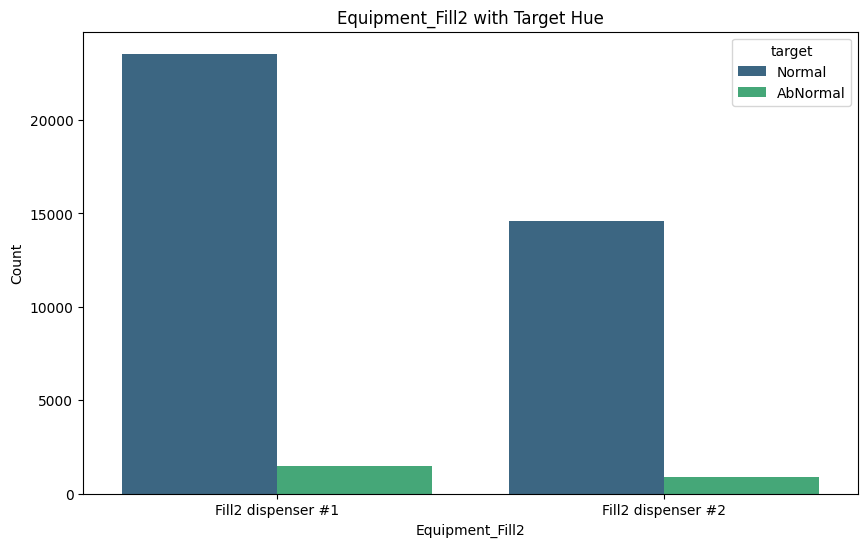

In [24]:
plt.figure(figsize=(10, 6))
sns.countplot(
    data=df_fill2_cleaned,
    x='Equipment_Fill2',
    hue='target',
    palette='viridis'
)
plt.title('Equipment_Fill2 with Target Hue')
plt.xlabel('Equipment_Fill2')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

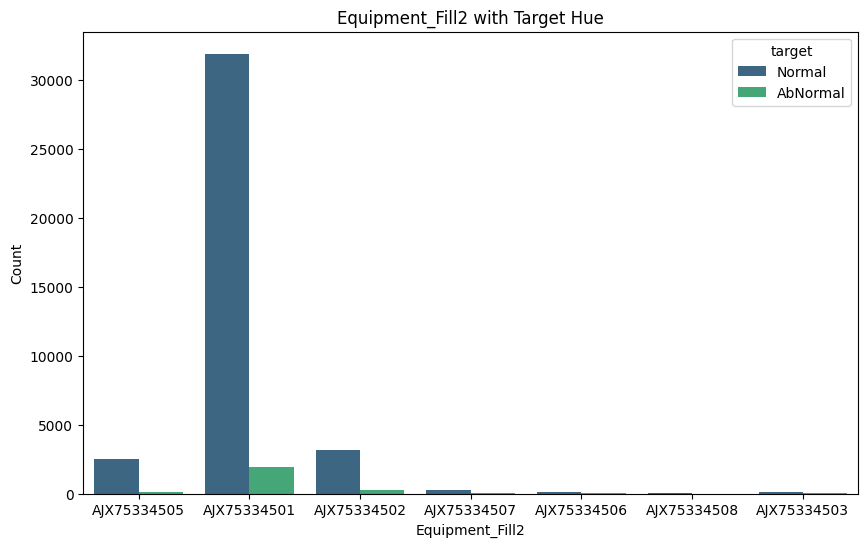

In [25]:
plt.figure(figsize=(10, 6))
sns.countplot(
    data=df_fill2_cleaned,
    x='Model.Suffix_Fill2',
    hue='target',
    palette='viridis'
)
plt.title('Equipment_Fill2 with Target Hue')
plt.xlabel('Equipment_Fill2')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

### CURE speed, position
'CURE END POSITION X Collect Result_Fill2',

'CURE END POSITION Z Collect Result_Fill2',
 
'CURE SPEED Collect Result_Fill2',
 
'CURE STANDBY POSITION Z Collect Result_Fill2',
 
'CURE START POSITION X Collect Result_Fill2',
 
'CURE START POSITION Z Collect Result_Fill2',

In [26]:
cure_speed_position = df_fill2_cleaned[[
    'CURE END POSITION X Collect Result_Fill2',
    'CURE END POSITION Z Collect Result_Fill2',
    'CURE SPEED Collect Result_Fill2',
    'CURE STANDBY POSITION Z Collect Result_Fill2',
    'CURE START POSITION X Collect Result_Fill2',
    'CURE START POSITION Z Collect Result_Fill2',
    'target'
    ]
]
cure_speed_position

,CURE END POSITION X Collect Result_Fill2,CURE END POSITION Z Collect Result_Fill2,CURE SPEED Collect Result_Fill2,CURE STANDBY POSITION Z Collect Result_Fill2,CURE START POSITION X Collect Result_Fill2,CURE START POSITION Z Collect Result_Fill2,target
0,240,33,48,33,1020,33,Normal
1,240,33,50,33,1020,33,Normal
2,240,33,50,33,1020,33,Normal
3,240,33,50,33,1020,33,Normal
4,240,32,50,33,1020,33,Normal
...,...,...,...,...,...,...,...
40501,240,33,50,33,1020,33,Normal
40502,240,33,48,33,1020,33,Normal
40503,240,33,50,33,1020,33,Normal
40504,240,33,50,33,1020,33,Normal


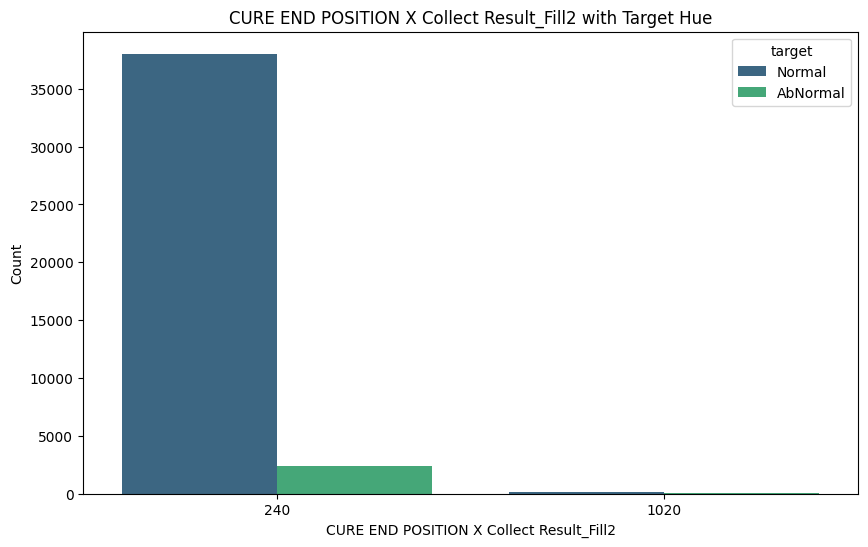

In [27]:
plt.figure(figsize=(10, 6))
sns.countplot(
    data=cure_speed_position,
    x='CURE END POSITION X Collect Result_Fill2',
    hue='target',
    palette='viridis'
)
plt.title('CURE END POSITION X Collect Result_Fill2 with Target Hue')
plt.xlabel('CURE END POSITION X Collect Result_Fill2')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

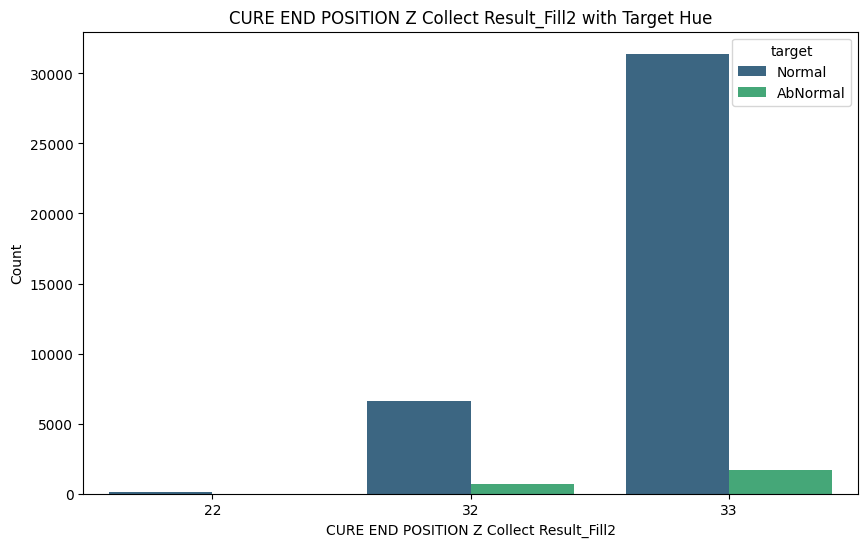

In [28]:
plt.figure(figsize=(10, 6))
sns.countplot(
    data=cure_speed_position,
    x='CURE END POSITION Z Collect Result_Fill2',
    hue='target',
    palette='viridis'
)
plt.title('CURE END POSITION Z Collect Result_Fill2 with Target Hue')
plt.xlabel('CURE END POSITION Z Collect Result_Fill2')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

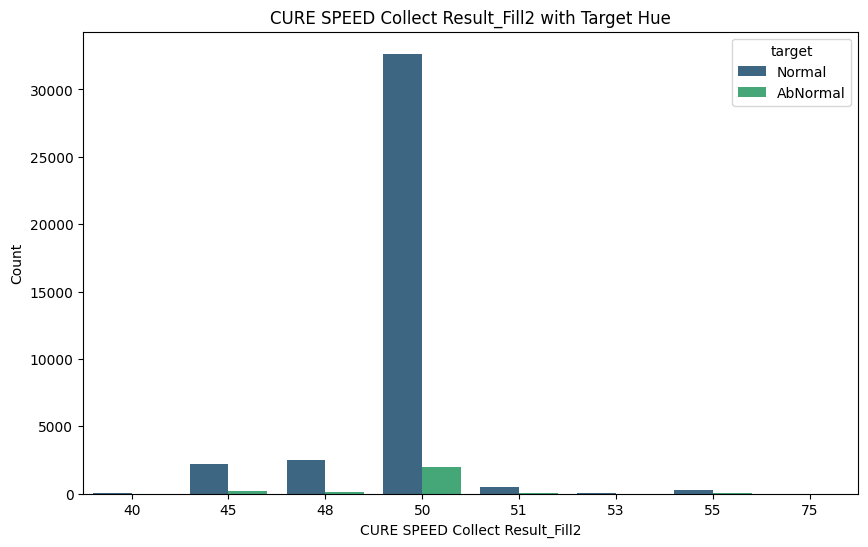

In [29]:
plt.figure(figsize=(10, 6))
sns.countplot(
    data=cure_speed_position,
    x='CURE SPEED Collect Result_Fill2',
    hue='target',
    palette='viridis'
)
plt.title('CURE SPEED Collect Result_Fill2 with Target Hue')
plt.xlabel('CURE SPEED Collect Result_Fill2')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

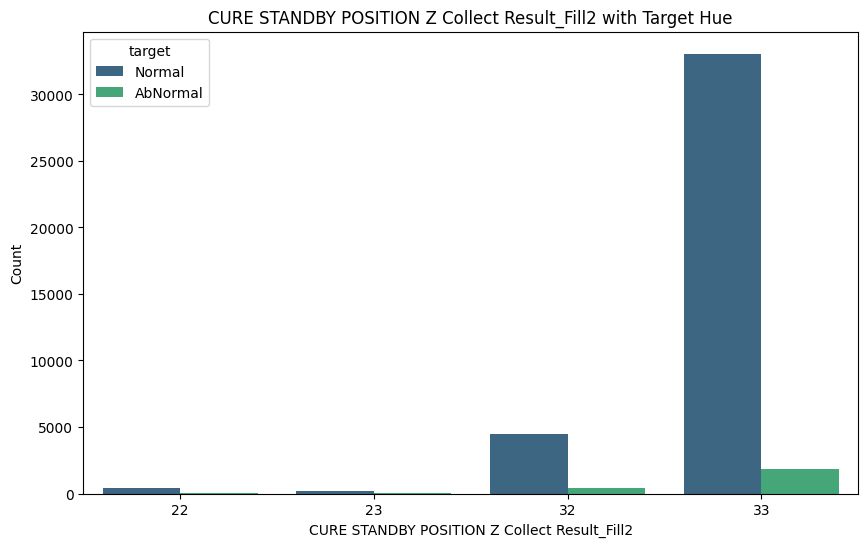

In [30]:
plt.figure(figsize=(10, 6))
sns.countplot(
    data=cure_speed_position,
    x='CURE STANDBY POSITION Z Collect Result_Fill2',
    hue='target',
    palette='viridis'
)
plt.title('CURE STANDBY POSITION Z Collect Result_Fill2 with Target Hue')
plt.xlabel('CURE STANDBY POSITION Z Collect Result_Fill2')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

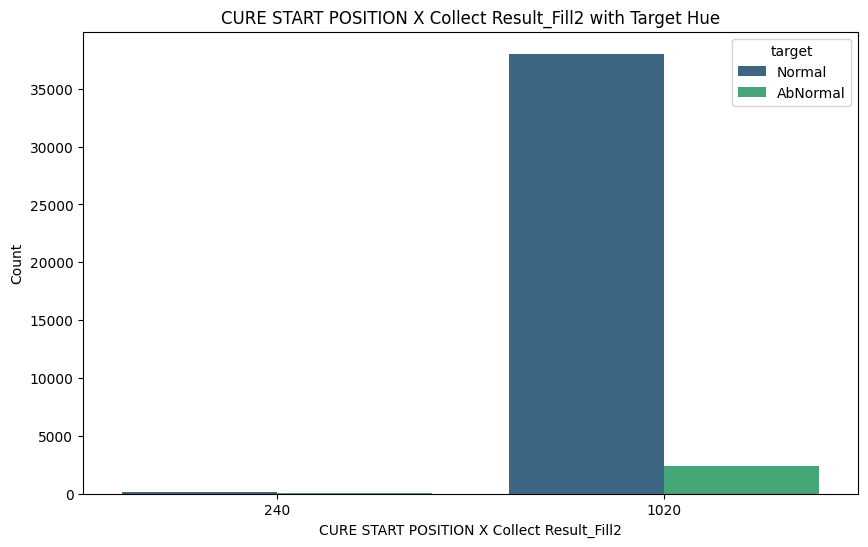

In [31]:
plt.figure(figsize=(10, 6))
sns.countplot(
    data=cure_speed_position,
    x='CURE START POSITION X Collect Result_Fill2',
    hue='target',
    palette='viridis'
)
plt.title('CURE START POSITION X Collect Result_Fill2 with Target Hue')
plt.xlabel('CURE START POSITION X Collect Result_Fill2')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

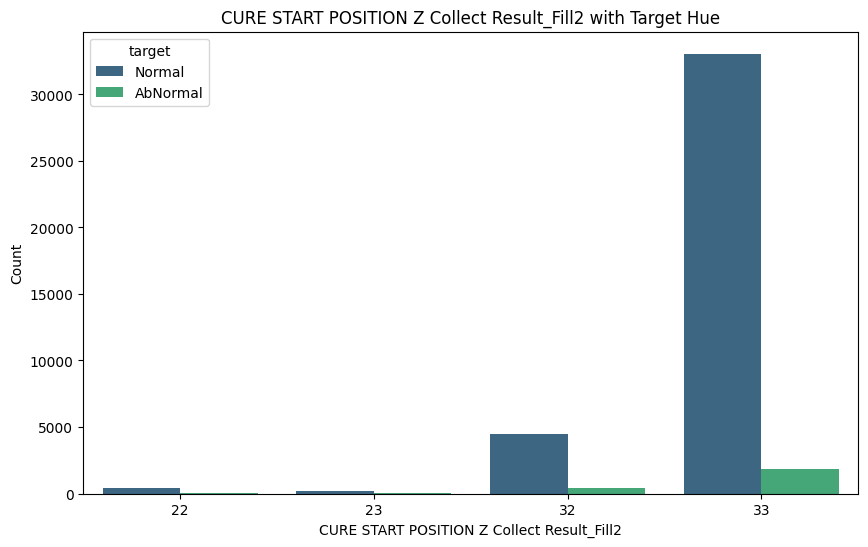

In [32]:
plt.figure(figsize=(10, 6))
sns.countplot(
    data=cure_speed_position,
    x='CURE START POSITION Z Collect Result_Fill2',
    hue='target',
    palette='viridis'
)
plt.title('CURE START POSITION Z Collect Result_Fill2 with Target Hue')
plt.xlabel('CURE START POSITION Z Collect Result_Fill2')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

## HEAD NORMAL COORDINATE AXIS
'HEAD NORMAL COORDINATE X AXIS(Stage1) Collect Result_Fill2',

'HEAD NORMAL COORDINATE X AXIS(Stage2) Collect Result_Fill2',
 
'HEAD NORMAL COORDINATE X AXIS(Stage3) Collect Result_Fill2',
 
'HEAD NORMAL COORDINATE Y AXIS(Stage1) Collect Result_Fill2',
 
'HEAD NORMAL COORDINATE Y AXIS(Stage2) Collect Result_Fill2',
 
'HEAD NORMAL COORDINATE Y AXIS(Stage3) Collect Result_Fill2',
 
'HEAD NORMAL COORDINATE Z AXIS(Stage1) Collect Result_Fill2',
 
'HEAD NORMAL COORDINATE Z AXIS(Stage2) Collect Result_Fill2',

'HEAD NORMAL COORDINATE Z AXIS(Stage3) Collect Result_Fill2', 

In [35]:
head_normal_coordinate_axis_df = df_fill2_cleaned[[
    'HEAD NORMAL COORDINATE X AXIS(Stage1) Collect Result_Fill2',
    'HEAD NORMAL COORDINATE X AXIS(Stage2) Collect Result_Fill2',
    'HEAD NORMAL COORDINATE X AXIS(Stage3) Collect Result_Fill2',
    'HEAD NORMAL COORDINATE Y AXIS(Stage1) Collect Result_Fill2',
    'HEAD NORMAL COORDINATE Y AXIS(Stage2) Collect Result_Fill2',
    'HEAD NORMAL COORDINATE Y AXIS(Stage3) Collect Result_Fill2',
    'HEAD NORMAL COORDINATE Z AXIS(Stage1) Collect Result_Fill2',
    'HEAD NORMAL COORDINATE Z AXIS(Stage2) Collect Result_Fill2',
    'HEAD NORMAL COORDINATE Z AXIS(Stage3) Collect Result_Fill2',
    'target'
    ]
]
head_normal_coordinate_axis_df

,HEAD NORMAL COORDINATE X AXIS(Stage1) Collect Result_Fill2,HEAD NORMAL COORDINATE X AXIS(Stage2) Collect Result_Fill2,HEAD NORMAL COORDINATE X AXIS(Stage3) Collect Result_Fill2,HEAD NORMAL COORDINATE Y AXIS(Stage1) Collect Result_Fill2,HEAD NORMAL COORDINATE Y AXIS(Stage2) Collect Result_Fill2,HEAD NORMAL COORDINATE Y AXIS(Stage3) Collect Result_Fill2,HEAD NORMAL COORDINATE Z AXIS(Stage1) Collect Result_Fill2,HEAD NORMAL COORDINATE Z AXIS(Stage2) Collect Result_Fill2,HEAD NORMAL COORDINATE Z AXIS(Stage3) Collect Result_Fill2,target
0,NaN,835.5,458.0,156.0,428.0,427.9,428.0,243.7,243.7,Normal
1,835.5,458.0,156.0,428.0,427.9,428.0,243.7,243.7,243.7,Normal
2,OK,305.0,499.8,694.0,1324.2,1324.2,1324.2,243.5,243.5,Normal
3,305,499.8,694.0,1324.2,1324.2,1324.2,243.5,243.5,243.5,Normal
4,835.5,458.0,156.0,428.0,427.9,428.0,243.7,243.7,243.7,Normal
...,...,...,...,...,...,...,...,...,...,...
40501,835.5,458.0,156.0,428.0,427.9,428.0,243.7,243.7,243.7,Normal
40502,NaN,304.8,499.8,692.8,1324.2,1324.2,1324.2,243.5,243.5,Normal
40503,OK,835.5,458.0,156.0,428.0,427.9,428.0,243.7,243.7,Normal
40504,305,499.8,694.0,1324.2,1324.2,1324.2,243.5,243.5,243.5,Normal


In [36]:
# 'HEAD NORMAL COORDINATE X AXIS(Stage1) Collect Result_Dam' 칼럼의 NaN 데이터 개수 계산
nan_count = head_normal_coordinate_axis_df['HEAD NORMAL COORDINATE X AXIS(Stage1) Collect Result_Fill2'].isna().sum()

# 결과 출력
print(f"'HEAD NORMAL COORDINATE X AXIS(Stage1) Collect Result_Fill2' 칼럼의 NaN 데이터 개수: {nan_count}")

'HEAD NORMAL COORDINATE X AXIS(Stage1) Collect Result_Fill2' 칼럼의 NaN 데이터 개수: 12766


In [37]:
head_coordinate_axis_stage1_x = head_normal_coordinate_axis_df[[
    'HEAD NORMAL COORDINATE X AXIS(Stage1) Collect Result_Fill2',
    'target']
]
head_coordinate_axis_stage1_x =  head_coordinate_axis_stage1_x.dropna(subset=['HEAD NORMAL COORDINATE X AXIS(Stage1) Collect Result_Fill2'])
head_coordinate_axis_stage1_x

,HEAD NORMAL COORDINATE X AXIS(Stage1) Collect Result_Fill2,target
1,835.5,Normal
2,OK,Normal
3,305,Normal
4,835.5,Normal
5,835.5,Normal
...,...,...
40499,OK,Normal
40501,835.5,Normal
40503,OK,Normal
40504,305,Normal


In [38]:
head_coordinate_axis_stage1_x = head_coordinate_axis_stage1_x[head_coordinate_axis_stage1_x['HEAD NORMAL COORDINATE X AXIS(Stage1) Collect Result_Fill2'] != 'OK']
head_coordinate_axis_stage1_x

,HEAD NORMAL COORDINATE X AXIS(Stage1) Collect Result_Fill2,target
1,835.5,Normal
3,305,Normal
4,835.5,Normal
5,835.5,Normal
8,835.5,Normal
...,...,...
40497,835.5,Normal
40498,835.5,Normal
40501,835.5,Normal
40504,305,Normal


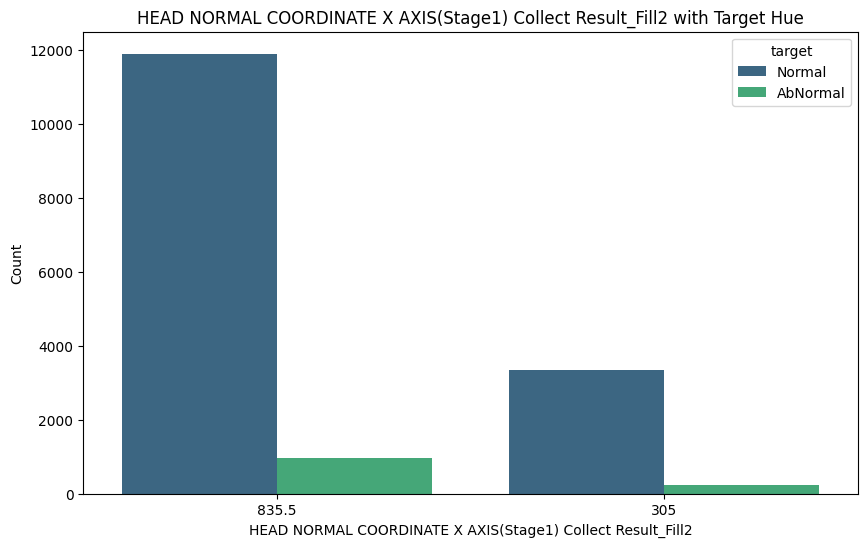

In [39]:
plt.figure(figsize=(10, 6))
sns.countplot(
    data=head_coordinate_axis_stage1_x,
    x='HEAD NORMAL COORDINATE X AXIS(Stage1) Collect Result_Fill2',
    hue='target',
    palette='viridis'
)
plt.title('HEAD NORMAL COORDINATE X AXIS(Stage1) Collect Result_Fill2 with Target Hue')
plt.xlabel('HEAD NORMAL COORDINATE X AXIS(Stage1) Collect Result_Fill2')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

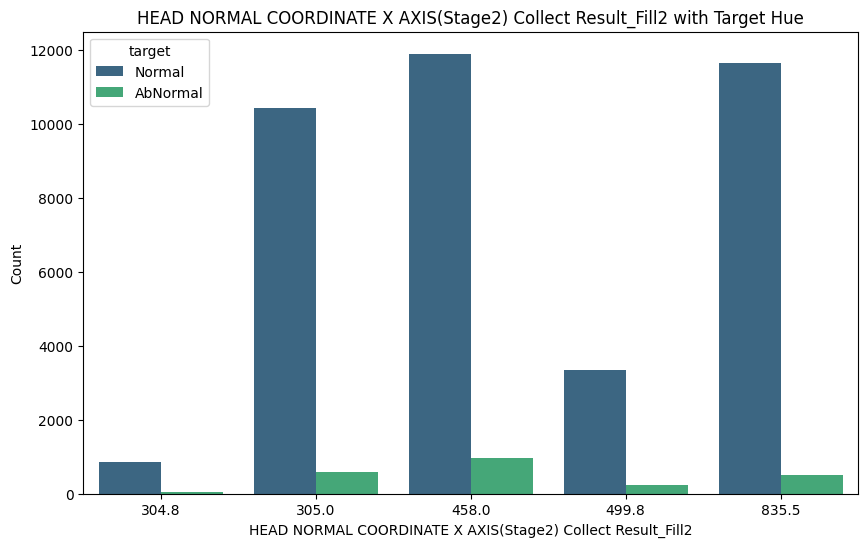

In [40]:
plt.figure(figsize=(10, 6))
sns.countplot(
    data=head_normal_coordinate_axis_df,
    x='HEAD NORMAL COORDINATE X AXIS(Stage2) Collect Result_Fill2',
    hue='target',
    palette='viridis'
)
plt.title('HEAD NORMAL COORDINATE X AXIS(Stage2) Collect Result_Fill2 with Target Hue')
plt.xlabel('HEAD NORMAL COORDINATE X AXIS(Stage2) Collect Result_Fill2')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

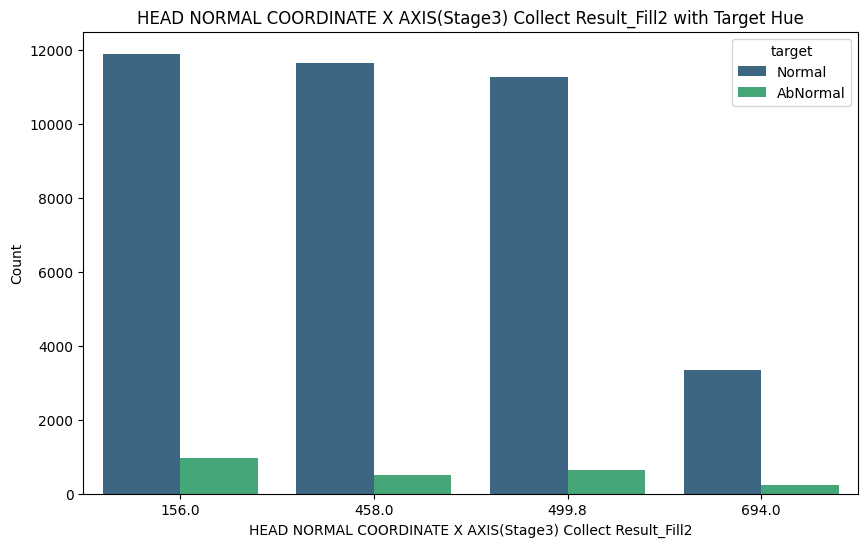

In [41]:
plt.figure(figsize=(10, 6))
sns.countplot(
    data=head_normal_coordinate_axis_df,
    x='HEAD NORMAL COORDINATE X AXIS(Stage3) Collect Result_Fill2',
    hue='target',
    palette='viridis'
)
plt.title('HEAD NORMAL COORDINATE X AXIS(Stage3) Collect Result_Fill2 with Target Hue')
plt.xlabel('HEAD NORMAL COORDINATE X AXIS(Stage3) Collect Result_Fill2')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

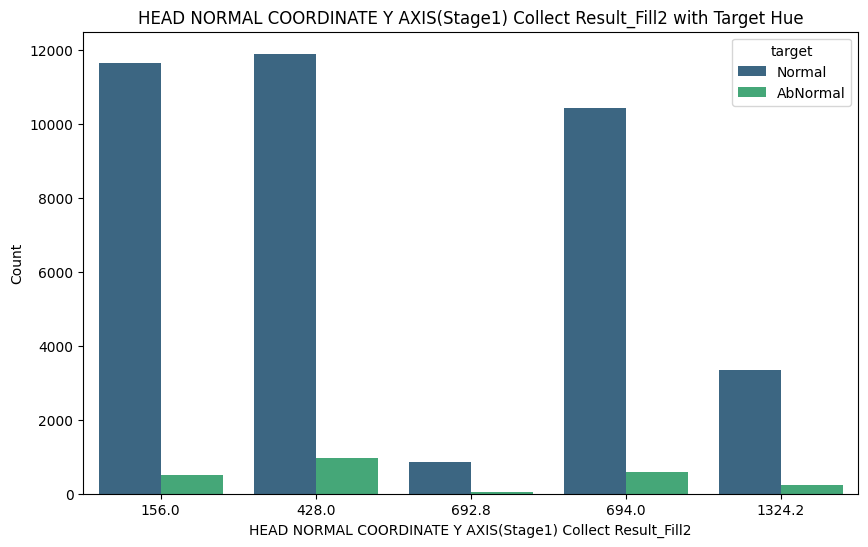

In [42]:
plt.figure(figsize=(10, 6))
sns.countplot(
    data=head_normal_coordinate_axis_df,
    x='HEAD NORMAL COORDINATE Y AXIS(Stage1) Collect Result_Fill2',
    hue='target',
    palette='viridis'
)
plt.title('HEAD NORMAL COORDINATE Y AXIS(Stage1) Collect Result_Fill2 with Target Hue')
plt.xlabel('HEAD NORMAL COORDINATE Y AXIS(Stage1) Collect Result_Fill2')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

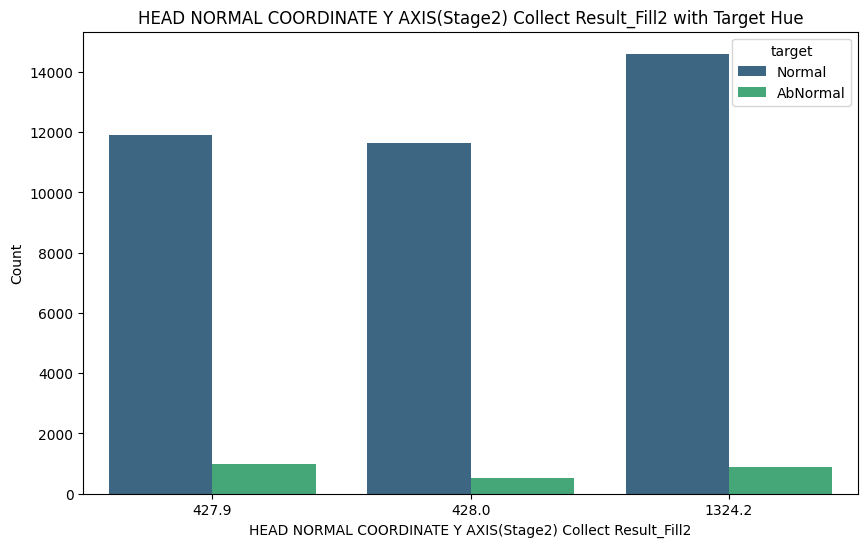

In [43]:
plt.figure(figsize=(10, 6))
sns.countplot(
    data=head_normal_coordinate_axis_df,
    x='HEAD NORMAL COORDINATE Y AXIS(Stage2) Collect Result_Fill2',
    hue='target',
    palette='viridis'
)
plt.title('HEAD NORMAL COORDINATE Y AXIS(Stage2) Collect Result_Fill2 with Target Hue')
plt.xlabel('HEAD NORMAL COORDINATE Y AXIS(Stage2) Collect Result_Fill2')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

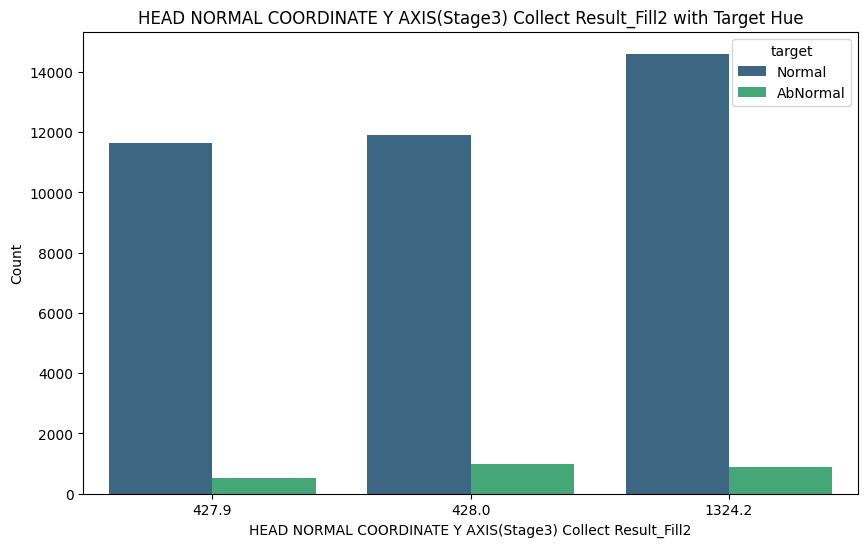

In [44]:
plt.figure(figsize=(10, 6))
sns.countplot(
    data=head_normal_coordinate_axis_df,
    x='HEAD NORMAL COORDINATE Y AXIS(Stage3) Collect Result_Fill2',
    hue='target',
    palette='viridis'
)
plt.title('HEAD NORMAL COORDINATE Y AXIS(Stage3) Collect Result_Fill2 with Target Hue')
plt.xlabel('HEAD NORMAL COORDINATE Y AXIS(Stage3) Collect Result_Fill2')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

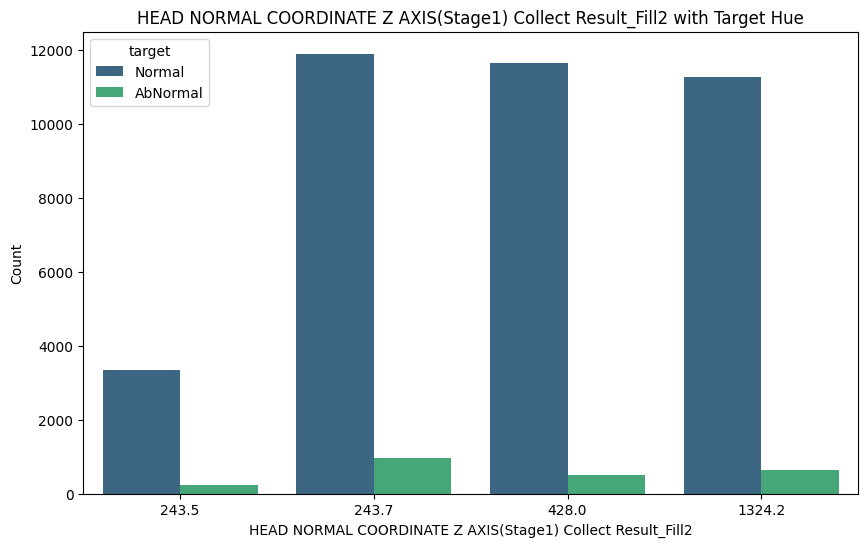

In [45]:
plt.figure(figsize=(10, 6))
sns.countplot(
    data=head_normal_coordinate_axis_df,
    x='HEAD NORMAL COORDINATE Z AXIS(Stage1) Collect Result_Fill2',
    hue='target',
    palette='viridis'
)
plt.title('HEAD NORMAL COORDINATE Z AXIS(Stage1) Collect Result_Fill2 with Target Hue')
plt.xlabel('HEAD NORMAL COORDINATE Z AXIS(Stage1) Collect Result_Fill2')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

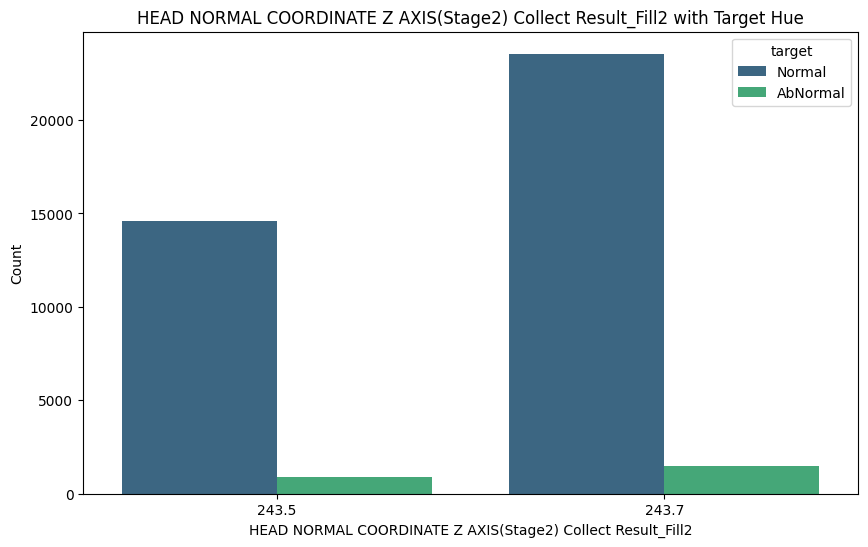

In [46]:
plt.figure(figsize=(10, 6))
sns.countplot(
    data=head_normal_coordinate_axis_df,
    x='HEAD NORMAL COORDINATE Z AXIS(Stage2) Collect Result_Fill2',
    hue='target',
    palette='viridis'
)
plt.title('HEAD NORMAL COORDINATE Z AXIS(Stage2) Collect Result_Fill2 with Target Hue')
plt.xlabel('HEAD NORMAL COORDINATE Z AXIS(Stage2) Collect Result_Fill2')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

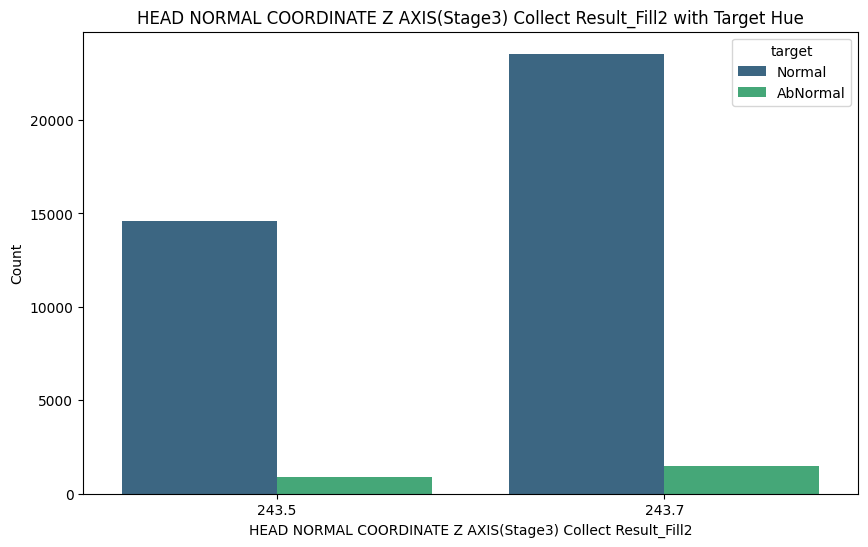

In [47]:
plt.figure(figsize=(10, 6))
sns.countplot(
    data=head_normal_coordinate_axis_df,
    x='HEAD NORMAL COORDINATE Z AXIS(Stage3) Collect Result_Fill2',
    hue='target',
    palette='viridis'
)
plt.title('HEAD NORMAL COORDINATE Z AXIS(Stage3) Collect Result_Fill2 with Target Hue')
plt.xlabel('HEAD NORMAL COORDINATE Z AXIS(Stage3) Collect Result_Fill2')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

### HEAD Position
'HEAD Standby Position X Collect Result_Fill2',

'HEAD Standby Position Y Collect Result_Fill2',

'HEAD Standby Position Z Collect Result_Fill2',

'Head Clean Position X Collect Result_Fill2',

'Head Clean Position Y Collect Result_Fill2',

'Head Clean Position Z Collect Result_Fill2',

'Head Purge Position X Collect Result_Fill2',

'Head Purge Position Y Collect Result_Fill2',

'Head Purge Position Z Collect Result_Fill2',

In [48]:
 head_position_df = df_fill2_cleaned[[
    'HEAD Standby Position X Collect Result_Fill2',
    'HEAD Standby Position Y Collect Result_Fill2',
    'HEAD Standby Position Z Collect Result_Fill2',
    'Head Clean Position X Collect Result_Fill2',
    'Head Clean Position Y Collect Result_Fill2',
    'Head Clean Position Z Collect Result_Fill2',
    'Head Purge Position X Collect Result_Fill2',
    'Head Purge Position Y Collect Result_Fill2',
    'Head Purge Position Z Collect Result_Fill2',
    'target'
    ]
]
head_position_df

,HEAD Standby Position X Collect Result_Fill2,HEAD Standby Position Y Collect Result_Fill2,HEAD Standby Position Z Collect Result_Fill2,Head Clean Position X Collect Result_Fill2,Head Clean Position Y Collect Result_Fill2,Head Clean Position Z Collect Result_Fill2,Head Purge Position X Collect Result_Fill2,Head Purge Position Y Collect Result_Fill2,Head Purge Position Z Collect Result_Fill2,target
0,243.7,270,50,-10,119,50.0,91.8,270,50,Normal
1,270.0,50,-10,119,50,91.8,270.0,50,85,Normal
2,243.5,270,50,-10,119,50.0,91.8,270,50,Normal
3,270.0,50,-10,119,50,91.8,270.0,50,85,Normal
4,270.0,50,-10,119,50,91.8,270.0,50,85,Normal
...,...,...,...,...,...,...,...,...,...,...
40501,270.0,50,-10,119,50,91.8,270.0,50,85,Normal
40502,243.5,270,50,-10,119,50.0,91.8,270,50,Normal
40503,243.7,270,50,-10,119,50.0,91.8,270,50,Normal
40504,270.0,50,-10,119,50,91.8,270.0,50,85,Normal


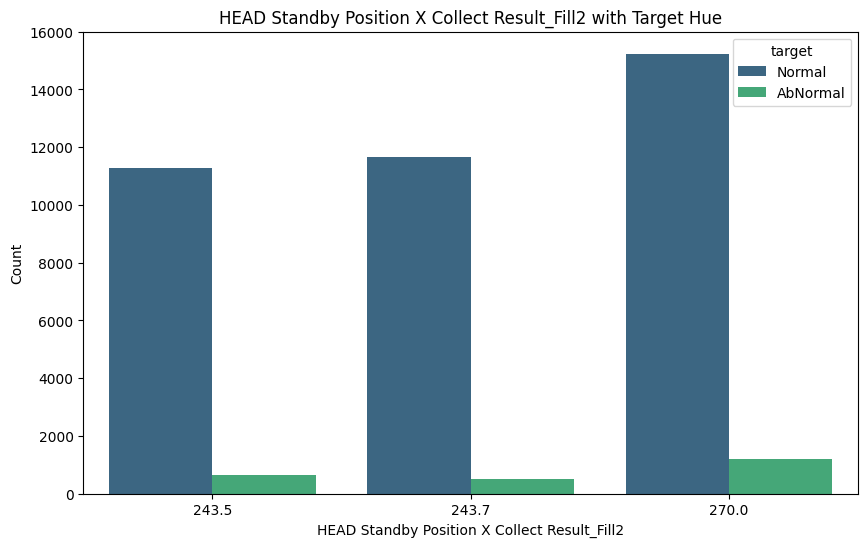

In [49]:
plt.figure(figsize=(10, 6))
sns.countplot(
    data=head_position_df,
    x='HEAD Standby Position X Collect Result_Fill2',
    hue='target',
    palette='viridis'
)
plt.title('HEAD Standby Position X Collect Result_Fill2 with Target Hue')
plt.xlabel('HEAD Standby Position X Collect Result_Fill2')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

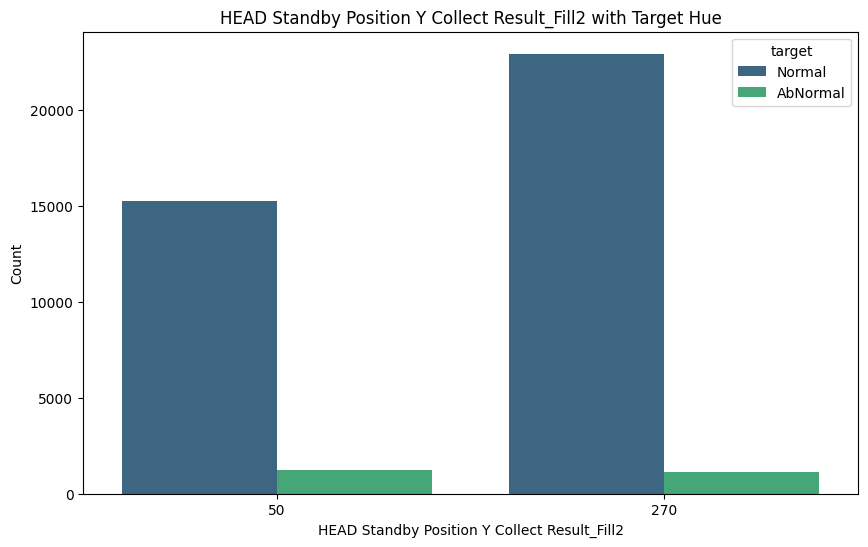

In [50]:
plt.figure(figsize=(10, 6))
sns.countplot(
    data=head_position_df,
    x='HEAD Standby Position Y Collect Result_Fill2',
    hue='target',
    palette='viridis'
)
plt.title('HEAD Standby Position Y Collect Result_Fill2 with Target Hue')
plt.xlabel('HEAD Standby Position Y Collect Result_Fill2')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

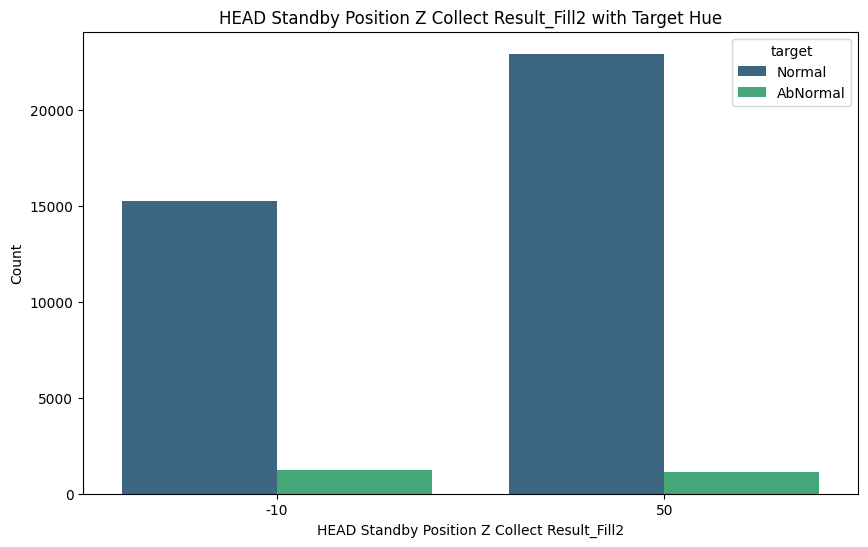

In [51]:
plt.figure(figsize=(10, 6))
sns.countplot(
    data=head_position_df,
    x='HEAD Standby Position Z Collect Result_Fill2',
    hue='target',
    palette='viridis'
)
plt.title('HEAD Standby Position Z Collect Result_Fill2 with Target Hue')
plt.xlabel('HEAD Standby Position Z Collect Result_Fill2')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

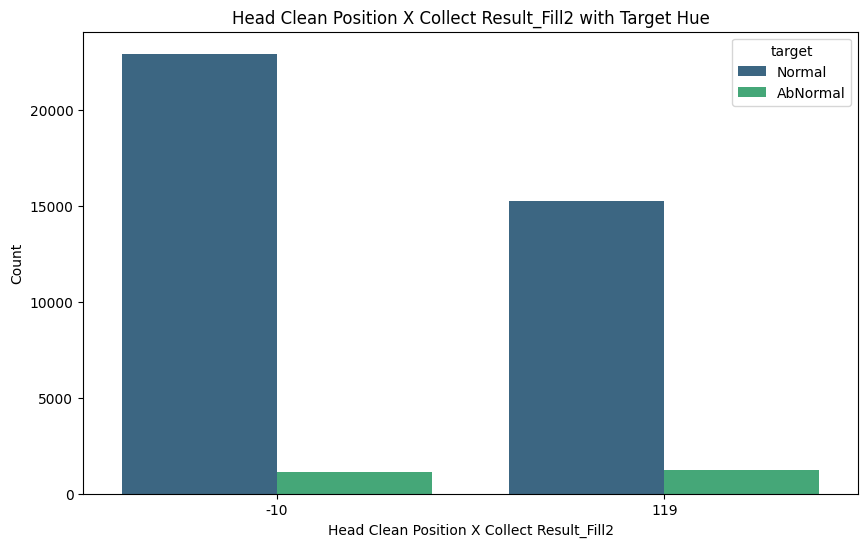

In [53]:
plt.figure(figsize=(10, 6))
sns.countplot(
    data=head_position_df,
    x='Head Clean Position X Collect Result_Fill2',
    hue='target',
    palette='viridis'
)
plt.title('Head Clean Position X Collect Result_Fill2 with Target Hue')
plt.xlabel('Head Clean Position X Collect Result_Fill2')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

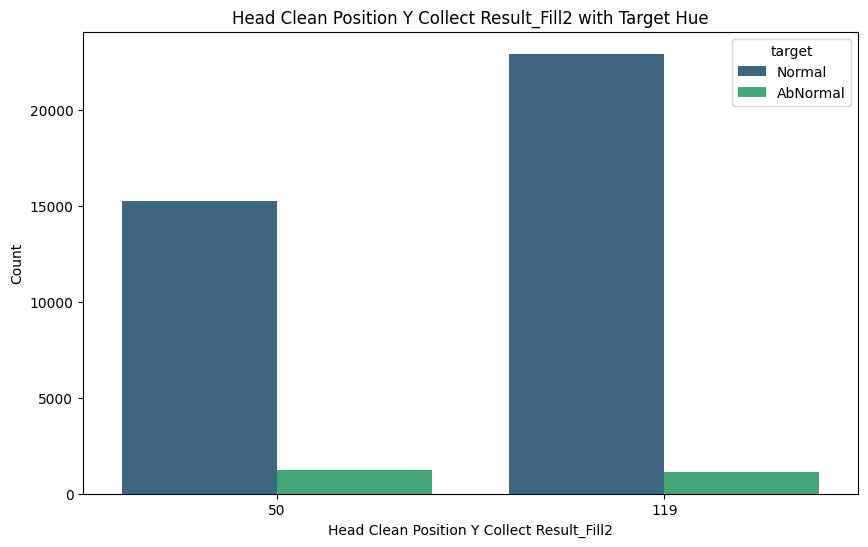

In [54]:
plt.figure(figsize=(10, 6))
sns.countplot(
    data=head_position_df,
    x='Head Clean Position Y Collect Result_Fill2',
    hue='target',
    palette='viridis'
)
plt.title('Head Clean Position Y Collect Result_Fill2 with Target Hue')
plt.xlabel('Head Clean Position Y Collect Result_Fill2')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

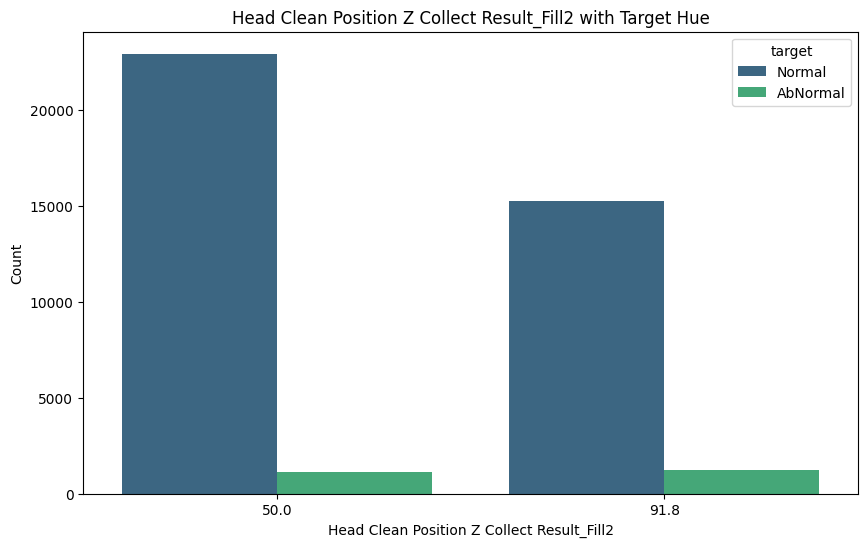

In [55]:
plt.figure(figsize=(10, 6))
sns.countplot(
    data=head_position_df,
    x='Head Clean Position Z Collect Result_Fill2',
    hue='target',
    palette='viridis'
)
plt.title('Head Clean Position Z Collect Result_Fill2 with Target Hue')
plt.xlabel('Head Clean Position Z Collect Result_Fill2')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

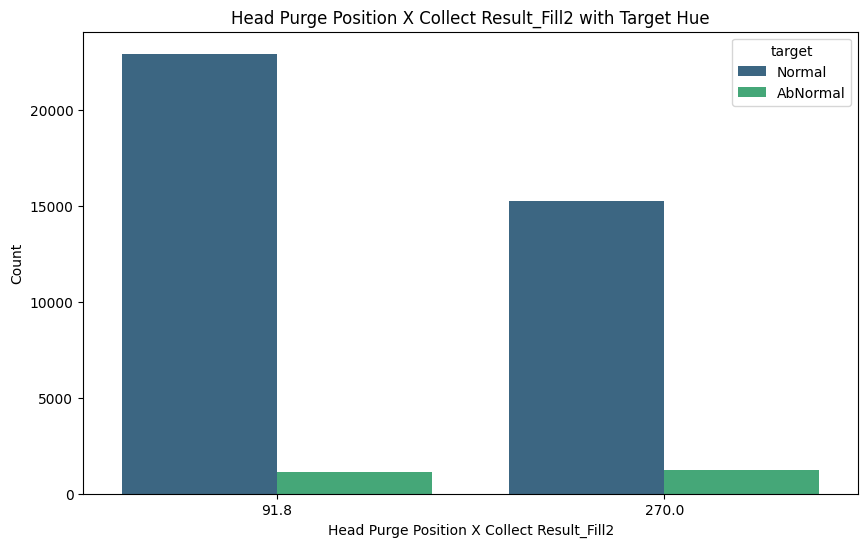

In [58]:
plt.figure(figsize=(10, 6))
sns.countplot(
    data=head_position_df,
    x='Head Purge Position X Collect Result_Fill2',
    hue='target',
    palette='viridis'
)
plt.title('Head Purge Position X Collect Result_Fill2 with Target Hue')
plt.xlabel('Head Purge Position X Collect Result_Fill2')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

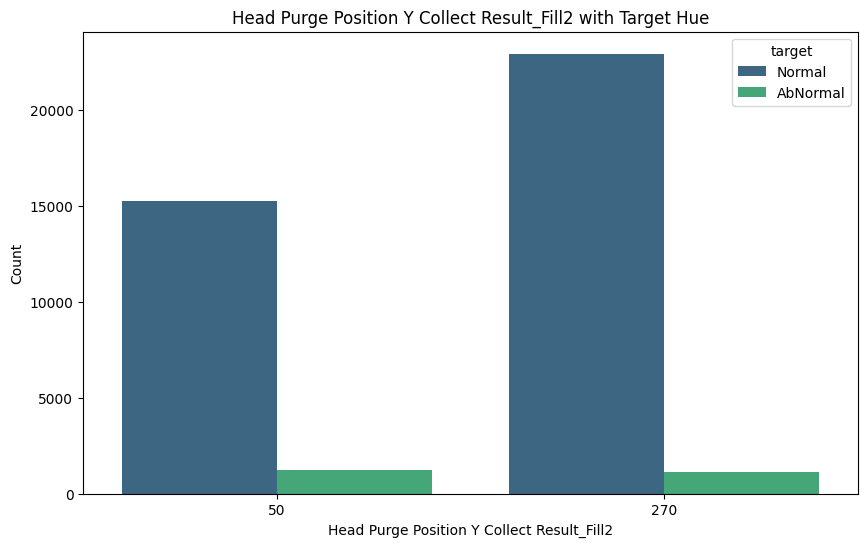

In [59]:
plt.figure(figsize=(10, 6))
sns.countplot(
    data=head_position_df,
    x='Head Purge Position Y Collect Result_Fill2',
    hue='target',
    palette='viridis'
)
plt.title('Head Purge Position Y Collect Result_Fill2 with Target Hue')
plt.xlabel('Head Purge Position Y Collect Result_Fill2')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

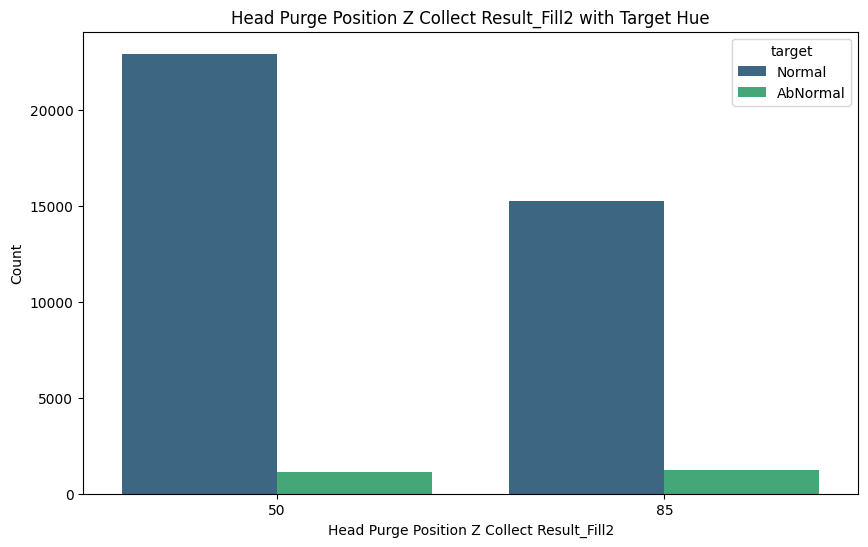

In [60]:
plt.figure(figsize=(10, 6))
sns.countplot(
    data=head_position_df,
    x='Head Purge Position Z Collect Result_Fill2',
    hue='target',
    palette='viridis'
)
plt.title('Head Purge Position Z Collect Result_Fill2 with Target Hue')
plt.xlabel('Head Purge Position Z Collect Result_Fill2')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

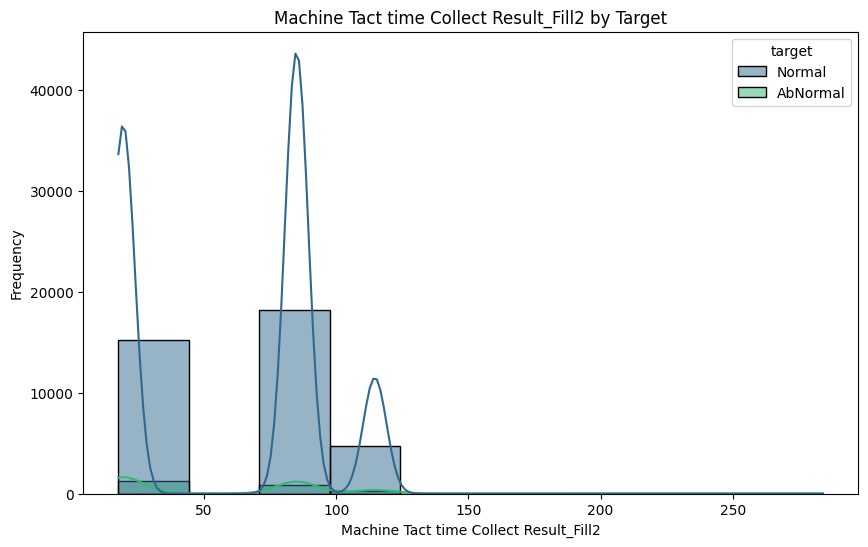

In [61]:
# 히스토그램 시각화
plt.figure(figsize=(10, 6))
sns.histplot(data=df_fill2_cleaned, x='Machine Tact time Collect Result_Fill2', hue='target', bins=10, kde=True, palette='viridis')
plt.title('Machine Tact time Collect Result_Fill2 by Target')
plt.xlabel('Machine Tact time Collect Result_Fill2')
plt.ylabel('Frequency')
plt.show()

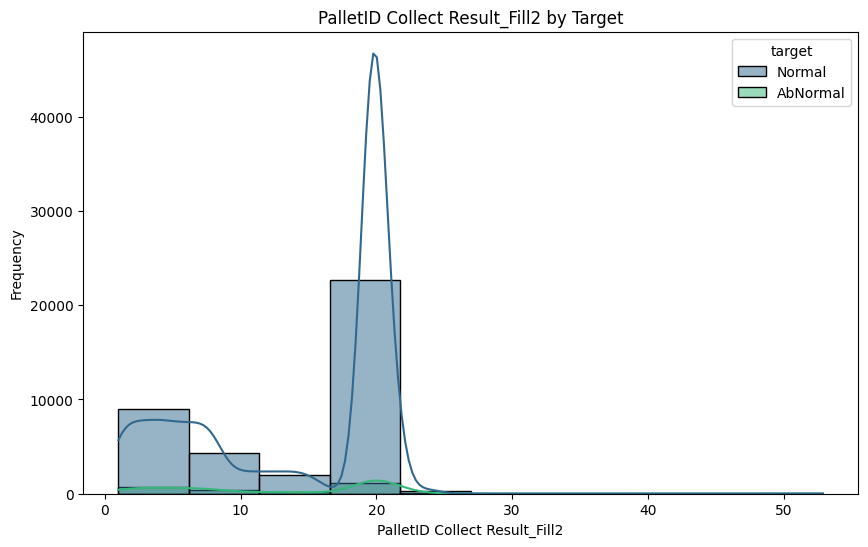

In [62]:
# 히스토그램 시각화
plt.figure(figsize=(10, 6))
sns.histplot(data=df_fill2_cleaned, x='PalletID Collect Result_Fill2', hue='target', bins=10, kde=True, palette='viridis')
plt.title('PalletID Collect Result_Fill2 by Target')
plt.xlabel('PalletID Collect Result_Fill2')
plt.ylabel('Frequency')
plt.show()

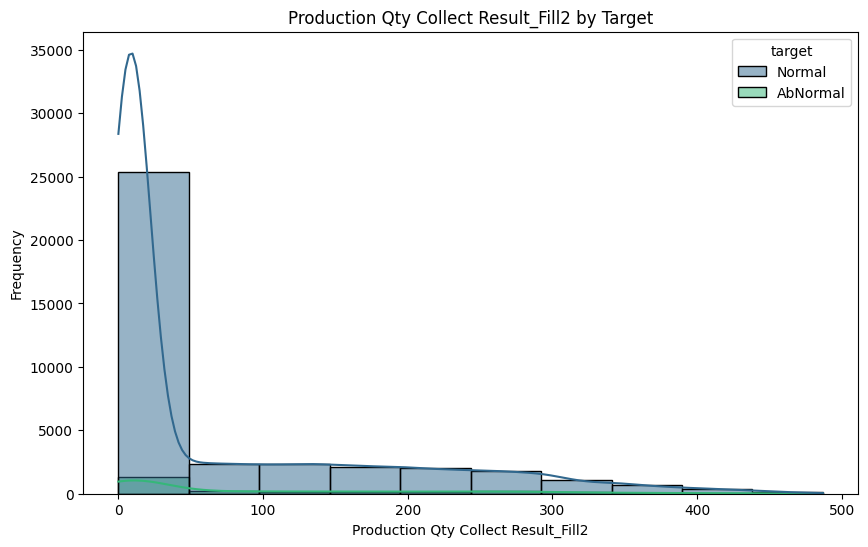

In [63]:
# 히스토그램 시각화
plt.figure(figsize=(10, 6))
sns.histplot(data=df_fill2_cleaned, x='Production Qty Collect Result_Fill2', hue='target', bins=10, kde=True, palette='viridis')
plt.title('Production Qty Collect Result_Fill2 by Target')
plt.xlabel('Production Qty Collect Result_Fill2')
plt.ylabel('Frequency')
plt.show()

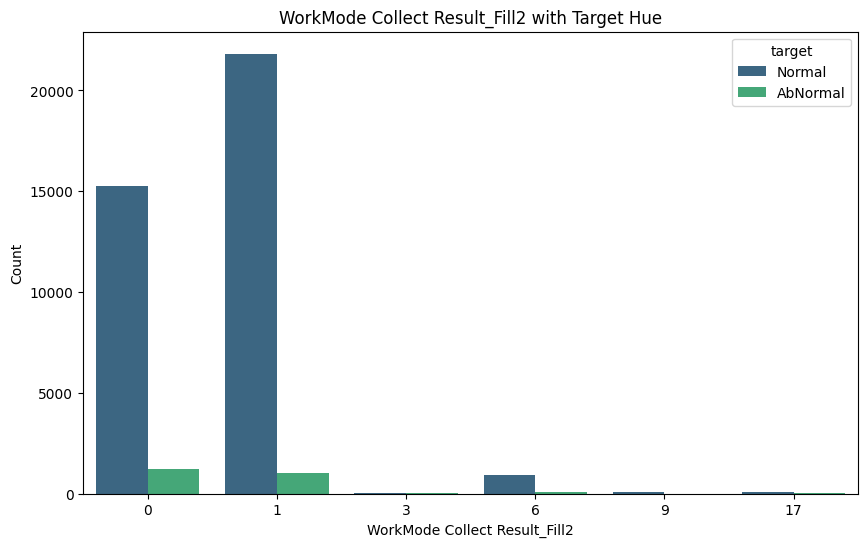

In [64]:
plt.figure(figsize=(10, 6))
sns.countplot(
    data=df_fill2_cleaned,
    x='WorkMode Collect Result_Fill2',
    hue='target',
    palette='viridis'
)
plt.title('WorkMode Collect Result_Fill2 with Target Hue')
plt.xlabel('WorkMode Collect Result_Fill2')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()